# 2026-06-07 Initial Check: [O/H]-SFR Relation for NGC4294 and NGC4298

Copied from `20260602_initial_check_OH_SFR_relation.ipynb`. This focused version only creates per-galaxy figures for `NGC4294` and `NGC4298`, while ensemble trends and pooled 95% contours continue to use all available science-ready galaxies.


## Setup copied and narrowed from the rMZR notebook

These cells keep the helper names expected by the copied plotting blocks, with product discovery patched to recognize both `gas_BIN` and `gas_bin` current products.


In [1]:
# [O/H]-SFR relation checks using mixed further-plus-extended products.
# The active science sample is: all currently science-ready `further` products,
# plus complete old `extended` products for current galaxies not science-ready yet.
# Downstream cells keep using the same helper names as the 20260525 notebook; the
# setup cell points each galaxy to either `further` or `extended_fake`.

from __future__ import annotations

import math
import re
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
RUN_LABEL = "v3tk_v7.6.8"
RUN_DIR = PROJECT_ROOT / RUN_LABEL
REFERENCE_ROOT = (PROJECT_ROOT.parent / "extended").resolve()
EXTENDED_ROOT = REFERENCE_ROOT
OUTDIR = PROJECT_ROOT / "quicklook_figures_OH_SFR_relation"

KEY_LINES = [
    "HB4861",
    "OIII5006",
    "HA6562",
    "NII6583",
    "SII6716",
    "SII6730",
    "SIII6312",
    "OII7318",
    "OII7319",
    "OII7329",
    "OII7330",
]

plt.style.use("default")
mpl.rcParams.update({
    "figure.dpi": 120,
    "font.size": 10,
    "axes.grid": False,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Current further run directory: {RUN_DIR}")
print(f"Fallback products source: {EXTENDED_ROOT}")
if EXTENDED_ROOT.exists() and str(EXTENDED_ROOT) not in sys.path:
    sys.path.append(str(EXTENDED_ROOT))

print("Active PRODUCT paths mix live `further` products with previous-paper `extended` fallbacks.")
print("Active save paths are intentionally commented out in this notebook.")

Project root: /Users/Igniz/Desktop/ICRAR/further
Current further run directory: /Users/Igniz/Desktop/ICRAR/further/v3tk_v7.6.8
Fallback products source: /Users/Igniz/Desktop/ICRAR/extended
Active PRODUCT paths mix live `further` products with previous-paper `extended` fallbacks.
Active save paths are intentionally commented out in this notebook.


In [2]:
def first_existing(*paths: Path | None) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


def fits_has_hdus(path: Path | None, names: list[str]) -> bool:
    if path is None or not Path(path).exists():
        return False
    try:
        with fits.open(path, memmap=True) as hdul:
            hdu_names = {h.name.upper() for h in hdul}
        return all(name.upper() in hdu_names for name in names)
    except Exception:
        return False


def align_map_to_shape(map_data, target_shape, *, label="map", fill_value=np.nan, max_delta=2):
    """Align a nearly matching 2D map to target_shape by copying the overlap."""
    target_shape = tuple(target_shape)
    arr = np.asarray(map_data, dtype=float)
    if arr.shape == target_shape:
        return arr
    if arr.ndim != len(target_shape):
        raise ValueError(f"{label}: cannot align ndim {arr.ndim} to target shape {target_shape}")

    deltas = tuple(abs(src - dst) for src, dst in zip(arr.shape, target_shape))
    if any(delta > max_delta for delta in deltas):
        raise ValueError(f"{label}: shape {arr.shape} differs too much from target {target_shape}")

    aligned = np.full(target_shape, fill_value, dtype=float)
    overlap = tuple(min(src, dst) for src, dst in zip(arr.shape, target_shape))
    slices = tuple(slice(0, n) for n in overlap)
    aligned[slices] = arr[slices]
    print(f"  {label}: aligned shape {arr.shape} -> {target_shape}; overlap={overlap}")
    return aligned


def intrinsic_sigma_from_maps(sigma_obs, sigma_corr, *, label="sigma"):
    """Return intrinsic sigma = sqrt(SIGMA^2 - SIGMA_CORR^2), masking nonphysical pixels."""
    if sigma_obs is None or sigma_corr is None:
        return None
    sigma_obs = np.asarray(sigma_obs, dtype=float)
    sigma_corr = align_map_to_shape(sigma_corr, sigma_obs.shape, label=f"{label} correction")
    sigma2_intrinsic = sigma_obs**2 - sigma_corr**2
    sigma_intrinsic = np.full(sigma_obs.shape, np.nan, dtype=float)
    ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
    sigma_intrinsic[ok] = np.sqrt(sigma2_intrinsic[ok])
    return sigma_intrinsic


def discover_further_products(run_dir: Path = RUN_DIR) -> pd.DataFrame:
    rows = []
    if not run_dir.exists():
        raise FileNotFoundError(f"Missing run directory: {run_dir}")

    for gal_dir in sorted(p for p in run_dir.iterdir() if p.is_dir()):
        gal = gal_dir.name
        spatial_raw = first_existing(
            gal_dir / f"{gal}_spatial_binning_maps.fits",
            gal_dir / f"{gal}_spatial_binning_maps.fits.gz",
        )
        spatial_further = first_existing(
            gal_dir / f"{gal}_spatial_binning_maps_further.fits",
            gal_dir / f"{gal}_spatial_binning_maps_further.fits.gz",
        )
        spatial_extended = first_existing(
            gal_dir / f"{gal}_spatial_binning_maps_extended.fits",
            gal_dir / f"{gal}_spatial_binning_maps_extended.fits.gz",
            gal_dir / f"{gal}_SPATIAL_BINNING_maps_extended.fits",
            gal_dir / f"{gal}_SPATIAL_BINNING_maps_extended.fits.gz",
        )
        gas_raw = first_existing(
            gal_dir / f"{gal}_gas_BIN_maps.fits",
            gal_dir / f"{gal}_gas_BIN_maps.fits.gz",
            gal_dir / f"{gal}_gas_bin_maps.fits",
            gal_dir / f"{gal}_gas_bin_maps.fits.gz",
        )
        gas_further = first_existing(
            gal_dir / f"{gal}_gas_BIN_maps_further.fits",
            gal_dir / f"{gal}_gas_BIN_maps_further.fits.gz",
            gal_dir / f"{gal}_gas_bin_maps_further.fits",
            gal_dir / f"{gal}_gas_bin_maps_further.fits.gz",
        )
        gas_extended = first_existing(
            gal_dir / f"{gal}_gas_BIN_maps_extended.fits",
            gal_dir / f"{gal}_gas_BIN_maps_extended.fits.gz",
            gal_dir / f"{gal}_gas_bin_maps_extended.fits",
            gal_dir / f"{gal}_gas_bin_maps_extended.fits.gz",
        )
        sfh = gal_dir / f"{gal}_sfh_maps.fits"
        sfh_weights = gal_dir / f"{gal}_sfh_weights.fits"
        kin = gal_dir / f"{gal}_kin_maps.fits"
        gas_spaxel = gal_dir / f"{gal}_gas_spaxel_maps.fits"
        mask = gal_dir / f"{gal}_mask.fits"

        spatial_preferred = first_existing(spatial_further, spatial_extended, spatial_raw)
        gas_preferred = first_existing(gas_further, gas_extended, gas_raw)

        rows.append({
            "galaxy": gal,
            "folder": gal_dir,
            "spatial_path": spatial_preferred,
            "gas_path": gas_preferred,
            "ew_path": first_existing(gal_dir / f"{gal}_proxy_EW_maps_further.fits", gal_dir / f"{gal}_proxy_EW_maps_further.fits.gz", gal_dir / f"{gal}_proxy_EW_maps.fits", gal_dir / f"{gal}_proxy_EW_maps.fits.gz", gal_dir / f"{gal}_pseudo_EW_maps.fits", gal_dir / f"{gal}_pseudo_EW_maps.fits.gz"),
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": sfh_weights if sfh_weights.exists() else None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": gas_spaxel if gas_spaxel.exists() else None,
            "mask_path": mask if mask.exists() else None,
            "sfr_log_path": first_existing(PROJECT_ROOT / "sfr_logs" / f"{gal}.log", gal_dir / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(PROJECT_ROOT / "mass_logs" / f"{gal}.log", gal_dir / "mass_logs" / f"{gal}.log"),
            "source": "further",
            "has_spatial": spatial_preferred is not None,
            "has_gas": gas_preferred is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": sfh_weights.exists(),
            "has_kin": kin.exists(),
            "has_gas_spaxel": gas_spaxel.exists(),
            "has_mask": mask.exists(),
            "has_spatial_further": spatial_further is not None,
            "has_gas_further": gas_further is not None,
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No galaxy folders found below {run_dir}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table


def discover_extended_products(root: Path = EXTENDED_ROOT) -> pd.DataFrame:
    rows = []
    if not root.exists():
        raise FileNotFoundError(f"Missing extended directory: {root}")

    galaxies = sorted({p.name.split("_SPATIAL_BINNING_maps_extended.fits")[0] for p in root.glob("*_SPATIAL_BINNING_maps_extended.fits")})
    for gal in galaxies:
        spatial = first_existing(root / f"{gal}_SPATIAL_BINNING_maps_extended.fits", root / f"{gal}_SPATIAL_BINNING_maps_extended.fits.gz", root / f"{gal}_spatial_binning_maps_extended.fits", root / f"{gal}_spatial_binning_maps_extended.fits.gz")
        gas = first_existing(root / f"{gal}_gas_BIN_maps_extended.fits", root / f"{gal}_gas_BIN_maps_extended.fits.gz", root / f"{gal}_gas_bin_maps_extended.fits", root / f"{gal}_gas_bin_maps_extended.fits.gz", root / f"{gal}_gas_BIN_maps.fits", root / f"{gal}_gas_bin_maps.fits")
        ew = first_existing(root / f"{gal}_proxy_EW_maps.fits", root / f"{gal}_proxy_EW_maps.fits.gz", root / f"{gal}_pseudo_EW_maps.fits", root / f"{gal}_pseudo_EW_maps.fits.gz")
        sfh = root / f"{gal}_SFH_maps.fits"
        kin = root / f"{gal}_KIN_maps_extended.fits"
        rows.append({
            "galaxy": gal,
            "folder": root,
            "spatial_path": spatial,
            "gas_path": gas,
            "ew_path": ew,
            "sfh_path": sfh if sfh.exists() else None,
            "sfh_weights_path": None,
            "kin_path": kin if kin.exists() else None,
            "gas_spaxel_path": None,
            "mask_path": None,
            "sfr_log_path": first_existing(root / "sfr_logs" / f"{gal}.log"),
            "mass_log_path": first_existing(root / "mass_logs" / f"{gal}.log"),
            "source": "extended_fake",
            "has_spatial": spatial is not None,
            "has_gas": gas is not None,
            "has_sfh": sfh.exists(),
            "has_sfh_weights": False,
            "has_kin": kin.exists(),
            "has_gas_spaxel": False,
            "has_mask": False,
            "has_spatial_further": False,
            "has_gas_further": False,
        })

    table = pd.DataFrame(rows).set_index("galaxy", drop=False)
    if table.empty:
        raise RuntimeError(f"No extended spatial products found below {root}")

    table["has_mass_map"] = [fits_has_hdus(path, ["LOGMASS_SURFACE_DENSITY"]) for path in table["spatial_path"]]
    table["has_sfr_map"] = [fits_has_hdus(path, ["LOGSFR_SURFACE_DENSITY_HII", "LOGSFR_SURFACE_DENSITY_SF"]) for path in table["gas_path"]]
    table["has_o3n2_m13"] = [fits_has_hdus(path, ["O_H_O3N2_M13_HII", "O_H_O3N2_M13_SF"]) for path in table["gas_path"]]
    table["has_proxy_ew"] = table["ew_path"].notna()
    table["ready_physics_maps"] = table["has_spatial"] & table["has_gas"] & table["has_mass_map"] & table["has_sfr_map"] & table["has_o3n2_m13"]
    table["ready_raw_gas_qc"] = table["has_spatial"] & table["has_gas"]
    table["ready_sfh_qc"] = table["has_spatial"] & table["has_sfh"]
    return table


CURRENT_PRODUCTS = discover_further_products()
EXTENDED_PRODUCTS = discover_extended_products()

CURRENT_READY_PHYSICS_GALAXIES = CURRENT_PRODUCTS.index[CURRENT_PRODUCTS["ready_physics_maps"]].tolist()
CURRENT_NOT_PHYSICS_READY = CURRENT_PRODUCTS.index[~CURRENT_PRODUCTS["ready_physics_maps"]].tolist()

FAKE_GALAXIES = [
    gal for gal in CURRENT_NOT_PHYSICS_READY
    if gal in EXTENDED_PRODUCTS.index
    and bool(EXTENDED_PRODUCTS.loc[gal, "ready_physics_maps"])
    and bool(EXTENDED_PRODUCTS.loc[gal, "has_proxy_ew"])
]
UNREUSABLE_MISSING_GALAXIES = [
    gal for gal in CURRENT_NOT_PHYSICS_READY
    if gal not in FAKE_GALAXIES
]

PRODUCTS = CURRENT_PRODUCTS.copy()
PRODUCTS["source"] = "further_ready"
PRODUCTS.loc[~PRODUCTS["ready_physics_maps"], "source"] = "further_not_science_ready"

for gal in FAKE_GALAXIES:
    for col in EXTENDED_PRODUCTS.columns:
        PRODUCTS.loc[gal, col] = EXTENDED_PRODUCTS.loc[gal, col]

PRODUCTS["fake_reason"] = ""
PRODUCTS.loc[FAKE_GALAXIES, "fake_reason"] = "not science-ready in current further; using complete previous-paper extended products"
PRODUCTS.loc[UNREUSABLE_MISSING_GALAXIES, "fake_reason"] = "kept for inventory/QC only; no complete extended fallback"

EXTENDED_ONLY_GALAXIES = [
    gal for gal in EXTENDED_PRODUCTS.index
    if gal not in PRODUCTS.index
    and bool(EXTENDED_PRODUCTS.loc[gal, "ready_physics_maps"])
    and bool(EXTENDED_PRODUCTS.loc[gal, "has_proxy_ew"])
]
for gal in EXTENDED_ONLY_GALAXIES:
    for col in EXTENDED_PRODUCTS.columns:
        PRODUCTS.loc[gal, col] = EXTENDED_PRODUCTS.loc[gal, col]
    PRODUCTS.loc[gal, "source"] = "extended_only"
    PRODUCTS.loc[gal, "fake_reason"] = "not present in current further; using complete previous-paper extended products"

CURRENT_USED_GALAXIES = PRODUCTS.index[(PRODUCTS["ready_physics_maps"]) & (PRODUCTS["source"] != "extended_fake")].tolist()
COMBINED_READY_PHYSICS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()


def further_spatial_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "spatial_path"]
    if path is None:
        raise FileNotFoundError(f"No spatial product registered for {galaxy}")
    return Path(path)


def further_gas_path(galaxy: str) -> Path:
    path = PRODUCTS.loc[galaxy, "gas_path"]
    if path is None:
        raise FileNotFoundError(f"No gas product registered for {galaxy}")
    return Path(path)


def further_ew_path(galaxy: str, suffix: str | None = None) -> Path:
    if galaxy in PRODUCTS.index and PRODUCTS.loc[galaxy, "ew_path"] is not None:
        return Path(PRODUCTS.loc[galaxy, "ew_path"])

    suffixes = []
    if suffix:
        suffixes.append(suffix)
    suffixes.extend(["_proxy_EW_maps.fits", "_proxy_EW_maps_further.fits", "_pseudo_EW_maps.fits"])
    candidates = []
    for suffix_item in dict.fromkeys(suffixes):
        candidates.append(EXTENDED_ROOT / f"{galaxy}{suffix_item}")
        candidates.append(PROJECT_ROOT / f"{galaxy}{suffix_item}")
    found = first_existing(*candidates)
    if found is None:
        checked = "\n".join(f"  - {path}" for path in candidates)
        raise FileNotFoundError(f"No EW product found for {galaxy}. Checked:\n{checked}")
    return found


def sfr_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "sfr_log_path"]
        return None if path is None else Path(path)
    return first_existing(EXTENDED_ROOT / "sfr_logs" / f"{galaxy}.log", PROJECT_ROOT / "sfr_logs" / f"{galaxy}.log")


def mass_log_path(galaxy: str) -> Path | None:
    if galaxy in PRODUCTS.index:
        path = PRODUCTS.loc[galaxy, "mass_log_path"]
        return None if path is None else Path(path)
    return first_existing(EXTENDED_ROOT / "mass_logs" / f"{galaxy}.log", PROJECT_ROOT / "mass_logs" / f"{galaxy}.log")


def physics_ready_galaxies(require_ew: bool = True) -> list[str]:
    galaxies = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()
    if require_ew:
        galaxies = [gal for gal in galaxies if PRODUCTS.loc[gal, "has_proxy_ew"]]
    return galaxies


def old_paper_cells_ready(require_ew: bool = True) -> bool:
    return len(physics_ready_galaxies(require_ew=require_ew)) > 0


RAW_GAS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_raw_gas_qc"]].tolist()
SFH_GALAXIES = PRODUCTS.index[PRODUCTS["ready_sfh_qc"]].tolist()
READY_PHYSICS_GALAXIES = PRODUCTS.index[PRODUCTS["ready_physics_maps"]].tolist()

summary_columns = [
    "source",
    "has_spatial",
    "has_gas",
    "has_sfh",
    "has_kin",
    "has_mass_map",
    "has_sfr_map",
    "has_o3n2_m13",
    "has_proxy_ew",
    "ready_raw_gas_qc",
    "ready_sfh_qc",
    "ready_physics_maps",
    "sfr_log_path",
    "mass_log_path",
]

print(f"Discovered {len(CURRENT_PRODUCTS)} current galaxy folders in {RUN_LABEL}.")
print(f"Current science-ready physics-map galaxies: {len(CURRENT_READY_PHYSICS_GALAXIES)}")
print(f"Current not-science-ready galaxies: {len(CURRENT_NOT_PHYSICS_READY)}")
print(", ".join(CURRENT_NOT_PHYSICS_READY))
print(f"Further science-ready galaxies used directly: {len(CURRENT_USED_GALAXIES)}")
print(", ".join(CURRENT_USED_GALAXIES) if CURRENT_USED_GALAXIES else "none")
print(f"Fake/reused extended fallback galaxies: {len(FAKE_GALAXIES)}")
print(", ".join(FAKE_GALAXIES) if FAKE_GALAXIES else "none")
print(f"Extended-only fallback galaxies added: {len(EXTENDED_ONLY_GALAXIES)}")
print(", ".join(EXTENDED_ONLY_GALAXIES) if EXTENDED_ONLY_GALAXIES else "none")
print(f"Combined science-ready galaxies available to old-paper cells: {len(COMBINED_READY_PHYSICS_GALAXIES)}")
print(", ".join(COMBINED_READY_PHYSICS_GALAXIES) if COMBINED_READY_PHYSICS_GALAXIES else "none")
print("Current not-science-ready galaxies with no complete extended fallback:", ", ".join(UNREUSABLE_MISSING_GALAXIES) if UNREUSABLE_MISSING_GALAXIES else "none")
display(PRODUCTS[summary_columns])

Discovered 29 current galaxy folders in v3tk_v7.6.8.
Current science-ready physics-map galaxies: 29
Current not-science-ready galaxies: 0

Further science-ready galaxies used directly: 29
IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Fake/reused extended fallback galaxies: 0
none
Extended-only fallback galaxies added: 0
none
Combined science-ready galaxies available to old-paper cells: 29
IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Current not-science-ready galaxies with no complete extended fallback: none


,source,has_spatial,has_gas,has_sfh,has_kin,has_mass_map,has_sfr_map,has_o3n2_m13,has_proxy_ew,ready_raw_gas_qc,ready_sfh_qc,ready_physics_maps,sfr_log_path,mass_log_path
galaxy,,,,,,,,,,,,,,
IC3392,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/IC...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/I...
NGC4064,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4189,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4192,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4254,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4293,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4294,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4298,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...
NGC4302,further_ready,True,True,True,True,True,True,True,True,True,True,True,/Users/Igniz/Desktop/ICRAR/further/sfr_logs/NG...,/Users/Igniz/Desktop/ICRAR/further/mass_logs/N...


In [3]:
# Focus sample for this copied notebook.
# Per-galaxy figures are restricted to these IDs; all-galaxy trends/contours use the full ready sample.
FOCUS_GALAXIES = ['NGC4294', 'NGC4298']


In [4]:
import matplotlib as mpl

# Increase tick label font sizes and tick length/width globally for all plots
mpl.rcParams.update({
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 4,
    "ytick.minor.size": 4,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})


## Fixed galaxy colors

The mapping below is copied from `20260530_MAUVE_galaxy_colors.md` and the palette-test notebook convention, not loaded from `MAUVE_galaxy_colors.dat`.

In [5]:
# Fixed MAUVE galaxy-color convention copied from:
# - 20260530_MAUVE_galaxy_colors.md
# - 20260529_test_galaxy_color_palette.ipynb
#
# Per request, this notebook does not load MAUVE_galaxy_colors.dat.
from matplotlib.colors import ListedColormap

FIXED_GALAXY_PALETTE_NAME = "MAUVE_GALAXY_GLASBEY_PACKAGE_40"
FIXED_GALAXY_ORDER = [
    'IC3392',
    'NGC4064',
    'NGC4189',
    'NGC4192',
    'NGC4216',
    'NGC4222',
    'NGC4254',
    'NGC4293',
    'NGC4294',
    'NGC4298',
    'NGC4302',
    'NGC4321',
    'NGC4330',
    'NGC4351',
    'NGC4380',
    'NGC4383',
    'NGC4388',
    'NGC4394',
    'NGC4396',
    'NGC4402',
    'NGC4405',
    'NGC4419',
    'NGC4424',
    'NGC4450',
    'NGC4457',
    'NGC4501',
    'NGC4522',
    'NGC4535',
    'NGC4548',
    'NGC4567',
    'NGC4568',
    'NGC4569',
    'NGC4579',
    'NGC4580',
    'NGC4606',
    'NGC4607',
    'NGC4654',
    'NGC4689',
    'NGC4694',
    'NGC4698',
]
TOTAL_ASSEMBLED_COLOR = "black"
FIXED_GALAXY_COLORS = {
    'IC3392': '#d21820',
    'NGC4064': '#6175ff',
    'NGC4189': '#008a00',
    'NGC4192': '#ff79fb',
    'NGC4216': '#aafb00',
    'NGC4222': '#713971',
    'NGC4254': '#00dbc2',
    'NGC4293': '#ff9e04',
    'NGC4294': '#35595d',
    'NGC4298': '#6d4904',
    'NGC4302': '#aa657d',
    'NGC4321': '#a2aaff',
    'NGC4330': '#92aa65',
    'NGC4351': '#a241ff',
    'NGC4380': '#00ff96',
    'NGC4383': '#c60079',
    'NGC4388': '#ffaeca',
    'NGC4394': '#697996',
    'NGC4396': '#a67d00',
    'NGC4402': '#697955',
    'NGC4405': '#ffe392',
    'NGC4419': '#ff6182',
    'NGC4424': '#863135',
    'NGC4450': '#a6e7ff',
    'NGC4457': '#1cc600',
    'NGC4501': '#35518e',
    'NGC4522': '#ff5d00',
    'NGC4535': '#a682be',
    'NGC4548': '#04a6ef',
    'NGC4567': '#04aa75',
    'NGC4568': '#aa592d',
    'NGC4569': '#cac200',
    'NGC4579': '#08612d',
    'NGC4580': '#dfd2fb',
    'NGC4606': '#ca9679',
    'NGC4607': '#d200df',
    'NGC4654': '#8eaaba',
    'NGC4689': '#bae3c2',
    'NGC4694': '#6500ff',
    'NGC4698': '#008a8a',
    'NGC4567_8': '#04aa75',
}
FIXED_GALAXY_CMAP = ListedColormap(
    [FIXED_GALAXY_COLORS[g] for g in FIXED_GALAXY_ORDER],
    name=FIXED_GALAXY_PALETTE_NAME,
)

def galaxy_color(galaxy: str) -> str:
    if galaxy in FIXED_GALAXY_COLORS:
        return FIXED_GALAXY_COLORS[galaxy]
    print(f"Warning: {galaxy} is not in the fixed MAUVE galaxy palette; using gray fallback.")
    return "#777777"

def ordered_galaxies_by_fixed_palette(galaxies):
    requested = list(galaxies)
    remaining = set(requested)
    ordered = []
    for galaxy in FIXED_GALAXY_ORDER:
        if galaxy in remaining:
            ordered.append(galaxy)
            remaining.remove(galaxy)
        if galaxy == "NGC4567" and "NGC4567_8" in remaining:
            ordered.append("NGC4567_8")
            remaining.remove("NGC4567_8")
    ordered.extend(sorted(remaining))
    return ordered

def galaxy_legend_handles(galaxies, marker="o", markersize=6):
    from matplotlib.lines import Line2D
    return [
        Line2D(
            [0], [0], marker=marker, color="none", linestyle="None",
            markerfacecolor=galaxy_color(galaxy), markeredgecolor="none",
            markersize=markersize, label=galaxy,
        )
        for galaxy in galaxies
    ]

print(f"Loaded fixed {FIXED_GALAXY_PALETTE_NAME} mapping for {len(FIXED_GALAXY_ORDER)} component galaxies.")
print(f"NGC4567_8 alias color: {FIXED_GALAXY_COLORS['NGC4567_8']}; total/pooled color: {TOTAL_ASSEMBLED_COLOR}")


Loaded fixed MAUVE_GALAXY_GLASBEY_PACKAGE_40 mapping for 40 component galaxies.
NGC4567_8 alias color: #04aa75; total/pooled color: black


## Source notebook cell 22 reproduction

This is the one-based cell 22 block from `20260602_initial_check_rMZR_fake.ipynb`, copied with outputs cleared.


Using fixed MAUVE_GALAXY_GLASBEY_PACKAGE_40 colors for source cell 17 recreation.
Offset relations and Spearman rho vs Σ_* (excluding: {'NGC4383'})
All galaxies (for color assignment): IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Galaxies used in this analysis: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698

Processing IC3392 ...
  Σ* range (95%): 7.997 to 8.788
  Global Δlog(Σ_SFR) axis limits: ±0.824
  Global Δ[O/H] axis limits: ±0.159
  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):
    Bin 01 (8.06): n=941, r=N/A (no trend or too few in 3σ)
    Bin 02 (8.2

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_88327/1793348568.py:473: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


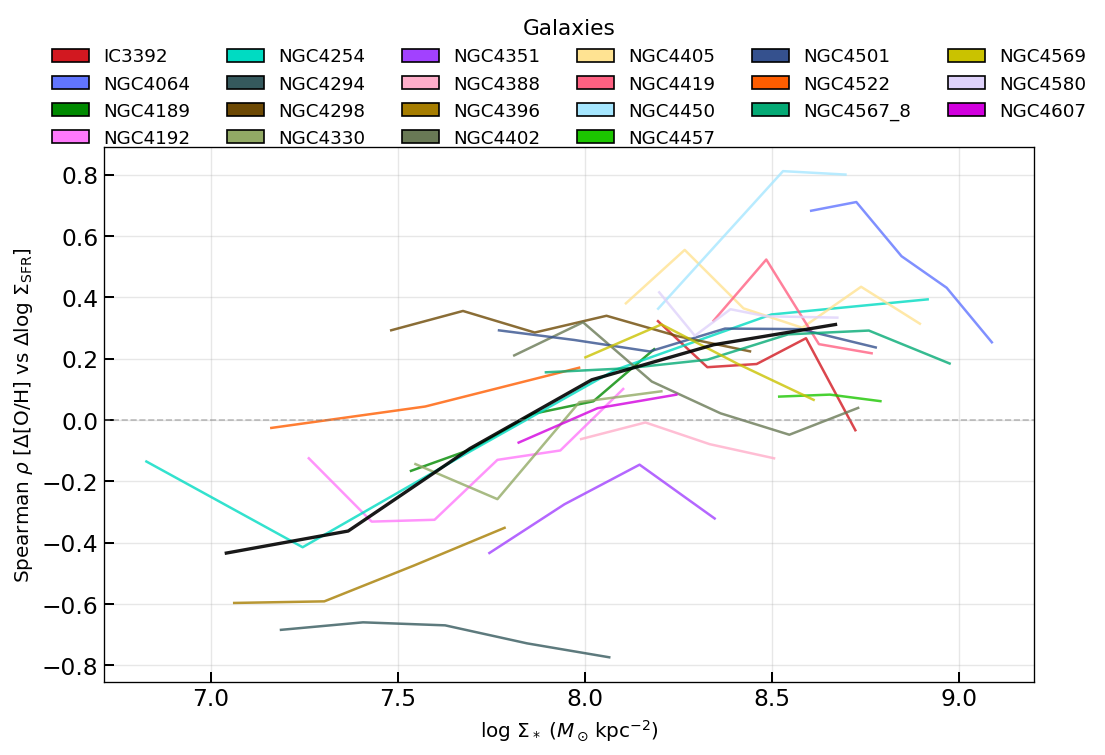

In [6]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Source cell 17 recreated with fixed galaxy colors: Δ[O/H] vs Δlog Σ_SFR in Σ_* bins
    # For all galaxies (excluding NGC4383) and Spearman rho vs Σ_* summary
    # Spearman rho uses only points inside 95% contour and only if trend exists
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.colors import BoundaryNorm
    import matplotlib.gridspec as gridspec
    from scipy.stats import spearmanr
    from matplotlib.lines import Line2D
    from matplotlib.patches import Patch

    # ------------------------------------------------------------------
    # Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = h_spatial['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(gas_path) as h_gas:
            sigSFR = h_gas['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h_gas['HA6562_SIGMA'].data
            ha_sigma_corr = h_gas['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = h_gas['O_H_O3N2_M14_HII'].data
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = h_gas['O_H_O3N2_M13_HII'].data
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, indicator_name

    # ------------------------------------------------------------------
    # Helper: calculate binned statistics with unique-count requirement
    # ------------------------------------------------------------------
    def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_unique=20):
        """Calculate median and std in x-bins, requiring >= min_unique unique y values."""
        x_data = np.asarray(x_data)
        y_data = np.asarray(y_data)

        finite = np.isfinite(x_data) & np.isfinite(y_data)
        if np.sum(finite) == 0:
            return np.array([]), np.array([]), np.array([]), np.array([])

        x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
            return np.array([]), np.array([]), np.array([]), np.array([])

        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            return np.array([]), np.array([]), np.array([]), np.array([])

        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        medians = []
        stds = []
        counts = []
        valid_centers = []

        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
            if np.sum(in_bin) == 0:
                continue

            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_unique:
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])

        return (np.array(valid_centers), np.array(medians),
                np.array(stds), np.array(counts))

    # ------------------------------------------------------------------
    # Galaxy list and color map (reserve color for excluded galaxy)
    # ------------------------------------------------------------------
    all_bin_centers = []  # Σ_* bin centers for which rho is valid (per-galaxy)
    all_rho_values = []     # Spearman rho (per-galaxy)
    all_galaxy_indices = []

    # Also store all spaxels across galaxies to compute a global trend
    global_sigM_list = []
    global_sfr_off_list = []
    global_oh_off_list = []
    global_gal_index_list = []

    # Build full galaxy list from available FITS files (including excluded)
    galaxies_all = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}

    # Build galaxy -> fixed MAUVE color mapping over ALL galaxies (so excluded keeps its color)
    galaxy_color_dict = {gal: galaxy_color(gal) for gal in galaxies_all}
    print(f"Using fixed {FIXED_GALAXY_PALETTE_NAME} colors for source cell 17 recreation.")

    # Now define the working sample that EXCLUDES NGC4383 for analysis/plotting
    galaxies = [g for g in galaxies_all if g not in excluded_galaxies]

    print("=" * 80)
    print(f"Offset relations and Spearman rho vs Σ_* (excluding: {excluded_galaxies})")
    print("All galaxies (for color assignment):", ", ".join(galaxies_all))
    print("Galaxies used in this analysis:", ", ".join(galaxies))
    print("=" * 80)

    # ------------------------------------------------------------------
    # Loop over galaxies and compute Spearman rho per Σ_* bin (per-galaxy)
    # and collect global spaxels for combined trend
    # ------------------------------------------------------------------
    for gal_index, gal in enumerate(galaxies):
        print(f"\nProcessing {gal} ...")
        try:
            sigM, sigSFR, oh_o3n2_map, indicator_name = load_maps(gal)
        except Exception as e:
            print(f"  Skipping {gal}: {e}")
            continue

        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        if np.sum(valid_all) == 0:
            print("  No valid pixels.")
            continue

        global_gal_index_list.append(np.full(np.sum(valid_all), gal_index, dtype=int))

        # 1. Define 6 Σ_* bins for this galaxy (spanning 95% population)
        n_bins = 6
        sigmaM_min = np.nanpercentile(sigM[valid_all], 2.5)
        sigmaM_max = np.nanpercentile(sigM[valid_all], 97.5)
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
        sigmaM_bin_centers = 0.5 * (sigmaM_bin_edges[:-1] + sigmaM_bin_edges[1:])

        # 2. Global symmetric limits for this galaxy (for reference / consistency)
        global_max_abs_sfr = 0
        global_max_abs_oh = 0
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

            if np.sum(bin_mask) > 0:
                sfr_bin = sigSFR[bin_mask]
                oh_bin = oh_o3n2_map[bin_mask]

                sfr_offset = sfr_bin - np.mean(sfr_bin)
                oh_offset = oh_bin - np.mean(oh_bin)

                if np.any(np.isfinite(sfr_offset)):
                    global_max_abs_sfr = max(global_max_abs_sfr, np.nanmax(np.abs(sfr_offset)))
                if np.any(np.isfinite(oh_offset)):
                    global_max_abs_oh = max(global_max_abs_oh, np.nanmax(np.abs(oh_offset)))

        print(f"  Σ* range (95%): {sigmaM_min:.3f} to {sigmaM_max:.3f}")
        print(f"  Global Δlog(Σ_SFR) axis limits: ±{global_max_abs_sfr:.3f}")
        print(f"  Global Δ[O/H] axis limits: ±{global_max_abs_oh:.3f}")

        # 3. Compute Spearman rho in each Σ_* bin using 3-sigma clipping on unique data (per galaxy)
        print("  Spearman rho in each Σ_* bin (3σ clip + trend, per galaxy):")
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all

            n_pixels = np.sum(bin_mask)

            if n_pixels <= 0:
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n=0, r=N/A")
                continue

            # Values in this Σ_* bin
            sfr_bin = sigSFR[bin_mask]
            oh_bin = oh_o3n2_map[bin_mask]

            # Offsets within this bin
            sfr_bin_mean = np.mean(sfr_bin)
            oh_bin_mean = np.mean(oh_bin)

            sfr_offset = sfr_bin - sfr_bin_mean
            oh_offset = oh_bin - oh_bin_mean

            valid_corr = np.isfinite(sfr_offset) & np.isfinite(oh_offset)
            if np.sum(valid_corr) > 0:
                global_sigM_list.append(sigM[bin_mask][valid_corr])
                global_sfr_off_list.append(sfr_offset[valid_corr])
                global_oh_off_list.append(oh_offset[valid_corr])


            if np.sum(valid_corr) <= 2:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (insufficient valid points)")
                continue

            # ------------------------------------------------------------------
            # Calculate 3-sigma clipping mask on unique valid data
            # ------------------------------------------------------------------
            sigma_clip_mask = np.zeros_like(valid_corr, dtype=bool)
            if np.sum(valid_corr) > 0:
                # Get unique valid data using np.unique
                sfr_data = sfr_offset[valid_corr]
                oh_data = oh_offset[valid_corr]
            
                sfr_unique = np.unique(sfr_data)
                oh_unique = np.unique(oh_data)
            
                # Calculate mean and std on unique values
                x_mean = np.mean(sfr_unique)
                x_std = np.std(sfr_unique)
                y_mean = np.mean(oh_unique)
                y_std = np.std(oh_unique)
            
                # 3-sigma bounds
                x_lower = x_mean - 3 * x_std
                x_upper = x_mean + 3 * x_std
                y_lower = y_mean - 3 * y_std
                y_upper = y_mean + 3 * y_std
            
                # Apply 3-sigma clipping to all data points
                within_3sigma = (sfr_data >= x_lower) & (sfr_data <= x_upper) & \
                                (oh_data >= y_lower) & (oh_data <= y_upper)
                sigma_clip_mask[valid_corr] = within_3sigma

            # ------------------------------------------------------------------
            # Median trend using only points within 3-sigma
            # ------------------------------------------------------------------
            x_trend = sfr_offset[sigma_clip_mask]
            y_trend = oh_offset[sigma_clip_mask]

            centers, medians, stds, counts = calculate_binned_stats(x_trend, y_trend,
                                                                    bin_width=0.2,
                                                                    min_unique=20)

            # Require at least 2 median-trend points for a valid trend
            has_trend = centers.size >= 3

            # ------------------------------------------------------------------
            # Spearman rho: only for points within 3-sigma and only if trend exists
            # ------------------------------------------------------------------
            if has_trend and np.sum(sigma_clip_mask & valid_corr) > 2:
                try:
                    spearman_rho, spearman_p = spearmanr(sfr_offset[sigma_clip_mask & valid_corr],
                                                    oh_offset[sigma_clip_mask & valid_corr])
                    print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r={spearman_rho:.3f} (p={spearman_p:.3g})")
                except Exception:
                    spearman_rho = np.nan
                    print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (error)")
            else:
                spearman_rho = np.nan
                print(f"    Bin {i+1:02d} ({sigmaM_bin_centers[i]:.2f}): n={n_pixels}, r=N/A (no trend or too few in 3σ)")

            # Store only valid rho values
            if np.isfinite(spearman_rho):
                all_bin_centers.append(sigmaM_bin_centers[i])
                all_rho_values.append(spearman_rho)
                all_galaxy_indices.append(gal_index)

    # ------------------------------------------------------------------
    # Prepare global arrays for combined Spearman vs Σ_* (all galaxies)
    # ------------------------------------------------------------------
    if global_sigM_list:
        global_sigM = np.concatenate(global_sigM_list)
        global_sfr_off = np.concatenate(global_sfr_off_list)
        global_oh_off = np.concatenate(global_oh_off_list)
    else:
        global_sigM = np.array([])
        global_sfr_off = np.array([])
        global_oh_off = np.array([])

    # ------------------------------------------------------------------
    # Convert collected per-galaxy Spearman rho data to arrays
    # ------------------------------------------------------------------
    all_bin_centers = np.array(all_bin_centers)
    all_rho_values = np.array(all_rho_values)
    all_galaxy_indices = np.array(all_galaxy_indices)

    print("\n" + "=" * 80)
    print("Summary: number of Σ_* bins with valid Spearman rho (per galaxy):", len(all_rho_values))
    print("=" * 80)

    # ------------------------------------------------------------------
    # Compute combined Spearman rho vs Σ_* over all galaxies (same method)
    # ------------------------------------------------------------------
    global_bin_centers = []
    global_rho_values = []

    if global_sigM.size > 0:
        # Define 6 Σ_* bins for the combined sample (spanning 95% population)
        n_bins_global = 6
        sigmaM_min_g = np.nanpercentile(global_sigM, 2.5)
        sigmaM_max_g = np.nanpercentile(global_sigM, 97.5)
        sigmaM_edges_g = np.linspace(sigmaM_min_g, sigmaM_max_g, n_bins_global + 1)
        sigmaM_centers_g = 0.5 * (sigmaM_edges_g[:-1] + sigmaM_edges_g[1:])

        print("\nComputing combined Spearman rho in Σ_* bins (all galaxies together)...")
        for i in range(n_bins_global):
            if i == 0:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])
            elif i == n_bins_global - 1:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM <= sigmaM_edges_g[i+1])
            else:
                bin_mask_g = (global_sigM >= sigmaM_edges_g[i]) & (global_sigM < sigmaM_edges_g[i+1])

            n_pix_g = np.sum(bin_mask_g)
            if n_pix_g <= 0:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n=0, r=N/A")
                continue


            sfr_off_g = global_sfr_off[bin_mask_g]
            oh_off_g = global_oh_off[bin_mask_g]

            valid_corr_g = np.isfinite(sfr_off_g) & np.isfinite(oh_off_g)
            if np.sum(valid_corr_g) <= 2:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (insufficient valid points)")
                continue

            # ------------------------------------------------------------------
            # Calculate 3-sigma clipping mask on unique valid data (global)
            # ------------------------------------------------------------------
            sigma_clip_mask_global = np.zeros_like(valid_corr_g, dtype=bool)
            if np.sum(valid_corr_g) > 0:
                sfr_data_g = sfr_off_g[valid_corr_g]
                oh_data_g = oh_off_g[valid_corr_g]
            
                sfr_unique_g = np.unique(sfr_data_g)
                oh_unique_g = np.unique(oh_data_g)
            
                x_mean_g = np.mean(sfr_unique_g)
                x_std_g = np.std(sfr_unique_g)
                y_mean_g = np.mean(oh_unique_g)
                y_std_g = np.std(oh_unique_g)
            
                x_lower_g = x_mean_g - 3 * x_std_g
                x_upper_g = x_mean_g + 3 * x_std_g
                y_lower_g = y_mean_g - 3 * y_std_g
                y_upper_g = y_mean_g + 3 * y_std_g
            
                within_3sigma_g = (sfr_data_g >= x_lower_g) & (sfr_data_g <= x_upper_g) & \
                                  (oh_data_g >= y_lower_g) & (oh_data_g <= y_upper_g)
                sigma_clip_mask_global[valid_corr_g] = within_3sigma_g

            x_trend_g = sfr_off_g[sigma_clip_mask_global]
            y_trend_g = oh_off_g[sigma_clip_mask_global]

            centers_g, medians_g, stds_g, counts_g = calculate_binned_stats(x_trend_g, y_trend_g,
                                                                            bin_width=0.2,
                                                                            min_unique=20)

            has_trend_g = centers_g.size >= 3

            if has_trend_g and np.sum(sigma_clip_mask_global & valid_corr_g) > 2:
                try:
                    rho_g, p_g = spearmanr(sfr_off_g[sigma_clip_mask_global & valid_corr_g],
                                         oh_off_g[sigma_clip_mask_global & valid_corr_g])
                    global_bin_centers.append(sigmaM_centers_g[i])
                    global_rho_values.append(rho_g)
                    print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r={rho_g:.3f} (p={p_g:.3g})")
                except Exception:
                    print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (error)")
            else:
                print(f"  Global bin {i+1:02d} ({sigmaM_centers_g[i]:.2f}): n={n_pix_g}, r=N/A (no trend or too few in 3σ)")

    global_bin_centers = np.array(global_bin_centers)
    global_rho_values = np.array(global_rho_values)

    # ------------------------------------------------------------------
    # Plot Spearman rho vs Σ_* for all galaxies, with galaxy color legend
    # and an additional combined (all galaxies) trend in black
    # ------------------------------------------------------------------
    if len(all_rho_values) > 0:
    
        galaxy_indices_unique = np.unique(all_galaxy_indices)
    
        # Create figure with main axis and a thin top axis for legend
        fig = plt.figure(figsize=(10, 7))
        gs = gridspec.GridSpec(2, 1, height_ratios=[0.18, 1.0], hspace=0.05)
        legend_ax = fig.add_subplot(gs[0, 0])
        ax = fig.add_subplot(gs[1, 0])
        legend_ax.axis('off')
    
        plotted_galaxies = [] # Keep track of which galaxies are actually plotted
    
        # Plot Spearman rho vs Σ_* for each galaxy
        for idx in galaxy_indices_unique:
            mask = all_galaxy_indices == idx
            gal_name = galaxies[idx]
            color = galaxy_color_dict[gal_name]
        
            # Sort by Σ_* so lines are not scrambled
            x_vals = all_bin_centers[mask]
            y_vals = all_rho_values[mask]
        
            # Filter: skip if only 1 data point
            if len(x_vals) <= 2:
                continue
            
            plotted_galaxies.append(gal_name)
        
            order = np.argsort(x_vals)
            x_sorted = x_vals[order]
            y_sorted = y_vals[order]
        
            ax.plot(x_sorted, y_sorted, color=color, linewidth=1.5, alpha=0.8)
            # No per-galaxy scatter points: line-only trend summary for this 1D diagnostic.
    
        # Add combined trend (all galaxies together) in black (no legend entry)
        if global_rho_values.size > 2:
            order_g = np.argsort(global_bin_centers)
            ax.plot(global_bin_centers[order_g], global_rho_values[order_g],
                    color='black', linewidth=2.0, alpha=0.9, linestyle='-')
            # No global scatter points: black line is the pooled trend summary.
    
        # Axis formatting
        ax.axhline(0.0, color='gray', linestyle='--', linewidth=1.0, alpha=0.5)
        ax.set_xlabel(r'$\log\,\Sigma_* \; (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax.set_ylabel(r'Spearman $\rho$ [Δ[O/H] vs Δ$\log\,\Sigma_{\mathrm{SFR}}$]', fontsize=12)
        # ax.set_title(r'Spearman $\rho$ vs $\log\,\Sigma_*$ (all galaxies, excluding NGC4383)', fontsize=14)
        ax.grid(True, alpha=0.3)
    
        # ------------------------------------------------------------------
        # Galaxy legend at the top using dummy patches (excluding NGC4383)
        # ------------------------------------------------------------------
        legend_elements = [
            Patch(facecolor=galaxy_color_dict[gal], edgecolor='black', label=gal)
            for gal in plotted_galaxies
        ]
        if len(plotted_galaxies) > 0:
            legend_ax.legend(handles=legend_elements, loc='center', ncol=min(len(plotted_galaxies), 6),
                            frameon=False, fontsize=11, title='Galaxies', title_fontsize=13)
    
        plt.tight_layout()
        # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383_EW.png',
                    # dpi=600, bbox_inches='tight')
        # plt.savefig('Plot_Paper_1/MAUVE_MUSE_SpearmanRho_vs_SigmaM_AllGalaxies_ExclNGC4383_EW.pdf',
                    # bbox_inches='tight')
        plt.show()
    else:
        print("No valid Spearman rho values to plot.")
else:
    print("Skipped copied previous-project analysis cell 6: no nested *_further mass/SFR/OH+EW products are ready yet.")


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=10750 pixels
  NGC4064: HII=2735 pixels
  NGC4189: HII=79662 pixels
  NGC4192: HII=121858 pixels
  NGC4254: HII=631740 pixels
  NGC4293: HII=316 pixels
  NGC4294: HII=67102 pixels
  NGC4298: HII=103876 pixels
  NGC4302: HII=17835 pixels
  NGC4330: HII=28268 pixels
  NGC4351: HII=26367 pixels
  NGC4383: excluded from analysis
  NGC4388: HII=17173 pixels
  NGC4394: HII=17856 pixels
  NGC4396: HII=82548 pixels
  NGC4402: HII=35164 pixels
  NGC4405: HII=10135 pixels
  NGC4419: HII=3997 pixels
  NGC4450: HII=11951 pixels
  NGC4457: HII=5560 pixels
  NGC4501: HII=198672 pixels
  NGC4522: HII=39407 pixels
  NGC4567_8: HII=184719 pixels
  NGC4569: HII=36618 pixels
  NGC4580: HII=14984 pixels
  NGC4606: HII=1091 pixels
  NGC4607: HII=13891 pixels
  NGC4694: HII=867 pixels
  NGC4698: HII=3905 pixels

Total combined pixels (HII): 1769047

STEP 2: Defining 8 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3.

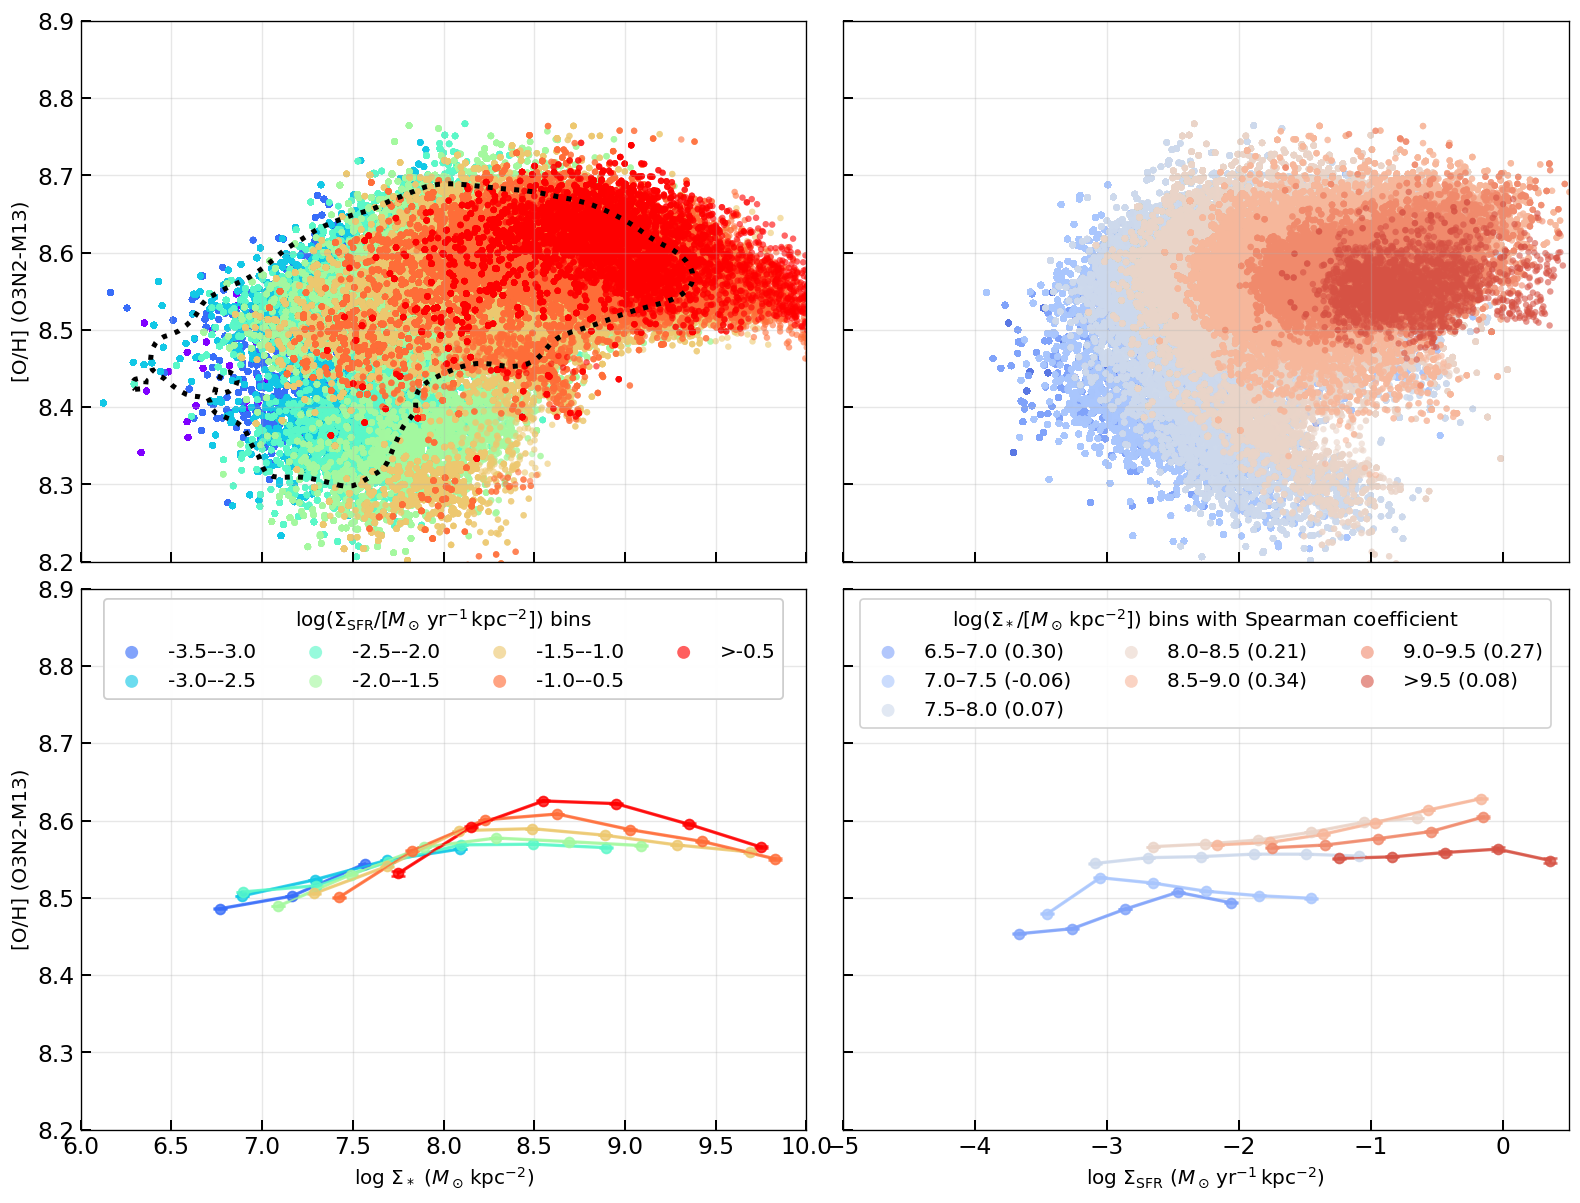


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 28 galaxies
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (8 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)
  Bottom-left: rMZR median trends (8 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [7]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
    # Using O3N2-M13 indicator only
    # 2x2 subplot layout:
    #   Top-left: rMZR scatter
    #   Top-right: Z_gas-Σ_SFR scatter
    #   Bottom-left: rMZR median trends
    #   Bottom-right: Z_gas-Σ_SFR median trends
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    import scipy.stats as stats
    import scipy.ndimage as ndimage
    from scipy.optimize import curve_fit

    def load_maps_o3n2_m13(gal):
        """Load O3N2-M13 metallicity calibration for HII regions"""
        with fits.open(further_spatial_path(gal)) as h:
            sigM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(further_gas_path(gal)) as h:
            sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h['HA6562_SIGMA'].data
            ha_sigma_corr = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gal}_gas_BIN_maps_extended.fits')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        with fits.open(further_ew_path(gal, EW_FILE_SUFFIX)) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f'Missing {EW_HDU} in {gal}{EW_FILE_SUFFIX}')
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII = np.where(ew_mask, sigSFR_HII, np.nan)
        oh_o3n2_m13_HII = np.where(ew_mask, oh_o3n2_m13_HII, np.nan)
        return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

    def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
        """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (x_data >= bin_start) & (x_data < bin_end)
            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_pixels:
                medians.append(np.median(y_in_bin))
                stds.append(np.std(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])
                valid_bin_indices.append(i)
        return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

    def mzr_model(x, a, b, c):
        return a + b * (x - c) * np.exp(-(x - c))

    def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
        """Return mask for points inside the 95% density contour within given ranges."""
        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        if not np.any(mask_finite):
            empty_mask = np.zeros_like(x_vals, dtype=bool)
            return (empty_mask, None, None) if return_contour else empty_mask
        x = x_vals[mask_finite]
        y = y_vals[mask_finite]
        H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)
        level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
        level_95 = H_flat[level_idx]
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins
        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5
        densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
        mask_local = densities >= level_95
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local
        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)
        return full_mask

    def plot_literature_mzr_fits(ax, show_legend=True):
        plot_data = []
        x_sanchez = np.linspace(7.05, 9.15, 200)
        a5, b5, c5 = 8.74, 0.013, 9.50
        y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
        plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
        x_bb = np.linspace(7., 8.9, 200)
        a2, b2, c2 = 8.55, 0.014, 9.14
        y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
        plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
        x_ef = np.linspace(6.5, 10.0, 200)
        a4, b4, c4 = 8.61, 0.008, 10.0
        y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
        plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
        for x, y, label, linestyle, color in plot_data:
            ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

    galaxies = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}
    included_galaxies = []
    all_logSigmaM_HII = []
    all_logSigmaSFR_HII = []
    all_oh_o3n2_m13_HII = []

    print("="*80)
    print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
    print("="*80)

    for gal in galaxies:
        if gal in excluded_galaxies:
            print(f"  {gal}: excluded from analysis")
            continue
        bin_file = further_spatial_path(gal)
        gas_file = further_gas_path(gal)
        if bin_file.exists() and gas_file.exists():
            included_galaxies.append(gal)
            (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
            common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
            print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
            all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        else:
            print(f"  {gal}: Data files not found")

    all_logSigmaM_HII = np.array(all_logSigmaM_HII)
    all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
    all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
    print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

    print("\n" + "="*80)
    print("STEP 2: Defining 8 SFR bins for rMZR")
    print("="*80)
    n_bins = 8
    sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
    bin_labels = ['<-3.5', '-3.5–-3.0', '-3.0–-2.5', '-2.5–-2.0', '-2.0–-1.5', '-1.5–-1.0', '-1.0–-0.5', '>-0.5']
    for i, label in enumerate(bin_labels):
        print(f"  Bin {i+1}: {label}")
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

    print("\n" + "="*80)
    print("STEP 3: Defining 8 Σ_* bins for Z_gas-Σ_SFR")
    print("="*80)
    n_bins_sigmaM = 8
    sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
    bin_labels_sigmaM = ['<6.5', '6.5–7.0', '7.0–7.5', '7.5–8.0', '8.0–8.5', '8.5–9.0', '9.0–9.5', '>9.5']
    for i, label in enumerate(bin_labels_sigmaM):
        print(f"  Bin {i+1}: {label}")
    colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

    print("\n" + "="*80)
    print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
    print("="*80)
    common_ylim = (8.2, 8.9)
    x_range_rMZR = (6, 10)
    x_range_Zgas = (-5.0, 0.5)
    print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    oh_data_HII = all_oh_o3n2_m13_HII
    calib_name_HII = 'O3N2-M13'
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    ax_rMZR_scatter = axes[0, 0]
    ax_Zgas_scatter = axes[0, 1]
    ax_rMZR_median = axes[1, 0]
    ax_Zgas_median = axes[1, 1]

    mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
    max_typical_yerr_rMZR = np.nan
    max_typical_yerr_Zgas = np.nan

    print(f"\n--- Processing rMZR (8 Σ_SFR bins) ---")
    legend_handles_sfr, legend_labels_sfr = [], []
    valid_bins_rMZR = 0
    for i in range(n_bins):
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaM_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            if len(x_bin) >= 10:
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
                if len(mass_centers_HII) >= 3:
                    legend_handles_sfr.append(scatter_hii)
                    legend_labels_sfr.append(bin_labels[i])
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                    ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                    valid_bins_rMZR += 1

    if contour_data_rMZR is not None and level_95_all_rMZR is not None:
        ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
    ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_scatter.grid(True, alpha=0.3)
    ax_rMZR_scatter.set_xlim(*x_range_rMZR)
    ax_rMZR_scatter.set_ylim(common_ylim)
    ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_median.grid(True, alpha=0.3)
    ax_rMZR_median.set_xlim(*x_range_rMZR)
    ax_rMZR_median.set_ylim(common_ylim)
    legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
    legend1_handles = getattr(legend1, "legend_handles", None)
    if legend1_handles is None:
        legend1_handles = getattr(legend1, "legendHandles", [])
    for handle in legend1_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    ax_rMZR_median.add_artist(legend1)
    # if np.isfinite(max_typical_yerr_rMZR):
    #     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  rMZR valid bins: {valid_bins_rMZR}")

    print(f"\n--- Processing Z_gas-Σ_SFR (8 Σ_* bins) ---")
    legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
    valid_bins_Zgas = 0
    for i in range(n_bins_sigmaM):
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            spearman_text = "N/A"
            if len(x_bin) > 1:
                y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
                x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
                mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
                sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
                if len(sfr_centers_HII) >= 3:
                    if len(x_clipped) > 10:
                        corr, _ = stats.spearmanr(x_clipped, y_clipped)
                        spearman_text = f"{corr:.2f}"
                    legend_handles_sigmaM.append(scatter_hii)
                    legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                    ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                    valid_bins_Zgas += 1


    ax_Zgas_scatter.grid(True, alpha=0.3)
    ax_Zgas_scatter.set_xlim(*x_range_Zgas)
    ax_Zgas_scatter.set_ylim(common_ylim)
    ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_Zgas_median.grid(True, alpha=0.3)
    ax_Zgas_median.set_xlim(*x_range_Zgas)
    ax_Zgas_median.set_ylim(common_ylim)
    legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
    legend2_handles = getattr(legend2, "legend_handles", None)
    if legend2_handles is None:
        legend2_handles = getattr(legend2, "legendHandles", [])
    for handle in legend2_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    # if np.isfinite(max_typical_yerr_Zgas):
    #     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.png', dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.pdf', bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
    print("="*80)
    print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
    print("\nPanel summary:")
    print("  Top-left: rMZR scatter (8 Σ_SFR bins)")
    print("  Top-right: Z_gas-Σ_SFR scatter (8 Σ_* bins)")
    print("  Bottom-left: rMZR median trends (8 Σ_SFR bins)")
    print("  Bottom-right: Z_gas-Σ_SFR median trends (8 Σ_* bins)")
    print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
else:
    print("Skipped copied previous-project analysis cell 15: no nested *_further mass/SFR/OH+EW products are ready yet.")


## Source notebook cell 17 looped per galaxy

This cell adapts the one-based source cell 17 2x2 [O/H]-SFR relation plot so it runs once for every available mixed-source galaxy.


Building source cell 17 all-galaxy contours from 29 mixed-source galaxies:
IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Looping source cell 17 per galaxy for 2 focus galaxies:
NGC4294, NGC4298
All-galaxy 95% contours use 29 galaxies and 1794442 valid HII pixels after EW/sigma mask.
NGC4294: source=further_ready; valid HII pixels after EW/sigma mask=67102


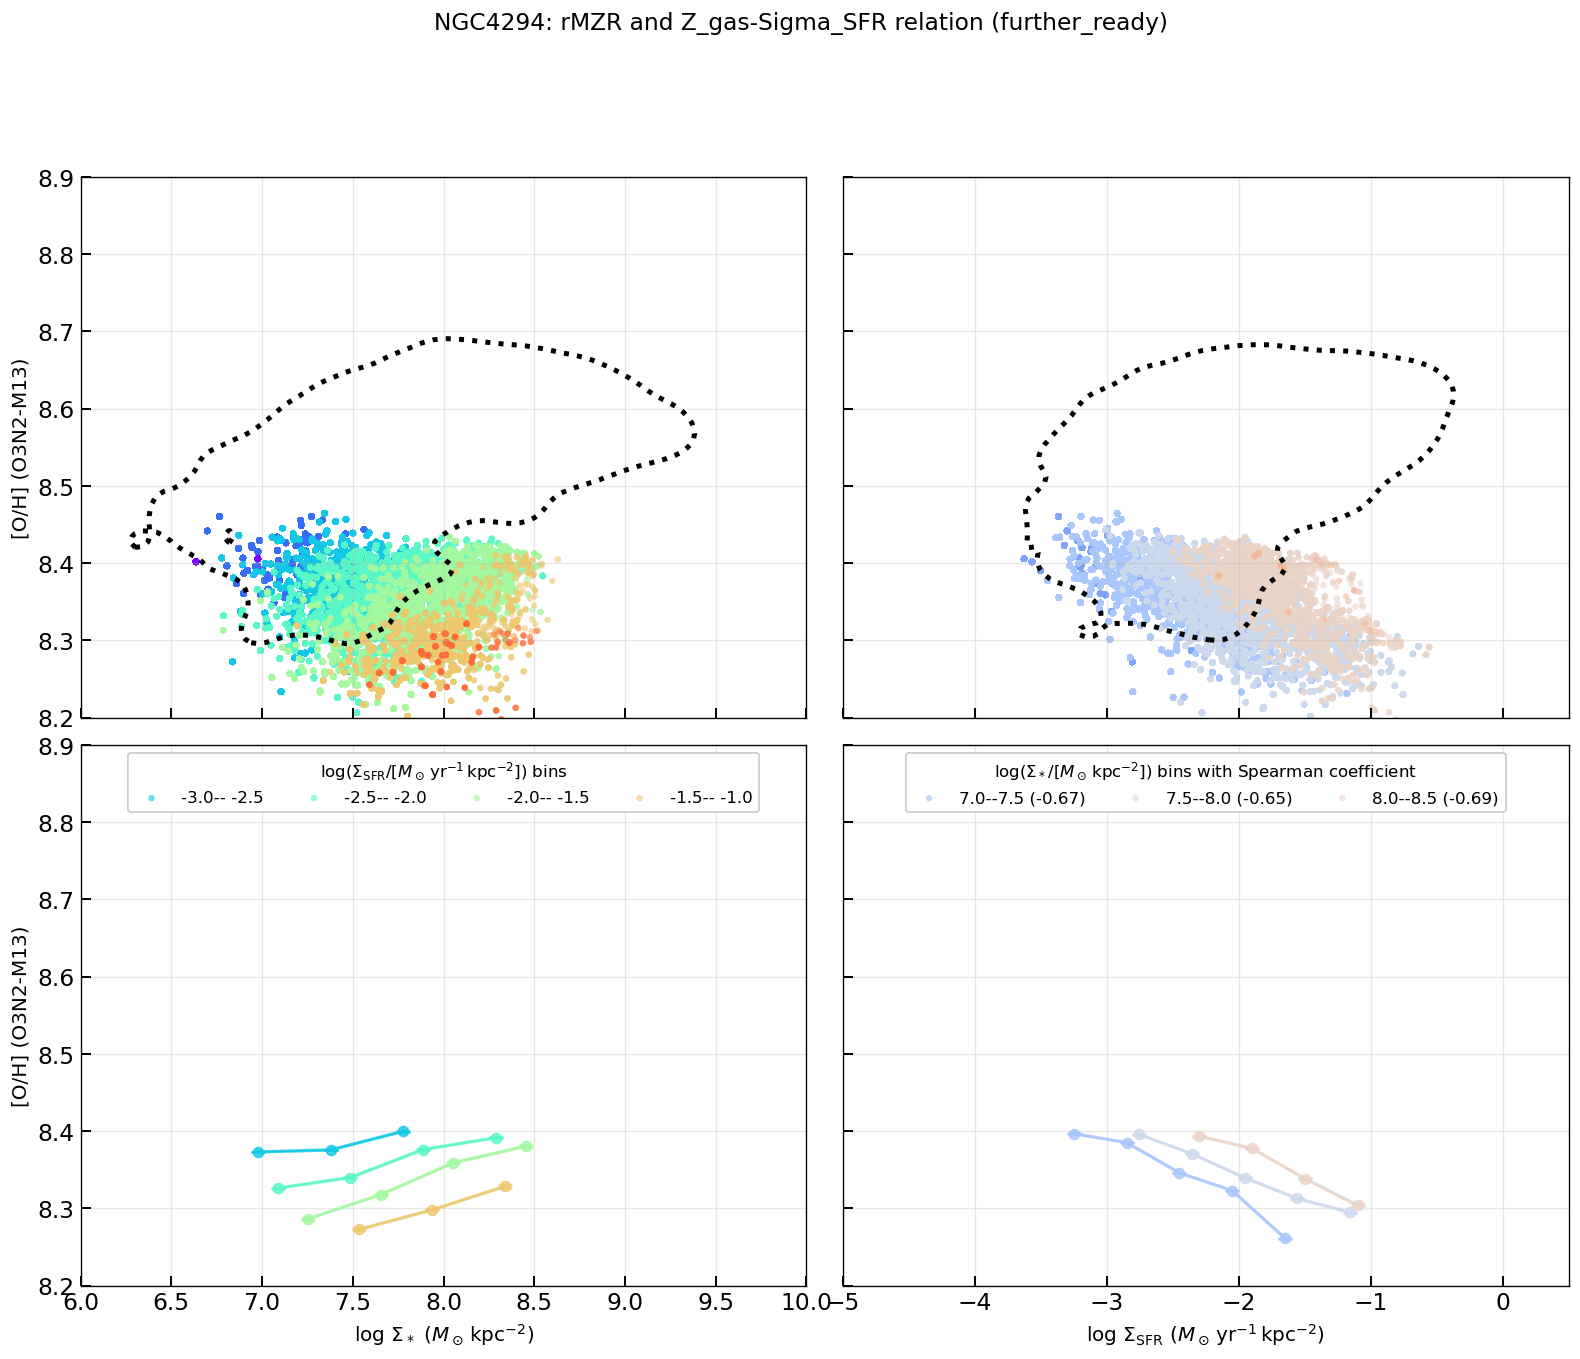

NGC4294: rMZR valid bins=4; Z_gas-Sigma_SFR valid bins=3
NGC4298: source=further_ready; valid HII pixels after EW/sigma mask=103876


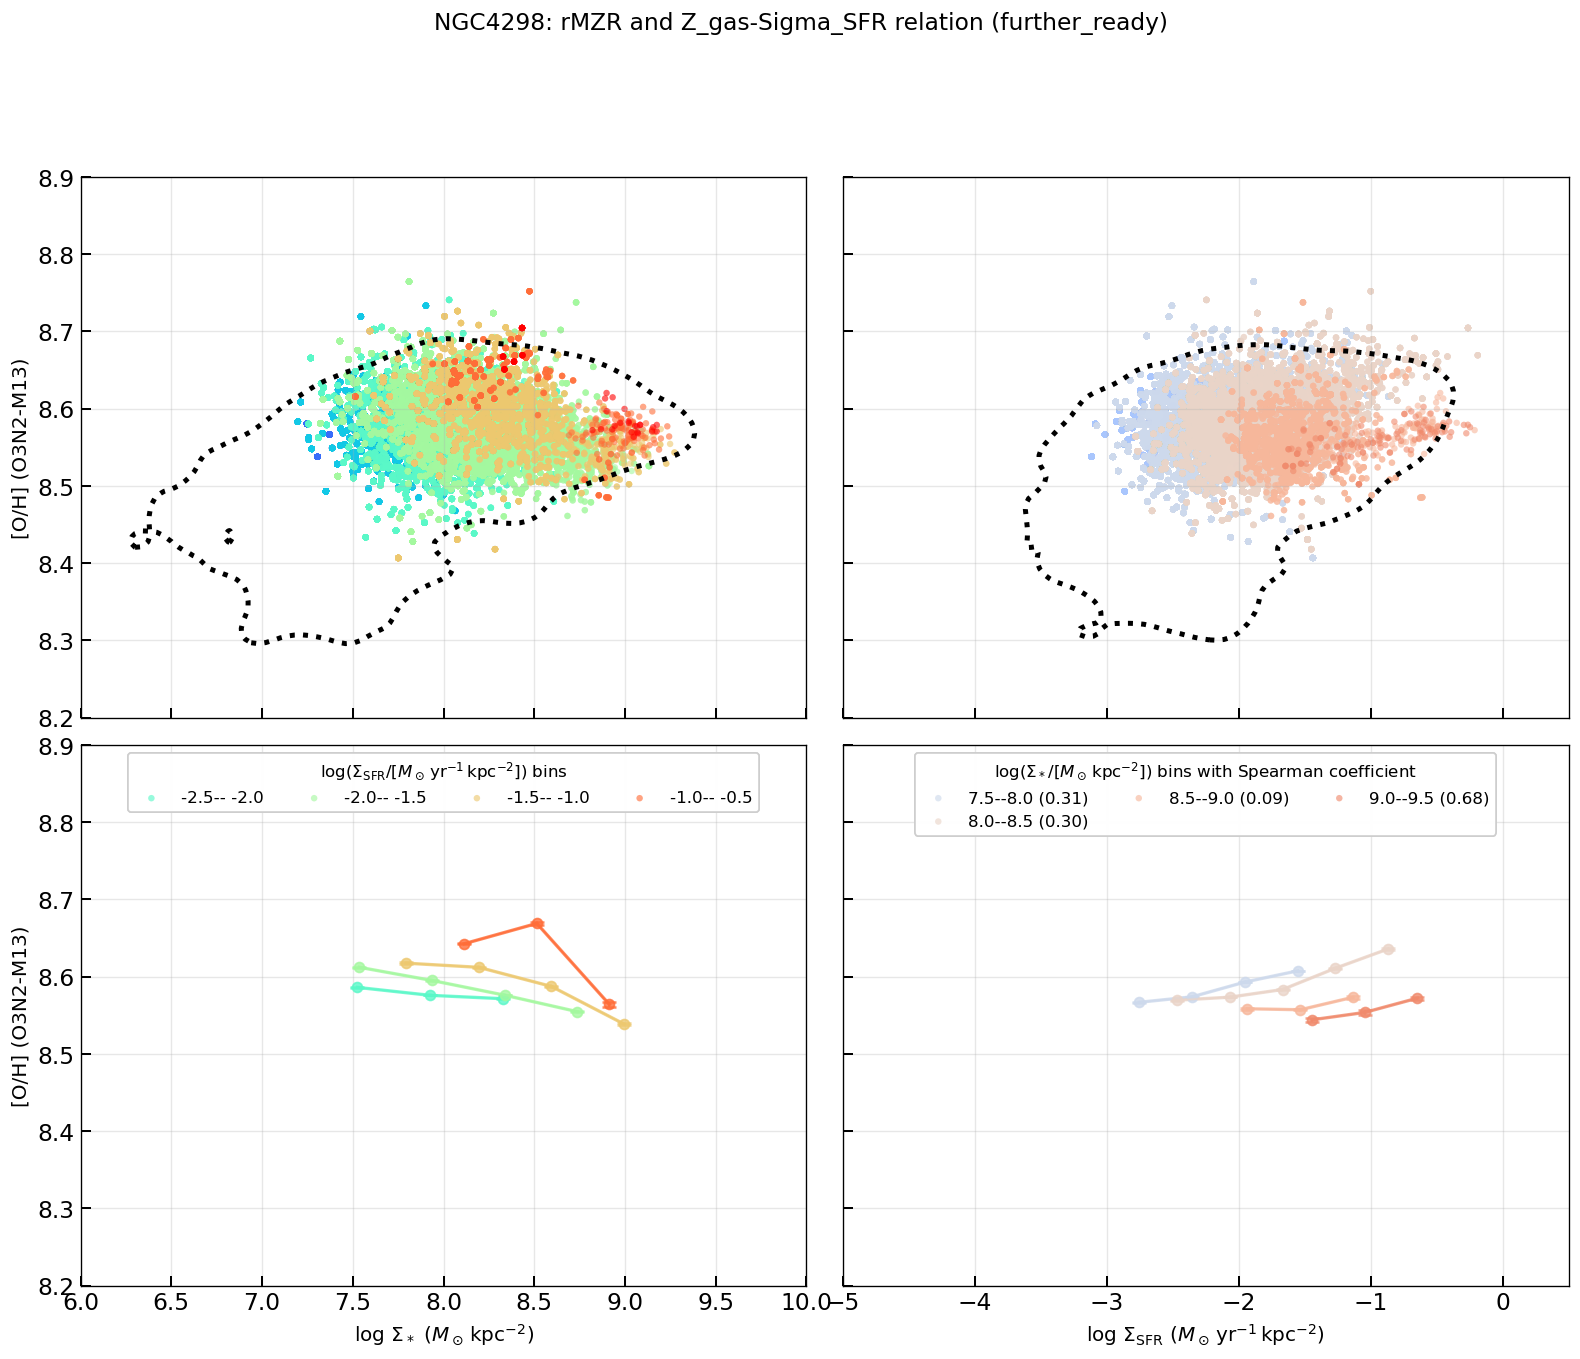

NGC4298: rMZR valid bins=4; Z_gas-Sigma_SFR valid bins=4


In [8]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Source notebook one-based cell 17, looped over FOCUS_GALAXIES only.
    # Each figure keeps the same 2x2 rMZR / Z_gas-Sigma_SFR layout.
    # Pooled black contours use all available ready galaxies; plotted figures use FOCUS_GALAXIES.
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from astropy.io import fits
    import scipy.stats as stats
    import scipy.ndimage as ndimage

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    def load_maps_o3n2_m13_for_cell17(gal):
        """Load HII Sigma_*, Sigma_SFR, and O3N2-M13 maps with the source-cell EW/sigma mask."""
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)
        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
        with fits.open(gas_path) as h_gas:
            sigSFR_HII = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            if 'HA6562_SIGMA_CORR' not in h_gas:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            ha_sigma_corr = align_map_to_shape(
                h_gas['HA6562_SIGMA_CORR'].data,
                ha_sigma_obs.shape,
                label=f'{gal} HA6562_SIGMA_CORR',
            )
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2_m13_HII = np.asarray(h_gas['O_H_O3N2_M13_HII'].data, dtype=float)
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f'Missing {EW_HDU} in {ew_path}')
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f'{gal} {EW_HDU}')
        sigM = align_map_to_shape(sigM, sigSFR_HII.shape, label=f'{gal} LOGMASS_SURFACE_DENSITY')
        oh_o3n2_m13_HII = align_map_to_shape(oh_o3n2_m13_HII, sigSFR_HII.shape, label=f'{gal} O_H_O3N2_M13_HII')
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII = np.where(ew_mask, sigSFR_HII, np.nan)
        oh_o3n2_m13_HII = np.where(ew_mask, oh_o3n2_m13_HII, np.nan)
        return sigM, sigSFR_HII, oh_o3n2_m13_HII

    def calculate_binned_stats_cell17(x_data, y_data, bin_width=0.4, min_pixels=20):
        x_data = np.asarray(x_data, dtype=float)
        y_data = np.asarray(y_data, dtype=float)
        finite = np.isfinite(x_data) & np.isfinite(y_data)
        if not np.any(finite):
            empty = np.array([])
            return empty, empty, empty, empty, empty
        x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
            empty = np.array([])
            return empty, empty, empty, empty, empty
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            empty = np.array([])
            return empty, empty, empty, empty, empty
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_pixels:
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])
                valid_bin_indices.append(i)
        return (
            np.asarray(valid_centers),
            np.asarray(medians),
            np.asarray(stds),
            np.asarray(counts),
            np.asarray(valid_bin_indices),
        )

    def compute_density_mask_cell17(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
        x_vals = np.asarray(x_vals, dtype=float)
        y_vals = np.asarray(y_vals, dtype=float)
        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        if np.sum(mask_finite) < 3:
            return (empty_mask, None, None) if return_contour else empty_mask
        x = x_vals[mask_finite]
        y = y_vals[mask_finite]
        H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
        if not np.any(H > 0):
            return (empty_mask, None, None) if return_contour else empty_mask
        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)
        if H_cumsum.size == 0 or H_cumsum[-1] <= 0:
            return (empty_mask, None, None) if return_contour else empty_mask
        level_idx = min(np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1]), H_flat.size - 1)
        level_95 = H_flat[level_idx]
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins
        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5
        densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
        mask_local = densities >= level_95
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local
        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)
        return full_mask

    CELL17_COMMON_YLIM = (8.2, 8.9)
    CELL17_X_RANGE_RMZR = (6.0, 10.0)
    CELL17_X_RANGE_ZGAS = (-5.0, 0.5)
    CELL17_GALAXY_MAP_CACHE = {}

    def get_cell17_maps(gal):
        if gal not in CELL17_GALAXY_MAP_CACHE:
            CELL17_GALAXY_MAP_CACHE[gal] = load_maps_o3n2_m13_for_cell17(gal)
        return CELL17_GALAXY_MAP_CACHE[gal]

    def collect_cell17_global_contours(galaxies):
        global_logSigmaM = []
        global_logSigmaSFR = []
        global_oh = []
        global_counts = {}
        skipped = {}

        for gal in galaxies:
            try:
                logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = get_cell17_maps(gal)
                common_mask_HII = (
                    np.isfinite(logSigmaM)
                    & np.isfinite(logSigmaSFR_HII)
                    & np.isfinite(oh_o3n2_m13_HII)
                )
                n_valid = int(np.sum(common_mask_HII))
                global_counts[gal] = n_valid
                if n_valid <= 0:
                    continue
                global_logSigmaM.append(logSigmaM[common_mask_HII].ravel())
                global_logSigmaSFR.append(logSigmaSFR_HII[common_mask_HII].ravel())
                global_oh.append(oh_o3n2_m13_HII[common_mask_HII].ravel())
            except Exception as exc:
                skipped[gal] = str(exc)

        if global_logSigmaM:
            all_logSigmaM = np.concatenate(global_logSigmaM)
            all_logSigmaSFR = np.concatenate(global_logSigmaSFR)
            all_oh = np.concatenate(global_oh)
        else:
            all_logSigmaM = np.array([])
            all_logSigmaSFR = np.array([])
            all_oh = np.array([])

        _, rMZR_level, rMZR_contour = compute_density_mask_cell17(
            all_logSigmaM,
            all_oh,
            CELL17_X_RANGE_RMZR,
            CELL17_COMMON_YLIM,
            return_contour=True,
        )
        _, zgas_level, zgas_contour = compute_density_mask_cell17(
            all_logSigmaSFR,
            all_oh,
            CELL17_X_RANGE_ZGAS,
            CELL17_COMMON_YLIM,
            return_contour=True,
        )
        print(
            f'All-galaxy 95% contours use {len(global_counts)} galaxies '
            f'and {len(all_oh)} valid HII pixels after EW/sigma mask.'
        )
        if skipped:
            print('Skipped while building all-galaxy contours:', skipped)
        return {
            'rMZR': (rMZR_level, rMZR_contour),
            'zgas': (zgas_level, zgas_contour),
            'counts': global_counts,
            'skipped': skipped,
        }

    def plot_cell17_for_one_galaxy(gal):
        source_label = PRODUCTS.loc[gal, 'source'] if gal in PRODUCTS.index else 'unknown'
        try:
            logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = get_cell17_maps(gal)
        except Exception as exc:
            print(f'{gal}: skipped ({exc})')
            return None

        common_mask_HII = np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        n_valid = int(np.sum(common_mask_HII))
        if n_valid < 10:
            print(f'{gal}: skipped (only {n_valid} valid HII pixels after EW/sigma mask)')
            return None

        x_mass = logSigmaM[common_mask_HII].ravel()
        x_sfr = logSigmaSFR_HII[common_mask_HII].ravel()
        y_oh = oh_o3n2_m13_HII[common_mask_HII].ravel()

        n_bins = 8
        sfr_bin_edges = [-np.inf, -3.5, -3.0, -2.5, -2.0, -1.5, -1.0, -0.5, np.inf]
        bin_labels = ['<-3.5', '-3.5-- -3.0', '-3.0-- -2.5', '-2.5-- -2.0', '-2.0-- -1.5', '-1.5-- -1.0', '-1.0-- -0.5', '>-0.5']
        colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

        n_bins_sigmaM = 8
        sigmaM_bin_edges = [-np.inf, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, np.inf]
        bin_labels_sigmaM = ['<6.5', '6.5--7.0', '7.0--7.5', '7.5--8.0', '8.0--8.5', '8.5--9.0', '9.0--9.5', '>9.5']
        colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

        common_ylim = CELL17_COMMON_YLIM
        x_range_rMZR = CELL17_X_RANGE_RMZR
        x_range_Zgas = CELL17_X_RANGE_ZGAS

        print('=' * 80)
        print(f'{gal}: source={source_label}; valid HII pixels after EW/sigma mask={n_valid}')
        print('=' * 80)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        ax_rMZR_scatter, ax_Zgas_scatter = axes[0, 0], axes[0, 1]
        ax_rMZR_median, ax_Zgas_median = axes[1, 0], axes[1, 1]

        global_rMZR_level, global_rMZR_contour = CELL17_GLOBAL_CONTOURS['rMZR']
        global_zgas_level, global_zgas_contour = CELL17_GLOBAL_CONTOURS['zgas']

        legend_handles_sfr, legend_labels_sfr = [], []
        valid_bins_rMZR = 0
        for i in range(n_bins):
            in_bin = (x_sfr >= sfr_bin_edges[i]) & (x_sfr < sfr_bin_edges[i + 1])
            if np.sum(in_bin) < 10:
                continue
            x_bin_all = x_mass[in_bin]
            y_bin_all = y_oh[in_bin]
            scatter_hii = ax_rMZR_scatter.scatter(
                x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6,
                edgecolors='none', rasterized=True,
            )
            mask_95_bin = compute_density_mask_cell17(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            if len(x_bin) < 10:
                continue
            mass_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats_cell17(
                x_bin, y_bin, bin_width=0.4, min_pixels=20
            )
            if len(mass_centers) < 3:
                continue
            legend_handles_sfr.append(scatter_hii)
            legend_labels_sfr.append(bin_labels[i])
            yerr = stds / np.sqrt(counts)
            ax_rMZR_median.errorbar(
                mass_centers, medians, yerr=yerr, color=colors_sfr[i], marker='o',
                markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8,
            )
            for j in range(len(valid_bin_indices) - 1):
                if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                    ax_rMZR_median.plot(
                        [mass_centers[j], mass_centers[j + 1]],
                        [medians[j], medians[j + 1]],
                        color=colors_sfr[i], linewidth=2, alpha=0.8,
                    )
            valid_bins_rMZR += 1

        if global_rMZR_contour is not None and global_rMZR_level is not None:
            ax_rMZR_scatter.contour(
                global_rMZR_contour[0], global_rMZR_contour[1], global_rMZR_contour[2].T,
                levels=[global_rMZR_level], colors='k', linewidths=3, linestyles=':',
            )
        ax_rMZR_scatter.set_ylabel('[O/H] (O3N2-M13)', fontsize=12)
        ax_rMZR_scatter.grid(True, alpha=0.3)
        ax_rMZR_scatter.set_xlim(*x_range_rMZR)
        ax_rMZR_scatter.set_ylim(common_ylim)
        ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_rMZR_median.set_ylabel('[O/H] (O3N2-M13)', fontsize=12)
        ax_rMZR_median.grid(True, alpha=0.3)
        ax_rMZR_median.set_xlim(*x_range_rMZR)
        ax_rMZR_median.set_ylim(common_ylim)
        if legend_handles_sfr:
            legend1 = ax_rMZR_median.legend(
                legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4,
                fontsize=10, framealpha=0.9,
                title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins',
                title_fontsize=10,
            )
            ax_rMZR_median.add_artist(legend1)

        legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
        valid_bins_Zgas = 0
        for i in range(n_bins_sigmaM):
            in_bin = (x_mass >= sigmaM_bin_edges[i]) & (x_mass < sigmaM_bin_edges[i + 1])
            if np.sum(in_bin) < 10:
                continue
            x_bin_all = x_sfr[in_bin]
            y_bin_all = y_oh[in_bin]
            scatter_hii = ax_Zgas_scatter.scatter(
                x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6,
                edgecolors='none', rasterized=True,
            )
            mask_95_bin = compute_density_mask_cell17(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            spearman_text = 'N/A'
            if len(x_bin) > 1:
                y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
                x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
                mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
                sfr_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats_cell17(
                    x_clipped, y_clipped, bin_width=0.4, min_pixels=20
                )
                if len(sfr_centers) >= 3:
                    if len(x_clipped) > 10:
                        corr, _ = stats.spearmanr(x_clipped, y_clipped)
                        spearman_text = f'{corr:.2f}'
                    legend_handles_sigmaM.append(scatter_hii)
                    legend_labels_sigmaM_display.append(f'{bin_labels_sigmaM[i]} ({spearman_text})')
                    yerr = stds / np.sqrt(counts)
                    ax_Zgas_median.errorbar(
                        sfr_centers, medians, yerr=yerr, color=colors_sigmaM[i], marker='o',
                        markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8,
                    )
                    for j in range(len(valid_bin_indices) - 1):
                        if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                            ax_Zgas_median.plot(
                                [sfr_centers[j], sfr_centers[j + 1]],
                                [medians[j], medians[j + 1]],
                                color=colors_sigmaM[i], linewidth=2, alpha=0.8,
                            )
                    valid_bins_Zgas += 1

        if global_zgas_contour is not None and global_zgas_level is not None:
            ax_Zgas_scatter.contour(
                global_zgas_contour[0], global_zgas_contour[1], global_zgas_contour[2].T,
                levels=[global_zgas_level], colors='k', linewidths=3, linestyles=':',
            )
        ax_Zgas_scatter.grid(True, alpha=0.3)
        ax_Zgas_scatter.set_xlim(*x_range_Zgas)
        ax_Zgas_scatter.set_ylim(common_ylim)
        ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_Zgas_median.grid(True, alpha=0.3)
        ax_Zgas_median.set_xlim(*x_range_Zgas)
        ax_Zgas_median.set_ylim(common_ylim)
        if legend_handles_sigmaM:
            legend2 = ax_Zgas_median.legend(
                legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3,
                fontsize=10, framealpha=0.9,
                title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient',
                title_fontsize=10,
            )
            ax_Zgas_median.add_artist(legend2)

        fig.suptitle(f'{gal}: rMZR and Z_gas-Sigma_SFR relation ({source_label})', fontsize=14, y=0.995)
        # fig.savefig(OUTDIR / f'{gal}_source_cell17_individual_OH_SFR.png', dpi=300, bbox_inches='tight')
        # fig.savefig(OUTDIR / f'{gal}_source_cell17_individual_OH_SFR.pdf', bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'{gal}: rMZR valid bins={valid_bins_rMZR}; Z_gas-Sigma_SFR valid bins={valid_bins_Zgas}')
        return fig

    CELL17_ALL_GALAXIES_FOR_CONTOURS = ordered_galaxies_by_fixed_palette(physics_ready_galaxies(require_ew=True))
    PER_GALAXY_CELL17_GALAXIES = [
        gal for gal in FOCUS_GALAXIES
        if gal in physics_ready_galaxies(require_ew=True)
    ]
    missing_focus = [gal for gal in FOCUS_GALAXIES if gal not in PER_GALAXY_CELL17_GALAXIES]
    if missing_focus:
        print('Focus galaxies skipped because products are not science-ready with EW maps:', ', '.join(missing_focus))
    print(f'Building source cell 17 all-galaxy contours from {len(CELL17_ALL_GALAXIES_FOR_CONTOURS)} mixed-source galaxies:')
    print(', '.join(CELL17_ALL_GALAXIES_FOR_CONTOURS))
    print(f'Looping source cell 17 per galaxy for {len(PER_GALAXY_CELL17_GALAXIES)} focus galaxies:')
    print(', '.join(PER_GALAXY_CELL17_GALAXIES) if PER_GALAXY_CELL17_GALAXIES else 'none')
    CELL17_GLOBAL_CONTOURS = collect_cell17_global_contours(CELL17_ALL_GALAXIES_FOR_CONTOURS)
    for galaxy in PER_GALAXY_CELL17_GALAXIES:
        plot_cell17_for_one_galaxy(galaxy)
else:
    print('Skipped focused per-galaxy source-cell-17 loop: no mixed-source mass/SFR/OH+EW products are ready yet.')


STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...
  IC3392: HII=10750 pixels
  NGC4064: HII=2735 pixels
  NGC4189: HII=79662 pixels
  NGC4192: HII=121858 pixels
  NGC4254: HII=631740 pixels
  NGC4293: HII=316 pixels
  NGC4294: HII=67102 pixels
  NGC4298: HII=103876 pixels
  NGC4302: HII=17835 pixels
  NGC4330: HII=28268 pixels
  NGC4351: HII=26367 pixels
  NGC4383: excluded from analysis
  NGC4388: HII=17173 pixels
  NGC4394: HII=17856 pixels
  NGC4396: HII=82548 pixels
  NGC4402: HII=35164 pixels
  NGC4405: HII=10135 pixels
  NGC4419: HII=3997 pixels
  NGC4450: HII=11951 pixels
  NGC4457: HII=5560 pixels
  NGC4501: HII=198672 pixels
  NGC4522: HII=39407 pixels
  NGC4567_8: HII=184719 pixels
  NGC4569: HII=36618 pixels
  NGC4580: HII=14984 pixels
  NGC4606: HII=1091 pixels
  NGC4607: HII=13891 pixels
  NGC4694: HII=867 pixels
  NGC4698: HII=3905 pixels

Total combined pixels (HII): 1769047

STEP 2: Defining 14 SFR bins for rMZR
  Bin 1: <-3.5
  Bin 2: -3.5–-3

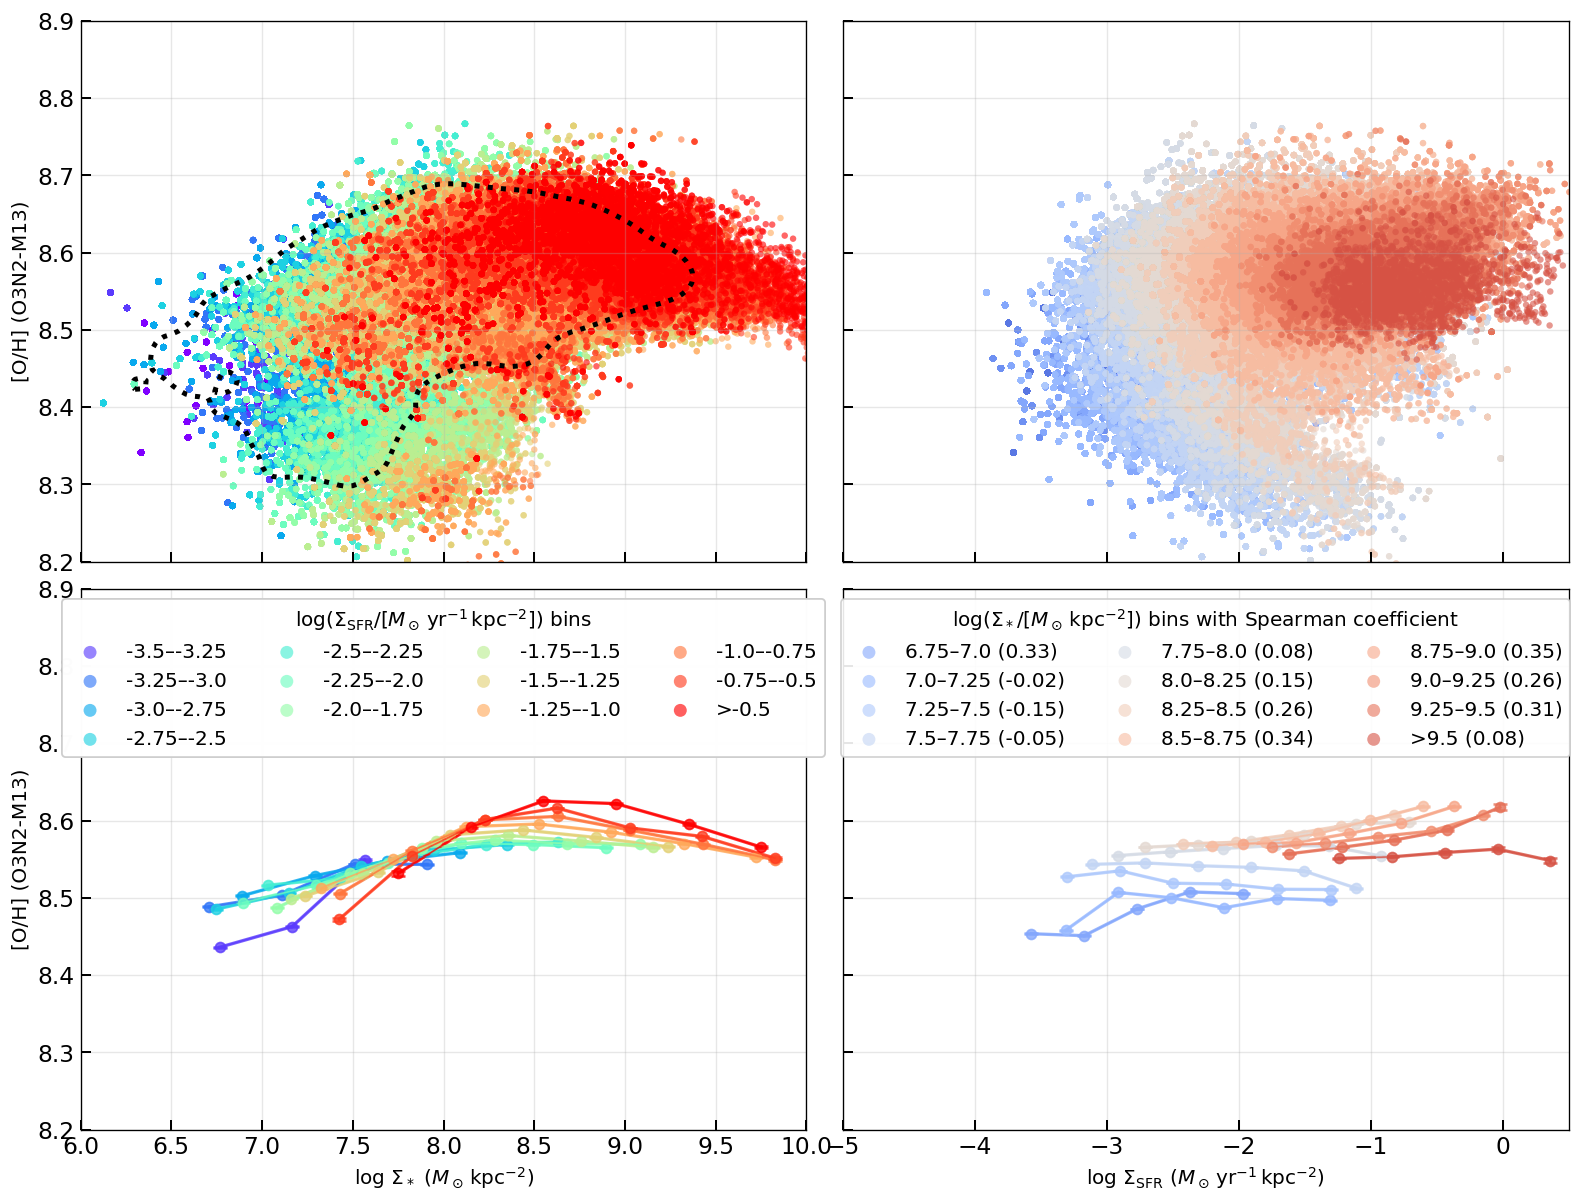


COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)
Successfully created 2x2 subplot figure showing HII regions from 28 galaxies
Galaxies included: IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Excluded: NGC4383

Panel summary:
  Top-left: rMZR scatter (14 Σ_SFR bins)
  Top-right: Z_gas-Σ_SFR scatter (14 Σ_* bins)
  Bottom-left: rMZR median trends (14 Σ_SFR bins)
  Bottom-right: Z_gas-Σ_SFR median trends (14 Σ_* bins)
  Shared y-range: 8.2 to 8.9


In [9]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Combined Analysis: rMZR and Z_gas-Σ_SFR relation - HII regions only
    # Using O3N2-M13 indicator only
    # 2x2 subplot layout:
    #   Top-left: rMZR scatter
    #   Top-right: Z_gas-Σ_SFR scatter
    #   Bottom-left: rMZR median trends
    #   Bottom-right: Z_gas-Σ_SFR median trends
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    import scipy.stats as stats
    import scipy.ndimage as ndimage
    from scipy.optimize import curve_fit

    def load_maps_o3n2_m13(gal):
        """Load O3N2-M13 metallicity calibration for HII regions"""
        with fits.open(further_spatial_path(gal)) as h:
            sigM = h['LOGMASS_SURFACE_DENSITY'].data
        with fits.open(further_gas_path(gal)) as h:
            sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
            ha_sigma_obs = h['HA6562_SIGMA'].data
            ha_sigma_corr = h['HA6562_SIGMA_CORR'].data if 'HA6562_SIGMA_CORR' in h else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gal}_gas_BIN_maps_extended.fits')
            if ha_sigma_corr.shape != ha_sigma_obs.shape:
                raise ValueError(f'{gal}: shape mismatch SIGMA_CORR {ha_sigma_corr.shape} vs SIGMA {ha_sigma_obs.shape}')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        with fits.open(further_ew_path(gal, EW_FILE_SUFFIX)) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f'Missing {EW_HDU} in {gal}{EW_FILE_SUFFIX}')
            ew_ha = h_ew[EW_HDU].data
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f"{gal} {EW_HDU}")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII = np.where(ew_mask, sigSFR_HII, np.nan)
        oh_o3n2_m13_HII = np.where(ew_mask, oh_o3n2_m13_HII, np.nan)
        return (sigM, sigSFR_HII, oh_o3n2_m13_HII)

    def calculate_binned_stats(x_data, y_data, bin_width=0.4, min_pixels=20):
        """Calculate median and std in bins - only keep bins with >= min_pixels unique datapoints"""
        x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = (x_data >= bin_start) & (x_data < bin_end)
            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_pixels:
                medians.append(np.median(y_in_bin))
                stds.append(np.std(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])
                valid_bin_indices.append(i)
        return (np.array(valid_centers), np.array(medians), np.array(stds), np.array(counts), np.array(valid_bin_indices))

    def mzr_model(x, a, b, c):
        return a + b * (x - c) * np.exp(-(x - c))

    def compute_density_mask(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
        """Return mask for points inside the 95% density contour within given ranges."""
        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        if not np.any(mask_finite):
            empty_mask = np.zeros_like(x_vals, dtype=bool)
            return (empty_mask, None, None) if return_contour else empty_mask
        x = x_vals[mask_finite]
        y = y_vals[mask_finite]
        H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)
        level_idx = np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1])
        level_95 = H_flat[level_idx]
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins
        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5
        densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
        mask_local = densities >= level_95
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local
        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)
        return full_mask

    def plot_literature_mzr_fits(ax, show_legend=True):
        plot_data = []
        x_sanchez = np.linspace(7.05, 9.15, 200)
        a5, b5, c5 = 8.74, 0.013, 9.50
        y_sanchez13 = a5 + b5 * (x_sanchez - c5) * np.exp(-(x_sanchez - c5))
        plot_data.append((x_sanchez, y_sanchez13, 'Sánchez+13', ':', 'olive'))
        x_bb = np.linspace(7., 8.9, 200)
        a2, b2, c2 = 8.55, 0.014, 9.14
        y_bb16 = a2 + b2 * (x_bb - c2) * np.exp(-(x_bb - c2))
        plot_data.append((x_bb, y_bb16, 'Barrera-Ballesteros+16', '--', 'brown'))
        x_ef = np.linspace(6.5, 10.0, 200)
        a4, b4, c4 = 8.61, 0.008, 10.0
        y_ef17 = a4 + b4 * (x_ef - c4) * np.exp(-(x_ef - c4))
        plot_data.append((x_ef, y_ef17, 'Erroz-Ferrer+17', '-.', 'pink'))
        for x, y, label, linestyle, color in plot_data:
            ax.plot(x, y, label=label if show_legend else None, linewidth=2, linestyle=linestyle, color=color)

    galaxies = physics_ready_galaxies(require_ew=True)
    excluded_galaxies = {'NGC4383'}
    included_galaxies = []
    all_logSigmaM_HII = []
    all_logSigmaSFR_HII = []
    all_oh_o3n2_m13_HII = []

    print("="*80)
    print("STEP 1: Collecting data from all galaxies for HII regions (O3N2-M13 only)...")
    print("="*80)

    for gal in galaxies:
        if gal in excluded_galaxies:
            print(f"  {gal}: excluded from analysis")
            continue
        bin_file = further_spatial_path(gal)
        gas_file = further_gas_path(gal)
        if bin_file.exists() and gas_file.exists():
            included_galaxies.append(gal)
            (logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII) = load_maps_o3n2_m13(gal)
            common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII))
            print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
            all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
            all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
            all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        else:
            print(f"  {gal}: Data files not found")

    all_logSigmaM_HII = np.array(all_logSigmaM_HII)
    all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
    all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
    print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

    print("\n" + "="*80)
    print("STEP 2: Defining 14 SFR bins for rMZR")
    print("="*80)
    n_bins = 14
    sfr_bin_edges = [-np.inf, -3.5, -3.25, -3.0, -2.75, -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, np.inf]
    bin_labels = ['<-3.5', '-3.5–-3.25', '-3.25–-3.0', '-3.0–-2.75', '-2.75–-2.5', '-2.5–-2.25',
                  '-2.25–-2.0', '-2.0–-1.75', '-1.75–-1.5', '-1.5–-1.25', '-1.25–-1.0', '-1.0–-0.75', '-0.75–-0.5', '>-0.5']
    for i, label in enumerate(bin_labels):
        print(f"  Bin {i+1}: {label}")
    colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

    print("\n" + "="*80)
    print("STEP 3: Defining 14 Σ_* bins for Z_gas-Σ_SFR")
    print("="*80)
    n_bins_sigmaM = 14
    sigmaM_bin_edges = [-np.inf, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, np.inf]
    bin_labels_sigmaM = ['<6.5', '6.5–6.75', '6.75–7.0', '7.0–7.25', '7.25–7.5', '7.5–7.75',
                         '7.75–8.0', '8.0–8.25', '8.25–8.5', '8.5–8.75', '8.75–9.0', '9.0–9.25', '9.25–9.5', '>9.5']
    for i, label in enumerate(bin_labels_sigmaM):
        print(f"  Bin {i+1}: {label}")
    colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

    print("\n" + "="*80)
    print("STEP 4: Creating combined 2x2 plot (O3N2-M13 only)")
    print("="*80)
    common_ylim = (8.2, 8.9)
    x_range_rMZR = (6, 10)
    x_range_Zgas = (-5.0, 0.5)
    print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    oh_data_HII = all_oh_o3n2_m13_HII
    calib_name_HII = 'O3N2-M13'
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    ax_rMZR_scatter = axes[0, 0]
    ax_Zgas_scatter = axes[0, 1]
    ax_rMZR_median = axes[1, 0]
    ax_Zgas_median = axes[1, 1]

    mask_95_all_rMZR, level_95_all_rMZR, contour_data_rMZR = compute_density_mask(all_logSigmaM_HII, oh_data_HII, x_range_rMZR, common_ylim, return_contour=True)
    max_typical_yerr_rMZR = np.nan
    max_typical_yerr_Zgas = np.nan

    print(f"\n--- Processing rMZR (14 Σ_SFR bins) ---")
    legend_handles_sfr, legend_labels_sfr = [], []
    valid_bins_rMZR = 0
    for i in range(n_bins):
        in_bin_HII = (all_logSigmaSFR_HII >= sfr_bin_edges[i]) & (all_logSigmaSFR_HII < sfr_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaM_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_rMZR_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            if len(x_bin) >= 10:
                mass_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_bin, y_bin, bin_width=0.4, min_pixels=20)
                if len(mass_centers_HII) >= 3:
                    legend_handles_sfr.append(scatter_hii)
                    legend_labels_sfr.append(bin_labels[i])
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    rMZR bin {i+1} {bin_labels[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_rMZR = np.nanmax([max_typical_yerr_rMZR, typical_yerr])
                    ax_rMZR_median.errorbar(mass_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sfr[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_rMZR_median.plot([mass_centers_HII[j], mass_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sfr[i], linewidth=2, alpha=0.8)
                    valid_bins_rMZR += 1

    if contour_data_rMZR is not None and level_95_all_rMZR is not None:
        ax_rMZR_scatter.contour(contour_data_rMZR[0], contour_data_rMZR[1], contour_data_rMZR[2].T, levels=[level_95_all_rMZR], colors='k', linewidths=3, linestyles=':')
    ax_rMZR_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_scatter.grid(True, alpha=0.3)
    ax_rMZR_scatter.set_xlim(*x_range_rMZR)
    ax_rMZR_scatter.set_ylim(common_ylim)
    ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_rMZR_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_rMZR_median.grid(True, alpha=0.3)
    ax_rMZR_median.set_xlim(*x_range_rMZR)
    ax_rMZR_median.set_ylim(common_ylim)
    legend1 = ax_rMZR_median.legend(legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins', title_fontsize=12)
    legend1_handles = getattr(legend1, "legend_handles", None)
    if legend1_handles is None:
        legend1_handles = getattr(legend1, "legendHandles", [])
    for handle in legend1_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    ax_rMZR_median.add_artist(legend1)
    # if np.isfinite(max_typical_yerr_rMZR):
    #     ax_rMZR_median.errorbar(x_range_rMZR[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_rMZR, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  rMZR valid bins: {valid_bins_rMZR}")

    print(f"\n--- Processing Z_gas-Σ_SFR (14 Σ_* bins) ---")
    legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
    valid_bins_Zgas = 0
    for i in range(n_bins_sigmaM):
        in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i + 1])
        n_pixels_HII = np.sum(in_bin_HII)
        if n_pixels_HII >= 10:
            x_bin_all = all_logSigmaSFR_HII[in_bin_HII]
            y_bin_all = oh_data_HII[in_bin_HII]
            scatter_hii = ax_Zgas_scatter.scatter(x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6, edgecolors='none', rasterized=True)
            mask_95_bin = compute_density_mask(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            spearman_text = "N/A"
            if len(x_bin) > 1:
                y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
                x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
                mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
                sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(x_clipped, y_clipped, bin_width=0.4, min_pixels=20)
                if len(sfr_centers_HII) >= 3:
                    if len(x_clipped) > 10:
                        corr, _ = stats.spearmanr(x_clipped, y_clipped)
                        spearman_text = f"{corr:.2f}"
                    legend_handles_sigmaM.append(scatter_hii)
                    legend_labels_sigmaM_display.append(f"{bin_labels_sigmaM[i]} ({spearman_text})")
                    yerr_HII = stds_HII / np.sqrt(counts_HII)
                    typical_yerr = np.nanmedian(yerr_HII)
                    print(f"    Zgas-ΣSFR bin {i+1} {bin_labels_sigmaM[i]}: typical yerr (median σ/√N) = {typical_yerr:.4f}")
                    if np.isfinite(typical_yerr):
                        max_typical_yerr_Zgas = np.nanmax([max_typical_yerr_Zgas, typical_yerr])
                    ax_Zgas_median.errorbar(sfr_centers_HII, medians_HII, yerr=yerr_HII, color=colors_sigmaM[i], marker='o', markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_Zgas_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], [medians_HII[j], medians_HII[j + 1]], color=colors_sigmaM[i], linewidth=2, alpha=0.8)
                    valid_bins_Zgas += 1

    ax_Zgas_scatter.grid(True, alpha=0.3)
    ax_Zgas_scatter.set_xlim(*x_range_Zgas)
    ax_Zgas_scatter.set_ylim(common_ylim)
    ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_Zgas_median.grid(True, alpha=0.3)
    ax_Zgas_median.set_xlim(*x_range_Zgas)
    ax_Zgas_median.set_ylim(common_ylim)
    legend2 = ax_Zgas_median.legend(legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3, fontsize=12, framealpha=0.9, title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient', title_fontsize=12)
    legend2_handles = getattr(legend2, "legend_handles", None)
    if legend2_handles is None:
        legend2_handles = getattr(legend2, "legendHandles", [])
    for handle in legend2_handles:
        try:
            handle.set_sizes([60])
        except Exception:
            pass
    # if np.isfinite(max_typical_yerr_Zgas):
    #     ax_Zgas_median.errorbar(x_range_Zgas[0] + 0.2, common_ylim[0] + 0.05, yerr=max_typical_yerr_Zgas, color='k', marker='o', markersize=4, linewidth=1, capsize=4, capthick=1.5)
    print(f"  Z_gas-Σ_SFR valid bins: {valid_bins_Zgas}")

    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.png', dpi=600, bbox_inches='tight')
    # plt.savefig('Plot_Paper_1/MAUVE_MUSE_rMZR_Zgas_SigmaSFR_O3N2M13_EW.pdf', bbox_inches='tight')
    plt.show()

    print("\n" + "="*80)
    print("COMPLETED: Combined rMZR and Z_gas-Σ_SFR analysis (O3N2-M13 only)")
    print("="*80)
    print(f"Successfully created 2x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
    print(f"Galaxies included: {', '.join(included_galaxies)}")
    print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
    print("\nPanel summary:")
    print("  Top-left: rMZR scatter (14 Σ_SFR bins)")
    print("  Top-right: Z_gas-Σ_SFR scatter (14 Σ_* bins)")
    print("  Bottom-left: rMZR median trends (14 Σ_SFR bins)")
    print("  Bottom-right: Z_gas-Σ_SFR median trends (14 Σ_* bins)")
    print(f"  Shared y-range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")
else:
    print("Skipped copied previous-project analysis cell 15: no nested *_further mass/SFR/OH+EW products are ready yet.")

Building source cell 17 all-galaxy contours from 29 mixed-source galaxies:
IC3392, NGC4064, NGC4189, NGC4192, NGC4254, NGC4293, NGC4294, NGC4298, NGC4302, NGC4330, NGC4351, NGC4383, NGC4388, NGC4394, NGC4396, NGC4402, NGC4405, NGC4419, NGC4450, NGC4457, NGC4501, NGC4522, NGC4567_8, NGC4569, NGC4580, NGC4606, NGC4607, NGC4694, NGC4698
Looping source cell 17 per galaxy for 2 focus galaxies:
NGC4294, NGC4298
All-galaxy 95% contours use 29 galaxies and 1794442 valid HII pixels after EW/sigma mask.
NGC4294: source=further_ready; valid HII pixels after EW/sigma mask=67102


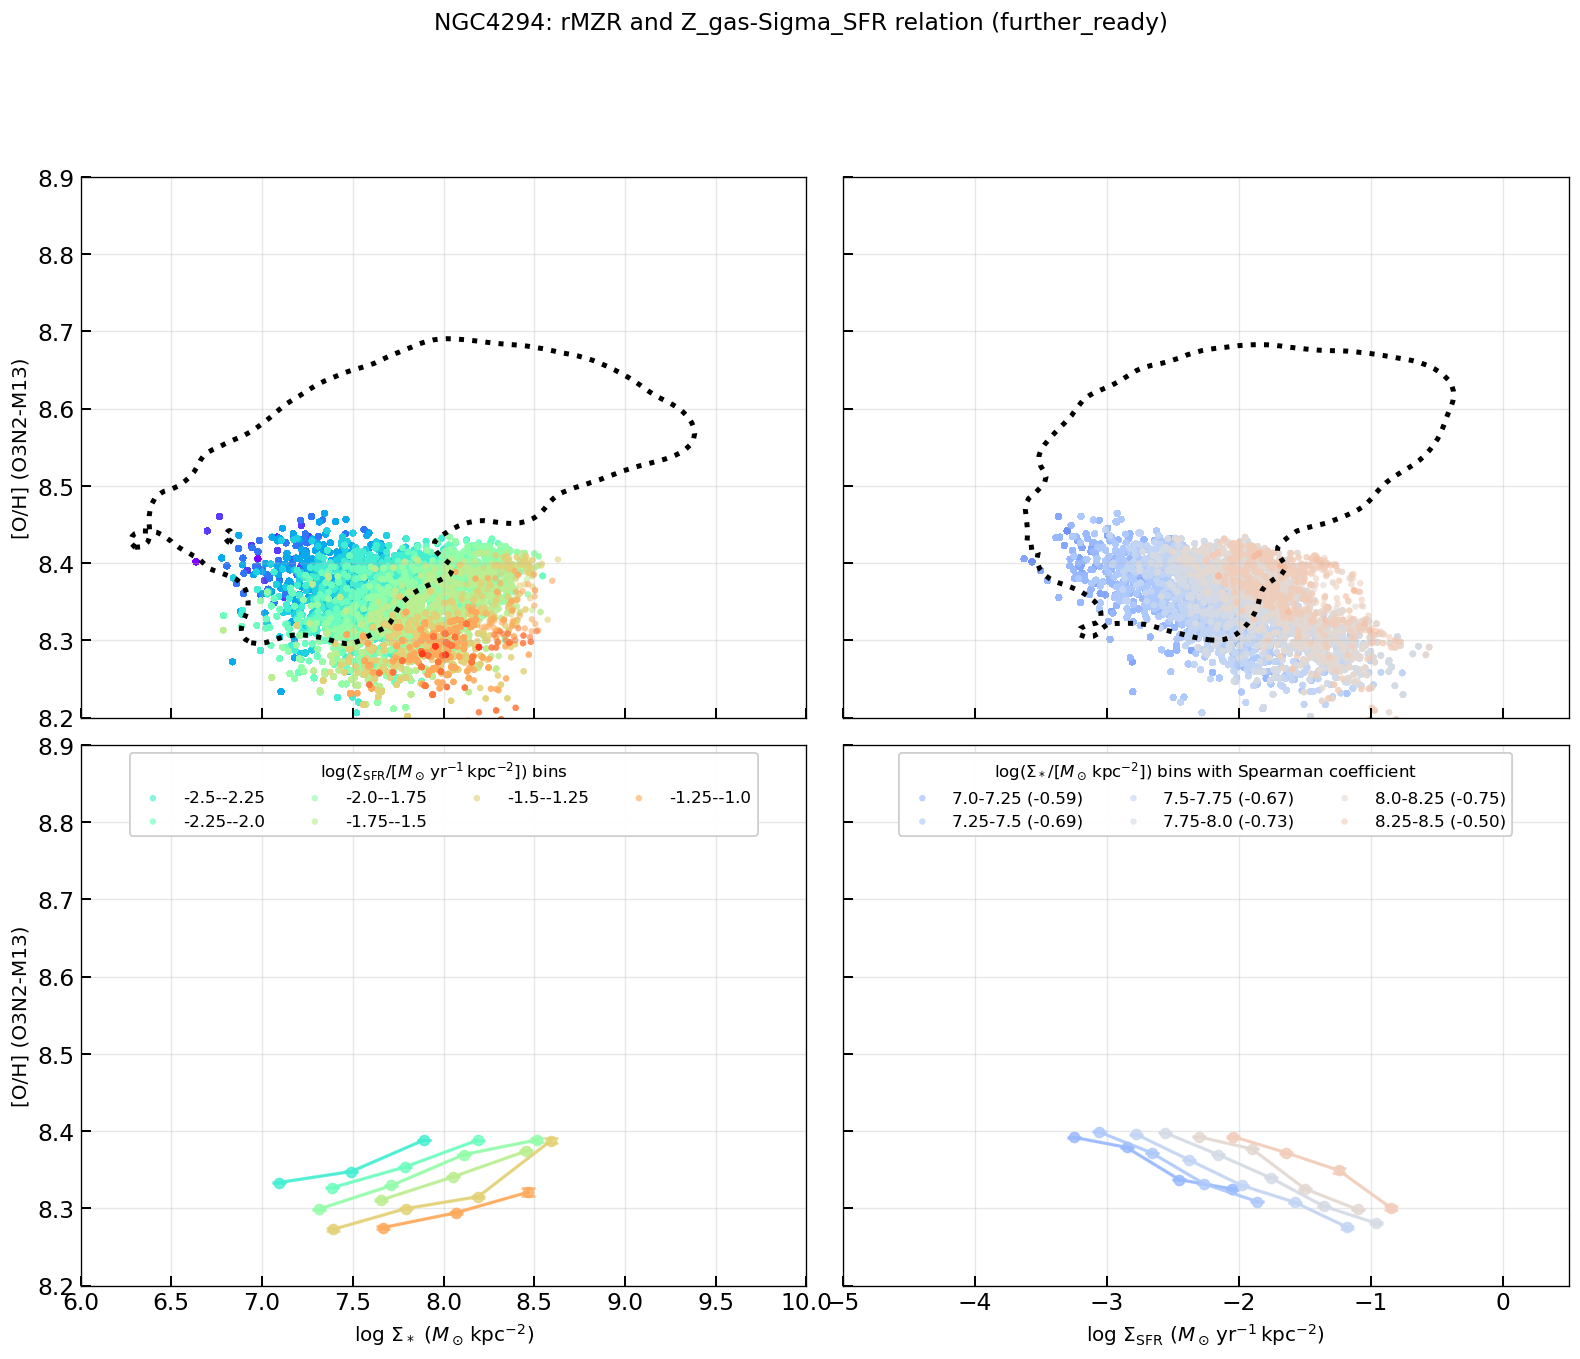

NGC4294: rMZR valid bins=6; Z_gas-Sigma_SFR valid bins=6
NGC4298: source=further_ready; valid HII pixels after EW/sigma mask=103876


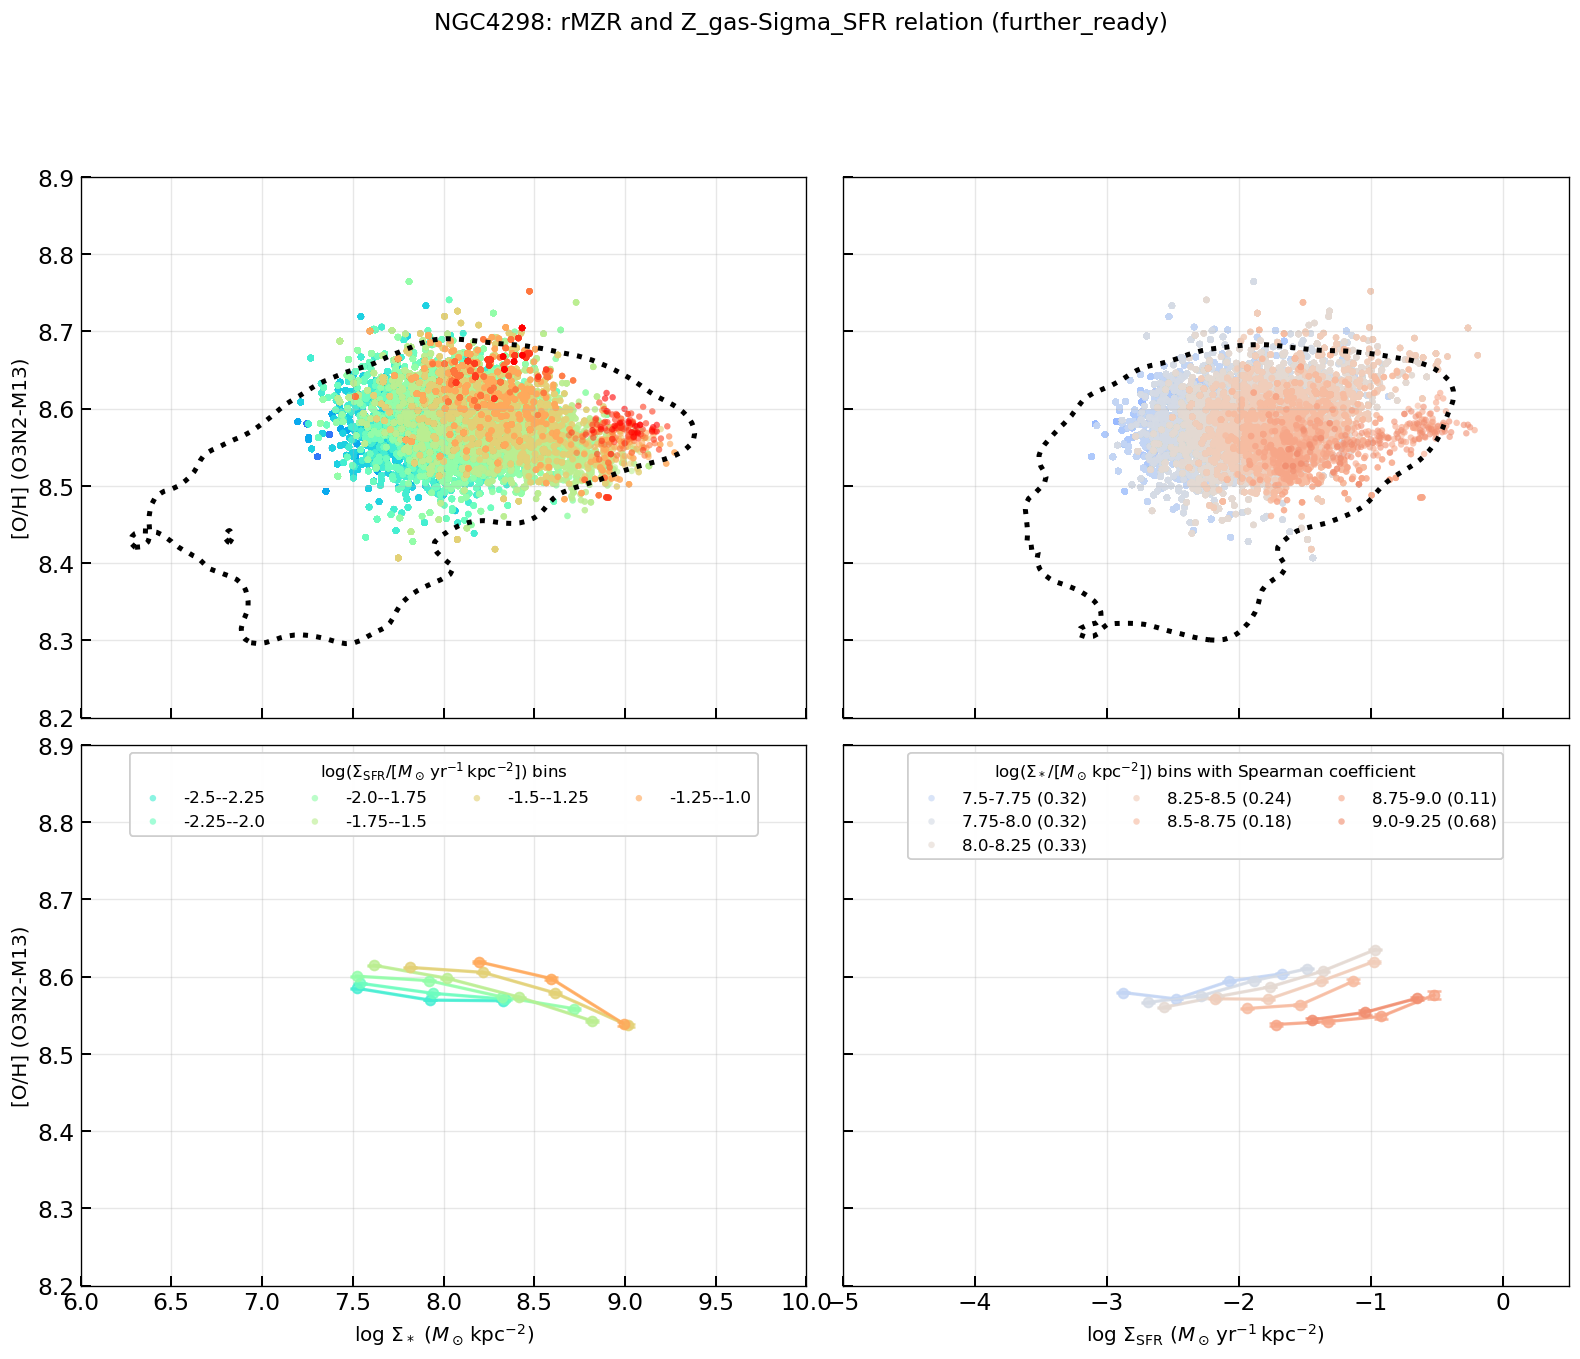

NGC4298: rMZR valid bins=6; Z_gas-Sigma_SFR valid bins=7


In [10]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Source notebook one-based cell 17, looped over FOCUS_GALAXIES only.
    # Each figure keeps the same 2x2 rMZR / Z_gas-Sigma_SFR layout.
    # Pooled black contours use all available ready galaxies; plotted figures use FOCUS_GALAXIES.
    # ------------------------------------------------------------------
    import numpy as np
    import matplotlib.pyplot as plt
    from pathlib import Path
    from astropy.io import fits
    import scipy.stats as stats
    import scipy.ndimage as ndimage

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    def load_maps_o3n2_m13_for_cell17(gal):
        """Load HII Sigma_*, Sigma_SFR, and O3N2-M13 maps with the source-cell EW/sigma mask."""
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)
        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
        with fits.open(gas_path) as h_gas:
            sigSFR_HII = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            if 'HA6562_SIGMA_CORR' not in h_gas:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            ha_sigma_corr = align_map_to_shape(
                h_gas['HA6562_SIGMA_CORR'].data,
                ha_sigma_obs.shape,
                label=f'{gal} HA6562_SIGMA_CORR',
            )
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            oh_o3n2_m13_HII = np.asarray(h_gas['O_H_O3N2_M13_HII'].data, dtype=float)
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f'Missing {EW_HDU} in {ew_path}')
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(ew_ha, sigSFR_HII.shape, label=f'{gal} {EW_HDU}')
        sigM = align_map_to_shape(sigM, sigSFR_HII.shape, label=f'{gal} LOGMASS_SURFACE_DENSITY')
        oh_o3n2_m13_HII = align_map_to_shape(oh_o3n2_m13_HII, sigSFR_HII.shape, label=f'{gal} O_H_O3N2_M13_HII')
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR_HII = np.where(ew_mask, sigSFR_HII, np.nan)
        oh_o3n2_m13_HII = np.where(ew_mask, oh_o3n2_m13_HII, np.nan)
        return sigM, sigSFR_HII, oh_o3n2_m13_HII

    def calculate_binned_stats_cell17(x_data, y_data, bin_width=0.4, min_pixels=20):
        x_data = np.asarray(x_data, dtype=float)
        y_data = np.asarray(y_data, dtype=float)
        finite = np.isfinite(x_data) & np.isfinite(y_data)
        if not np.any(finite):
            empty = np.array([])
            return empty, empty, empty, empty, empty
        x_min, x_max = np.nanmin(x_data[finite]), np.nanmax(x_data[finite])
        if not np.isfinite(x_min) or not np.isfinite(x_max) or x_min == x_max:
            empty = np.array([])
            return empty, empty, empty, empty, empty
        bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
        if bin_edges.size < 2:
            empty = np.array([])
            return empty, empty, empty, empty, empty
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
        medians, stds, counts, valid_centers, valid_bin_indices = [], [], [], [], []
        for i, (bin_start, bin_end) in enumerate(zip(bin_edges[:-1], bin_edges[1:])):
            in_bin = finite & (x_data >= bin_start) & (x_data < bin_end)
            y_in_bin = y_data[in_bin]
            if len(np.unique(y_in_bin)) >= min_pixels:
                medians.append(np.nanmedian(y_in_bin))
                stds.append(np.nanstd(y_in_bin))
                counts.append(len(y_in_bin))
                valid_centers.append(bin_centers[i])
                valid_bin_indices.append(i)
        return (
            np.asarray(valid_centers),
            np.asarray(medians),
            np.asarray(stds),
            np.asarray(counts),
            np.asarray(valid_bin_indices),
        )

    def compute_density_mask_cell17(x_vals, y_vals, x_range, y_range, nbins=100, sigma=2.0, return_contour=False):
        x_vals = np.asarray(x_vals, dtype=float)
        y_vals = np.asarray(y_vals, dtype=float)
        mask_finite = np.isfinite(x_vals) & np.isfinite(y_vals)
        empty_mask = np.zeros_like(x_vals, dtype=bool)
        if np.sum(mask_finite) < 3:
            return (empty_mask, None, None) if return_contour else empty_mask
        x = x_vals[mask_finite]
        y = y_vals[mask_finite]
        H, xedges, yedges = np.histogram2d(x, y, bins=nbins, range=[x_range, y_range])
        if not np.any(H > 0):
            return (empty_mask, None, None) if return_contour else empty_mask
        H_smooth = ndimage.gaussian_filter(H, sigma=sigma)
        H_flat = np.sort(H_smooth.ravel())[::-1]
        H_cumsum = np.cumsum(H_flat)
        if H_cumsum.size == 0 or H_cumsum[-1] <= 0:
            return (empty_mask, None, None) if return_contour else empty_mask
        level_idx = min(np.searchsorted(H_cumsum, 0.95 * H_cumsum[-1]), H_flat.size - 1)
        level_95 = H_flat[level_idx]
        x_centers = (xedges[:-1] + xedges[1:]) / 2
        y_centers = (yedges[:-1] + yedges[1:]) / 2
        X, Y = np.meshgrid(x_centers, y_centers)
        dx = (x_range[1] - x_range[0]) / nbins
        dy = (y_range[1] - y_range[0]) / nbins
        x_idx = (x - x_range[0]) / dx - 0.5
        y_idx = (y - y_range[0]) / dy - 0.5
        densities = ndimage.map_coordinates(H_smooth, [x_idx, y_idx], order=1, mode='constant', cval=0.0)
        mask_local = densities >= level_95
        full_mask = np.zeros_like(x_vals, dtype=bool)
        full_mask[np.where(mask_finite)[0]] = mask_local
        if return_contour:
            return full_mask, level_95, (X, Y, H_smooth)
        return full_mask

    CELL17_COMMON_YLIM = (8.2, 8.9)
    CELL17_X_RANGE_RMZR = (6.0, 10.0)
    CELL17_X_RANGE_ZGAS = (-5.0, 0.5)
    CELL17_GALAXY_MAP_CACHE = {}

    def get_cell17_maps(gal):
        if gal not in CELL17_GALAXY_MAP_CACHE:
            CELL17_GALAXY_MAP_CACHE[gal] = load_maps_o3n2_m13_for_cell17(gal)
        return CELL17_GALAXY_MAP_CACHE[gal]

    def collect_cell17_global_contours(galaxies):
        global_logSigmaM = []
        global_logSigmaSFR = []
        global_oh = []
        global_counts = {}
        skipped = {}

        for gal in galaxies:
            try:
                logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = get_cell17_maps(gal)
                common_mask_HII = (
                    np.isfinite(logSigmaM)
                    & np.isfinite(logSigmaSFR_HII)
                    & np.isfinite(oh_o3n2_m13_HII)
                )
                n_valid = int(np.sum(common_mask_HII))
                global_counts[gal] = n_valid
                if n_valid <= 0:
                    continue
                global_logSigmaM.append(logSigmaM[common_mask_HII].ravel())
                global_logSigmaSFR.append(logSigmaSFR_HII[common_mask_HII].ravel())
                global_oh.append(oh_o3n2_m13_HII[common_mask_HII].ravel())
            except Exception as exc:
                skipped[gal] = str(exc)

        if global_logSigmaM:
            all_logSigmaM = np.concatenate(global_logSigmaM)
            all_logSigmaSFR = np.concatenate(global_logSigmaSFR)
            all_oh = np.concatenate(global_oh)
        else:
            all_logSigmaM = np.array([])
            all_logSigmaSFR = np.array([])
            all_oh = np.array([])

        _, rMZR_level, rMZR_contour = compute_density_mask_cell17(
            all_logSigmaM,
            all_oh,
            CELL17_X_RANGE_RMZR,
            CELL17_COMMON_YLIM,
            return_contour=True,
        )
        _, zgas_level, zgas_contour = compute_density_mask_cell17(
            all_logSigmaSFR,
            all_oh,
            CELL17_X_RANGE_ZGAS,
            CELL17_COMMON_YLIM,
            return_contour=True,
        )
        print(
            f'All-galaxy 95% contours use {len(global_counts)} galaxies '
            f'and {len(all_oh)} valid HII pixels after EW/sigma mask.'
        )
        if skipped:
            print('Skipped while building all-galaxy contours:', skipped)
        return {
            'rMZR': (rMZR_level, rMZR_contour),
            'zgas': (zgas_level, zgas_contour),
            'counts': global_counts,
            'skipped': skipped,
        }

    def plot_cell17_for_one_galaxy(gal):
        source_label = PRODUCTS.loc[gal, 'source'] if gal in PRODUCTS.index else 'unknown'
        try:
            logSigmaM, logSigmaSFR_HII, oh_o3n2_m13_HII = get_cell17_maps(gal)
        except Exception as exc:
            print(f'{gal}: skipped ({exc})')
            return None

        common_mask_HII = np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & np.isfinite(oh_o3n2_m13_HII)
        n_valid = int(np.sum(common_mask_HII))
        if n_valid < 10:
            print(f'{gal}: skipped (only {n_valid} valid HII pixels after EW/sigma mask)')
            return None

        x_mass = logSigmaM[common_mask_HII].ravel()
        x_sfr = logSigmaSFR_HII[common_mask_HII].ravel()
        y_oh = oh_o3n2_m13_HII[common_mask_HII].ravel()

        n_bins = 14
        sfr_bin_edges = [-np.inf, -3.5, -3.25, -3.0, -2.75, -2.5, -2.25, -2.0, -1.75, -1.5, -1.25, -1.0, -0.75, -0.5, np.inf]
        bin_labels = ['<-3.5', '-3.5--3.25', '-3.25--3.0', '-3.0--2.75', '-2.75--2.5', '-2.5--2.25',
                      '-2.25--2.0', '-2.0--1.75', '-1.75--1.5', '-1.5--1.25', '-1.25--1.0', '-1.0--0.75', '-0.75--0.5', '>-0.5']
        colors_sfr = plt.cm.rainbow(np.linspace(0, 1, n_bins))

        n_bins_sigmaM = 14
        sigmaM_bin_edges = [-np.inf, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, np.inf]
        bin_labels_sigmaM = ['<6.5', '6.5-6.75', '6.75-7.0', '7.0-7.25', '7.25-7.5', '7.5-7.75',
                              '7.75-8.0', '8.0-8.25', '8.25-8.5', '8.5-8.75', '8.75-9.0', '9.0-9.25', '9.25-9.5', '>9.5']
        colors_sigmaM = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins_sigmaM))

        common_ylim = CELL17_COMMON_YLIM
        x_range_rMZR = CELL17_X_RANGE_RMZR
        x_range_Zgas = CELL17_X_RANGE_ZGAS

        print('=' * 80)
        print(f'{gal}: source={source_label}; valid HII pixels after EW/sigma mask={n_valid}')
        print('=' * 80)

        fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex='col', sharey='all')
        plt.subplots_adjust(wspace=0.05, hspace=0.05)
        ax_rMZR_scatter, ax_Zgas_scatter = axes[0, 0], axes[0, 1]
        ax_rMZR_median, ax_Zgas_median = axes[1, 0], axes[1, 1]

        global_rMZR_level, global_rMZR_contour = CELL17_GLOBAL_CONTOURS['rMZR']
        global_zgas_level, global_zgas_contour = CELL17_GLOBAL_CONTOURS['zgas']

        legend_handles_sfr, legend_labels_sfr = [], []
        valid_bins_rMZR = 0
        for i in range(n_bins):
            in_bin = (x_sfr >= sfr_bin_edges[i]) & (x_sfr < sfr_bin_edges[i + 1])
            if np.sum(in_bin) < 10:
                continue
            x_bin_all = x_mass[in_bin]
            y_bin_all = y_oh[in_bin]
            scatter_hii = ax_rMZR_scatter.scatter(
                x_bin_all, y_bin_all, c=[colors_sfr[i]], s=15, alpha=0.6,
                edgecolors='none', rasterized=True,
            )
            mask_95_bin = compute_density_mask_cell17(x_bin_all, y_bin_all, x_range_rMZR, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            if len(x_bin) < 10:
                continue
            mass_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats_cell17(
                x_bin, y_bin, bin_width=0.4, min_pixels=20
            )
            if len(mass_centers) < 3:
                continue
            legend_handles_sfr.append(scatter_hii)
            legend_labels_sfr.append(bin_labels[i])
            yerr = stds / np.sqrt(counts)
            ax_rMZR_median.errorbar(
                mass_centers, medians, yerr=yerr, color=colors_sfr[i], marker='o',
                markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8,
            )
            for j in range(len(valid_bin_indices) - 1):
                if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                    ax_rMZR_median.plot(
                        [mass_centers[j], mass_centers[j + 1]],
                        [medians[j], medians[j + 1]],
                        color=colors_sfr[i], linewidth=2, alpha=0.8,
                    )
            valid_bins_rMZR += 1

        if global_rMZR_contour is not None and global_rMZR_level is not None:
            ax_rMZR_scatter.contour(
                global_rMZR_contour[0], global_rMZR_contour[1], global_rMZR_contour[2].T,
                levels=[global_rMZR_level], colors='k', linewidths=3, linestyles=':',
            )
        ax_rMZR_scatter.set_ylabel('[O/H] (O3N2-M13)', fontsize=12)
        ax_rMZR_scatter.grid(True, alpha=0.3)
        ax_rMZR_scatter.set_xlim(*x_range_rMZR)
        ax_rMZR_scatter.set_ylim(common_ylim)
        ax_rMZR_median.set_xlabel(r'$\log\,\Sigma_* \ (M_\odot\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_rMZR_median.set_ylabel('[O/H] (O3N2-M13)', fontsize=12)
        ax_rMZR_median.grid(True, alpha=0.3)
        ax_rMZR_median.set_xlim(*x_range_rMZR)
        ax_rMZR_median.set_ylim(common_ylim)
        if legend_handles_sfr:
            legend1 = ax_rMZR_median.legend(
                legend_handles_sfr, legend_labels_sfr, loc='upper center', ncol=4,
                fontsize=10, framealpha=0.9,
                title=r'$\log(\Sigma_\mathrm{SFR}/[M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2}])$ bins',
                title_fontsize=10,
            )
            ax_rMZR_median.add_artist(legend1)

        legend_handles_sigmaM, legend_labels_sigmaM_display = [], []
        valid_bins_Zgas = 0
        for i in range(n_bins_sigmaM):
            in_bin = (x_mass >= sigmaM_bin_edges[i]) & (x_mass < sigmaM_bin_edges[i + 1])
            if np.sum(in_bin) < 10:
                continue
            x_bin_all = x_sfr[in_bin]
            y_bin_all = y_oh[in_bin]
            scatter_hii = ax_Zgas_scatter.scatter(
                x_bin_all, y_bin_all, c=[colors_sigmaM[i]], s=15, alpha=0.6,
                edgecolors='none', rasterized=True,
            )
            mask_95_bin = compute_density_mask_cell17(x_bin_all, y_bin_all, x_range_Zgas, common_ylim)
            x_bin = x_bin_all[mask_95_bin]
            y_bin = y_bin_all[mask_95_bin]
            spearman_text = 'N/A'
            if len(x_bin) > 1:
                y_mean, y_std = np.nanmean(y_bin), np.nanstd(y_bin)
                x_mean, x_std = np.nanmean(x_bin), np.nanstd(x_bin)
                mask_clip = (np.abs(y_bin - y_mean) < 3 * y_std) & (np.abs(x_bin - x_mean) < 3 * x_std)
                x_clipped = x_bin[mask_clip]
                y_clipped = y_bin[mask_clip]
                sfr_centers, medians, stds, counts, valid_bin_indices = calculate_binned_stats_cell17(
                    x_clipped, y_clipped, bin_width=0.4, min_pixels=20
                )
                if len(sfr_centers) >= 3:
                    if len(x_clipped) > 10:
                        corr, _ = stats.spearmanr(x_clipped, y_clipped)
                        spearman_text = f'{corr:.2f}'
                    legend_handles_sigmaM.append(scatter_hii)
                    legend_labels_sigmaM_display.append(f'{bin_labels_sigmaM[i]} ({spearman_text})')
                    yerr = stds / np.sqrt(counts)
                    ax_Zgas_median.errorbar(
                        sfr_centers, medians, yerr=yerr, color=colors_sigmaM[i], marker='o',
                        markersize=6, linewidth=1, capsize=4, capthick=1.5, alpha=0.8,
                    )
                    for j in range(len(valid_bin_indices) - 1):
                        if valid_bin_indices[j + 1] - valid_bin_indices[j] == 1:
                            ax_Zgas_median.plot(
                                [sfr_centers[j], sfr_centers[j + 1]],
                                [medians[j], medians[j + 1]],
                                color=colors_sigmaM[i], linewidth=2, alpha=0.8,
                            )
                    valid_bins_Zgas += 1

        if global_zgas_contour is not None and global_zgas_level is not None:
            ax_Zgas_scatter.contour(
                global_zgas_contour[0], global_zgas_contour[1], global_zgas_contour[2].T,
                levels=[global_zgas_level], colors='k', linewidths=3, linestyles=':',
            )
        ax_Zgas_scatter.grid(True, alpha=0.3)
        ax_Zgas_scatter.set_xlim(*x_range_Zgas)
        ax_Zgas_scatter.set_ylim(common_ylim)
        ax_Zgas_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \ (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_Zgas_median.grid(True, alpha=0.3)
        ax_Zgas_median.set_xlim(*x_range_Zgas)
        ax_Zgas_median.set_ylim(common_ylim)
        if legend_handles_sigmaM:
            legend2 = ax_Zgas_median.legend(
                legend_handles_sigmaM, legend_labels_sigmaM_display, loc='upper center', ncol=3,
                fontsize=10, framealpha=0.9,
                title=r'$\log(\Sigma_*/[M_\odot\,\mathrm{kpc}^{-2}])$ bins with Spearman coefficient',
                title_fontsize=10,
            )
            ax_Zgas_median.add_artist(legend2)

        fig.suptitle(f'{gal}: rMZR and Z_gas-Sigma_SFR relation ({source_label})', fontsize=14, y=0.995)
        # fig.savefig(OUTDIR / f'{gal}_source_cell17_individual_OH_SFR.png', dpi=300, bbox_inches='tight')
        # fig.savefig(OUTDIR / f'{gal}_source_cell17_individual_OH_SFR.pdf', bbox_inches='tight')
        plt.show()
        plt.close(fig)
        print(f'{gal}: rMZR valid bins={valid_bins_rMZR}; Z_gas-Sigma_SFR valid bins={valid_bins_Zgas}')
        return fig

    CELL17_ALL_GALAXIES_FOR_CONTOURS = ordered_galaxies_by_fixed_palette(physics_ready_galaxies(require_ew=True))
    PER_GALAXY_CELL17_GALAXIES = [
        gal for gal in FOCUS_GALAXIES
        if gal in physics_ready_galaxies(require_ew=True)
    ]
    missing_focus = [gal for gal in FOCUS_GALAXIES if gal not in PER_GALAXY_CELL17_GALAXIES]
    if missing_focus:
        print('Focus galaxies skipped because products are not science-ready with EW maps:', ', '.join(missing_focus))
    print(f'Building source cell 17 all-galaxy contours from {len(CELL17_ALL_GALAXIES_FOR_CONTOURS)} mixed-source galaxies:')
    print(', '.join(CELL17_ALL_GALAXIES_FOR_CONTOURS))
    print(f'Looping source cell 17 per galaxy for {len(PER_GALAXY_CELL17_GALAXIES)} focus galaxies:')
    print(', '.join(PER_GALAXY_CELL17_GALAXIES) if PER_GALAXY_CELL17_GALAXIES else 'none')
    CELL17_GLOBAL_CONTOURS = collect_cell17_global_contours(CELL17_ALL_GALAXIES_FOR_CONTOURS)
    for galaxy in PER_GALAXY_CELL17_GALAXIES:
        plot_cell17_for_one_galaxy(galaxy)
else:
    print('Skipped focused per-galaxy source-cell-17 loop: no mixed-source mass/SFR/OH+EW products are ready yet.')

## Focused 2x2 Maps for NGC4294 and NGC4298

The next cell follows the 2x2 map layout from cell 31 of `20260604_initial_check_rMZR.ipynb`: top panels show Delta SFR and Delta O/H, bottom-left shows the local bivariate Moran-like statistic, and bottom-right shows the binned stellar-mass map.


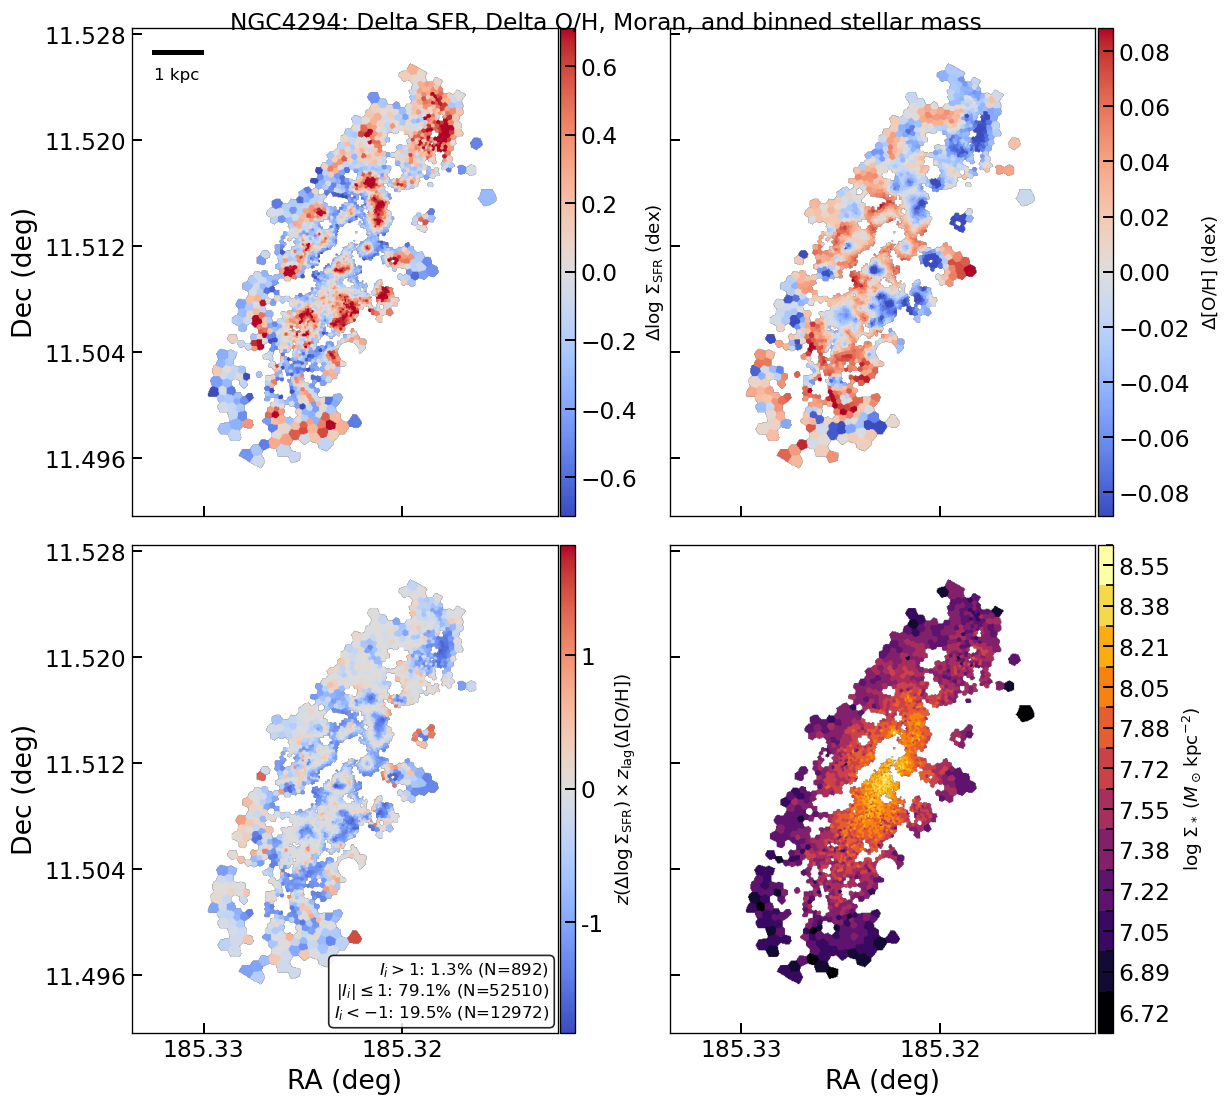

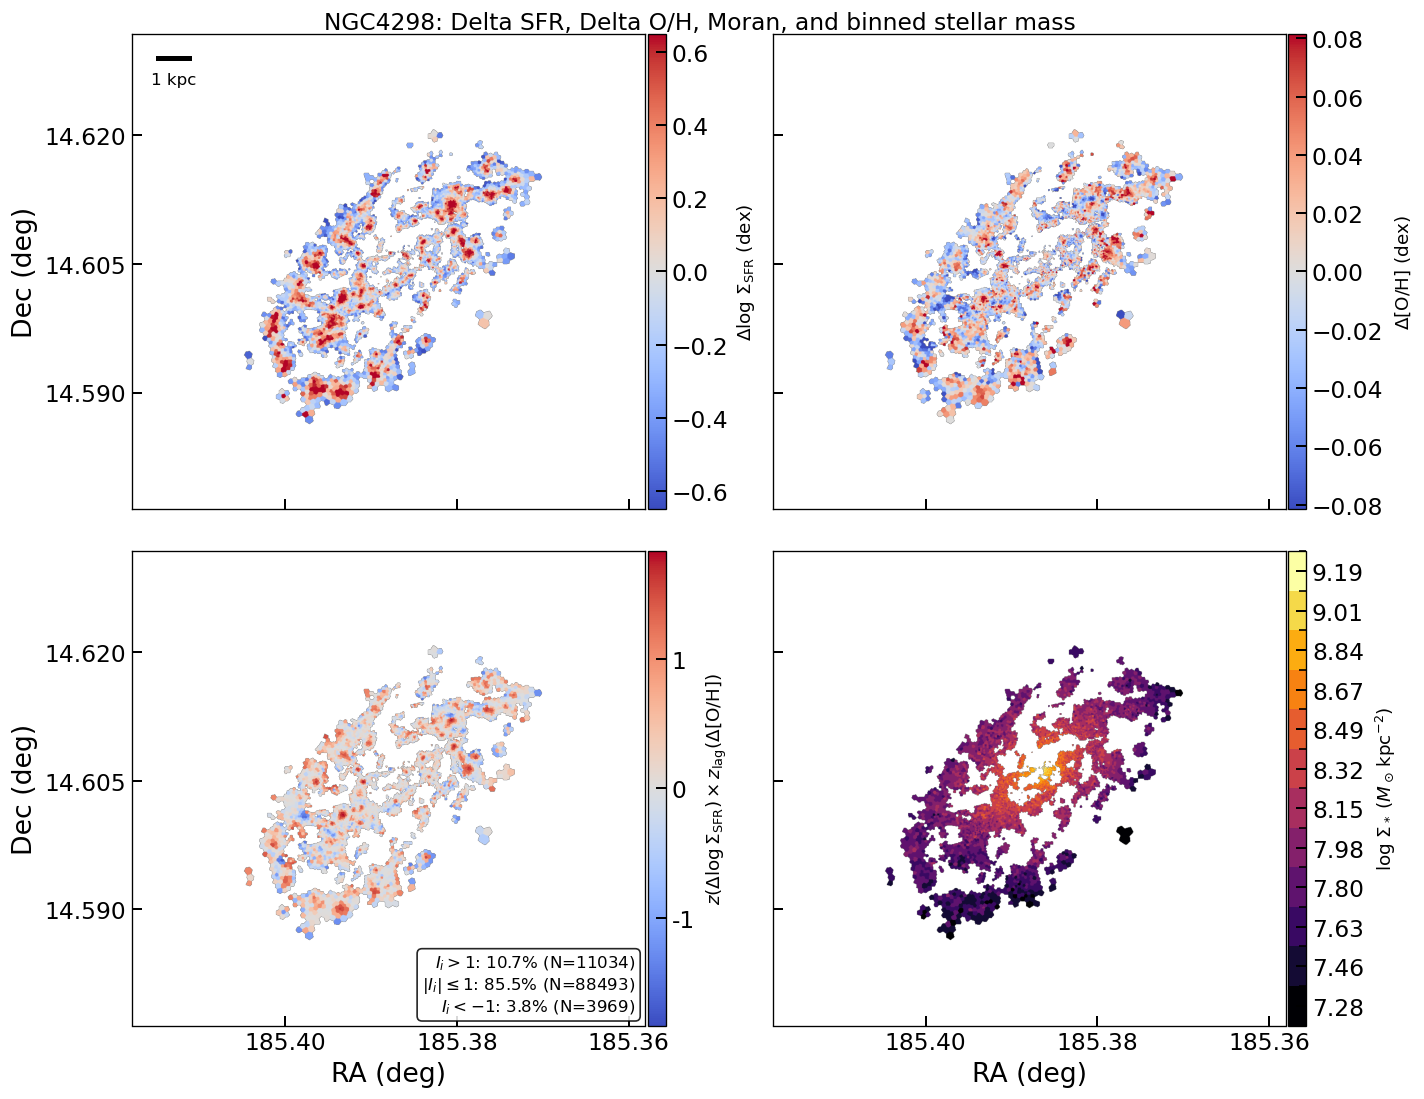

In [11]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Focused 2x2 map figures: offset maps + Moran-like map + binned Σ* map
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    from astropy.wcs import WCS
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gs_module
    from matplotlib.colors import BoundaryNorm, SymLogNorm
    import matplotlib.ticker as mticker
    from matplotlib.ticker import ScalarFormatter

    # Only focus on the two requested galaxies for this visualisation.
    galaxies = [gal for gal in FOCUS_GALAXIES if gal in physics_ready_galaxies(require_ew=True)]
    missing_focus = [gal for gal in FOCUS_GALAXIES if gal not in galaxies]
    if missing_focus:
        print('Skipped focus galaxies because nested *_further mass/SFR/OH+EW products are not ready:', ', '.join(missing_focus))

    # ------------------------------------------------------------------
    # Define threshold parameter for linear/log colorbar transition and classification
    # ------------------------------------------------------------------
    threshold = 1  # Values between -threshold and +threshold use linear scale

    # ------------------------------------------------------------------
    # 1.  Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
            binid_map = np.asarray(h_spatial['BINID'].data, dtype=float)
            wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
        with fits.open(gas_path) as h_gas:
            sigSFR = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            ha_sigma_corr = np.asarray(h_gas['HA6562_SIGMA_CORR'].data, dtype=float) if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            ha_sigma_corr = align_map_to_shape(ha_sigma_corr, ha_sigma_obs.shape, label=f'{gal} HA6562_SIGMA_CORR')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = np.asarray(h_gas['O_H_O3N2_M14_HII'].data, dtype=float)
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = np.asarray(h_gas['O_H_O3N2_M13_HII'].data, dtype=float)
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
            gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        sigM = align_map_to_shape(sigM, sigSFR.shape, label=f"{gal} LOGMASS_SURFACE_DENSITY")
        binid_map = align_map_to_shape(binid_map, sigSFR.shape, label=f"{gal} BINID")
        oh_map = align_map_to_shape(oh_map, sigSFR.shape, label=f"{gal} {indicator_name}")
        ha_sigma = align_map_to_shape(ha_sigma, sigSFR.shape, label=f"{gal} intrinsic HA6562_SIGMA")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, ha_sigma, indicator_name, wcs, gas_header, binid_map

    for gal in galaxies:
        sigM, sigSFR, oh_o3n2_map, ha_sigma, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        # ------------------------------------------------------------------
        # 2.  Calculate offset maps (relative to Σ* bin means)
        # ------------------------------------------------------------------
        # Define 12 Σ* bins
        n_bins = 12
        sigmaM_min = np.nanmin(sigM[valid_all])
        sigmaM_max = np.nanmax(sigM[valid_all])
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
        # Initialize offset maps
        sfr_offset = np.full_like(sigSFR, np.nan)
        oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
        # Calculate offset for each Σ* bin
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            if np.sum(bin_mask) > 0:
                # Calculate bin mean and offset within this bin
                sfr_bin_mean = np.mean(sigSFR[bin_mask])
                oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
                sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
                oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
        sfr_offset_max = np.nanpercentile(np.abs(sfr_offset[valid_all]), 95)
        # Reduce Delta O/H range to 95th percentile to highlight differences
        oh_offset_max = np.nanpercentile(np.abs(oh_offset[valid_all]), 95)
    

        # ------------------------------------------------------------------
        # 3.  Calculate local bivariate Moran-like map
        # ------------------------------------------------------------------
        def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
            """Local bivariate Moran-style statistic on adjacent spatial bins.

            Each valid BINID is treated as one graph node, using the mean A and B value
            of that bin. The resulting per-bin Moran value is expanded back to all
            valid pixels in the bin for plotting.
            """
            A = np.asarray(A, dtype=float)
            B = np.asarray(B, dtype=float)
            valid_mask = np.asarray(valid_mask, dtype=bool)
            binid_raw = np.asarray(binid_map, dtype=float)
            if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
                raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

            I_map = np.full(A.shape, np.nan)
            quad_map = np.zeros(A.shape, dtype=np.int16)
            finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
            binid = np.full(A.shape, -1, dtype=np.int64)
            binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
            valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
            valid_bins = np.unique(binid[valid])
            if valid_bins.size < 2:
                return I_map, quad_map

            max_bin = int(valid_bins.max())
            flat_bins = binid[valid].ravel()
            counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
            sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
            sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
            A_bin = np.full(max_bin + 1, np.nan)
            B_bin = np.full(max_bin + 1, np.nan)
            has_data = counts > 0
            A_bin[has_data] = sum_A[has_data] / counts[has_data]
            B_bin[has_data] = sum_B[has_data] / counts[has_data]

            A_vals = A_bin[valid_bins]
            B_vals = B_bin[valid_bins]
            A_std = np.nanstd(A_vals)
            B_std = np.nanstd(B_vals)
            if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
                return I_map, quad_map

            Az = np.full(max_bin + 1, np.nan)
            Bz = np.full(max_bin + 1, np.nan)
            Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
            Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

            offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
            if neighbourhood == 'queen':
                offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
            elif neighbourhood != 'rook':
                raise ValueError("neighbourhood must be 'rook' or 'queen'")

            adjacency = {int(b): set() for b in valid_bins}
            rows, cols = A.shape
            for dy, dx in offsets:
                y0 = max(0, -dy)
                y1 = rows - max(0, dy)
                x0 = max(0, -dx)
                x1 = cols - max(0, dx)
                src = (slice(y0, y1), slice(x0, x1))
                dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
                pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
                for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                    left = int(left)
                    right = int(right)
                    adjacency[left].add(right)
                    adjacency[right].add(left)

            for b in valid_bins:
                b = int(b)
                neigh = sorted(adjacency[b])
                if not neigh:
                    continue
                lag_B = np.nanmean(Bz[neigh])
                I_val = Az[b] * lag_B
                pixels = valid & (binid == b)
                I_map[pixels] = I_val
                if Az[b] >= 0 and lag_B >= 0:
                    quad_map[pixels] = 1
                elif Az[b] < 0 and lag_B < 0:
                    quad_map[pixels] = 2
                elif Az[b] >= 0 and lag_B < 0:
                    quad_map[pixels] = 3
                else:
                    quad_map[pixels] = 4

            return I_map, quad_map
        I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                                neighbourhood='queen')

        # ------------------------------------------------------------------
        # Calculate statistics for three classes based on threshold
        # ------------------------------------------------------------------
        valid_I = np.isfinite(I_map)
        n_total = np.sum(valid_I)
        n_high = np.sum(I_map[valid_I] > threshold)
        n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
        n_low = np.sum(I_map[valid_I] < -threshold)
        pct_high = (n_high / n_total * 100) if n_total > 0 else 0
        pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
        pct_low = (n_low / n_total * 100) if n_total > 0 else 0

        # ------------------------------------------------------------------
        # 4.  Create binned Σ* map
        # ------------------------------------------------------------------
        sigM_binned_map = np.full_like(sigM, np.nan)
    
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            # Assign bin center value
            bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
            sigM_binned_map[bin_mask] = bin_center

        # ------------------------------------------------------------------
        # 5.  Prepare coordinate extent
        # ------------------------------------------------------------------
        wcs_celestial = WCS(gas_header).celestial
        y_size, x_size = sigSFR.shape
        x_coords = np.arange(x_size)
        y_coords = np.arange(y_size)
        xx, yy = np.meshgrid(x_coords, y_coords)
        ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
        extent = [ra.max(), ra.min(), dec.min(), dec.max()]

        # ------------------------------------------------------------------
        # 5b.  Scale bar: 5 kpc for 0.2 arcsec/pixel at 16.5 Mpc
        # ------------------------------------------------------------------
        pix_scale_arcsec = 0.2
        distance_mpc = 16.5
        # calculate degrees for 5 kpc, including cos(dec) for the RA axis
        kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
        scalebar_kpc = 1
        scalebar_length_deg = (scalebar_kpc * kpc_arcsec) / 3600.0
        mean_dec = np.nanmean(dec)
        scalebar_length_deg_ra = scalebar_length_deg / np.cos(np.deg2rad(mean_dec))

        def add_scalebar(ax, length_deg, label='1 kpc'):
            x0, x1 = ax.get_xlim()
            x_range = abs(x1 - x0)
            if x_range == 0:
                return
            frac_len = length_deg / x_range
            x_start = 0.05
            y_start = 0.95
            x_end = x_start + frac_len
            line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                            color='k', lw=3, clip_on=False)
            line.set_in_layout(False)
            txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                          transform=ax.transAxes, ha='center', va='top', color='k')
            txt.set_in_layout(False)

        # ------------------------------------------------------------------
        # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
        # ------------------------------------------------------------------
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        # Auto-derive a reasonable figsize from the map extent
        dx = abs(extent[1] - extent[0])   # RA span
        dy = abs(extent[3] - extent[2])   # Dec span
        data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

        panel_h = 4.2   # inches per panel height (tune once)
        panel_w = panel_h * data_ratio
        cbar_w = 0.35   # inches per colorbar (tune once)

        W = 2 * panel_w + 2 * cbar_w + 1.2
        H = 2 * panel_h + 0.8

        fig, axs = plt.subplots(
            2, 2, figsize=(W, H), sharex=True, sharey=True
        )

        # Make space for the appended colorbars (right margin matters)
        fig.subplots_adjust(
            left=0.07, right=0.96, bottom=0.07, top=0.98,
            wspace=0.20, hspace=0.06
        )

        ax1, ax2 = axs[0, 0], axs[0, 1]
        ax3, ax4 = axs[1, 0], axs[1, 1]

        def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size=size, pad=pad)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
            return cbar

        # --- Ticks / formatting (readable RA, no +1.834e2)
        for ax in (ax1, ax2, ax3, ax4):
            ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

        # Hide inner tick labels
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
        plt.setp(ax2.get_yticklabels(), visible=False)
        plt.setp(ax4.get_yticklabels(), visible=False)

        # Axis labels (outer only)
        ax3.set_xlabel("RA (deg)", fontsize=16)
        ax4.set_xlabel("RA (deg)", fontsize=16)
        ax1.set_ylabel("Dec (deg)", fontsize=16)
        ax3.set_ylabel("Dec (deg)", fontsize=16)

        # ---- Panel 1: SFR offset
        im_sfr = ax1.imshow(
            np.ma.masked_invalid(sfr_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
            aspect="equal"
        )
        add_scalebar(ax1, scalebar_length_deg_ra, label="1 kpc")
        add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

        # ---- Panel 2: OH offset
        im_oh = ax2.imshow(
            np.ma.masked_invalid(oh_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
            aspect="equal"
        )
        add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

        # ---- Panel 3: Moran-like
        vI = np.nanmax(np.abs(I_map))
        norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

        imI = ax3.imshow(
            np.ma.masked_invalid(I_map),
            origin="lower", cmap="coolwarm",
            extent=extent, norm=norm,
            aspect="equal"
        )
        cbarI = add_cbar(
            ax3, imI,
            r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
        )

        # Keep your symmetric-log ticks logic
        max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
        pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
        pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
        neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
        ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
        cbarI.set_ticks(ticks)
        cbarI.set_ticklabels([f"{t:g}" for t in ticks])

        legend_text = (
            rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
            '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
            '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
        )
        ax3.text(
            0.98, 0.02, legend_text, transform=ax3.transAxes,
            fontsize=10, va="bottom", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        # ---- Panel 4: binned Σ*
        cmap_discrete = plt.cm.inferno
        norm_discrete = BoundaryNorm(sigmaM_bin_edges, cmap_discrete.N)

        im_sigM_binned = ax4.imshow(
            np.ma.masked_invalid(sigM_binned_map),
            origin="lower", cmap=cmap_discrete, norm=norm_discrete,
            extent=extent,
            aspect="equal"
        )
        cbar_binned = add_cbar(
            ax4, im_sigM_binned,
            r'$\log\,\Sigma_*\;(M_\odot\,\mathrm{kpc}^{-2})$'
        )

        bin_centers = [(sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2 for i in range(n_bins)]
        cbar_binned.set_ticks(bin_centers)
        cbar_binned.set_ticklabels([f"{bc:.2f}" for bc in bin_centers])

        fig.suptitle(f'{gal}: Delta SFR, Delta O/H, Moran, and binned stellar mass', fontsize=14, y=0.995)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.pdf', bbox_inches="tight", pad_inches=0.02)
        plt.show()
else:
    print("Skipped focused 2x2 stellar-mass map cell: no nested *_further mass/SFR/OH+EW products are ready yet.")


## Focused 2x2 Maps With Intrinsic Halpha Dispersion

This repeats the focused 2x2 map layout, replacing the bottom-right binned stellar-mass map with intrinsic Halpha dispersion computed as `ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])`.


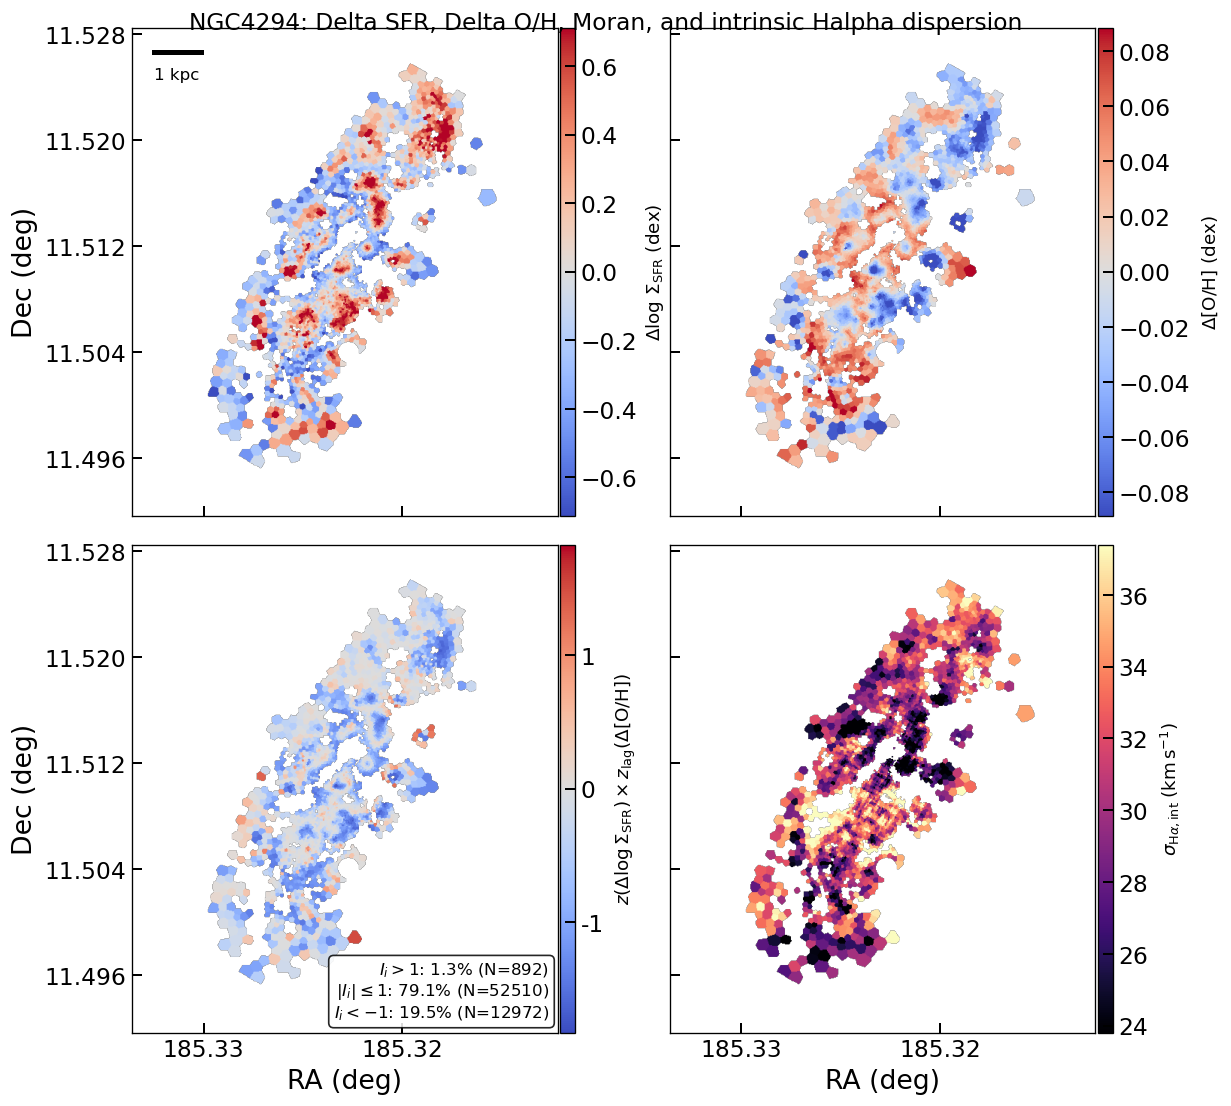

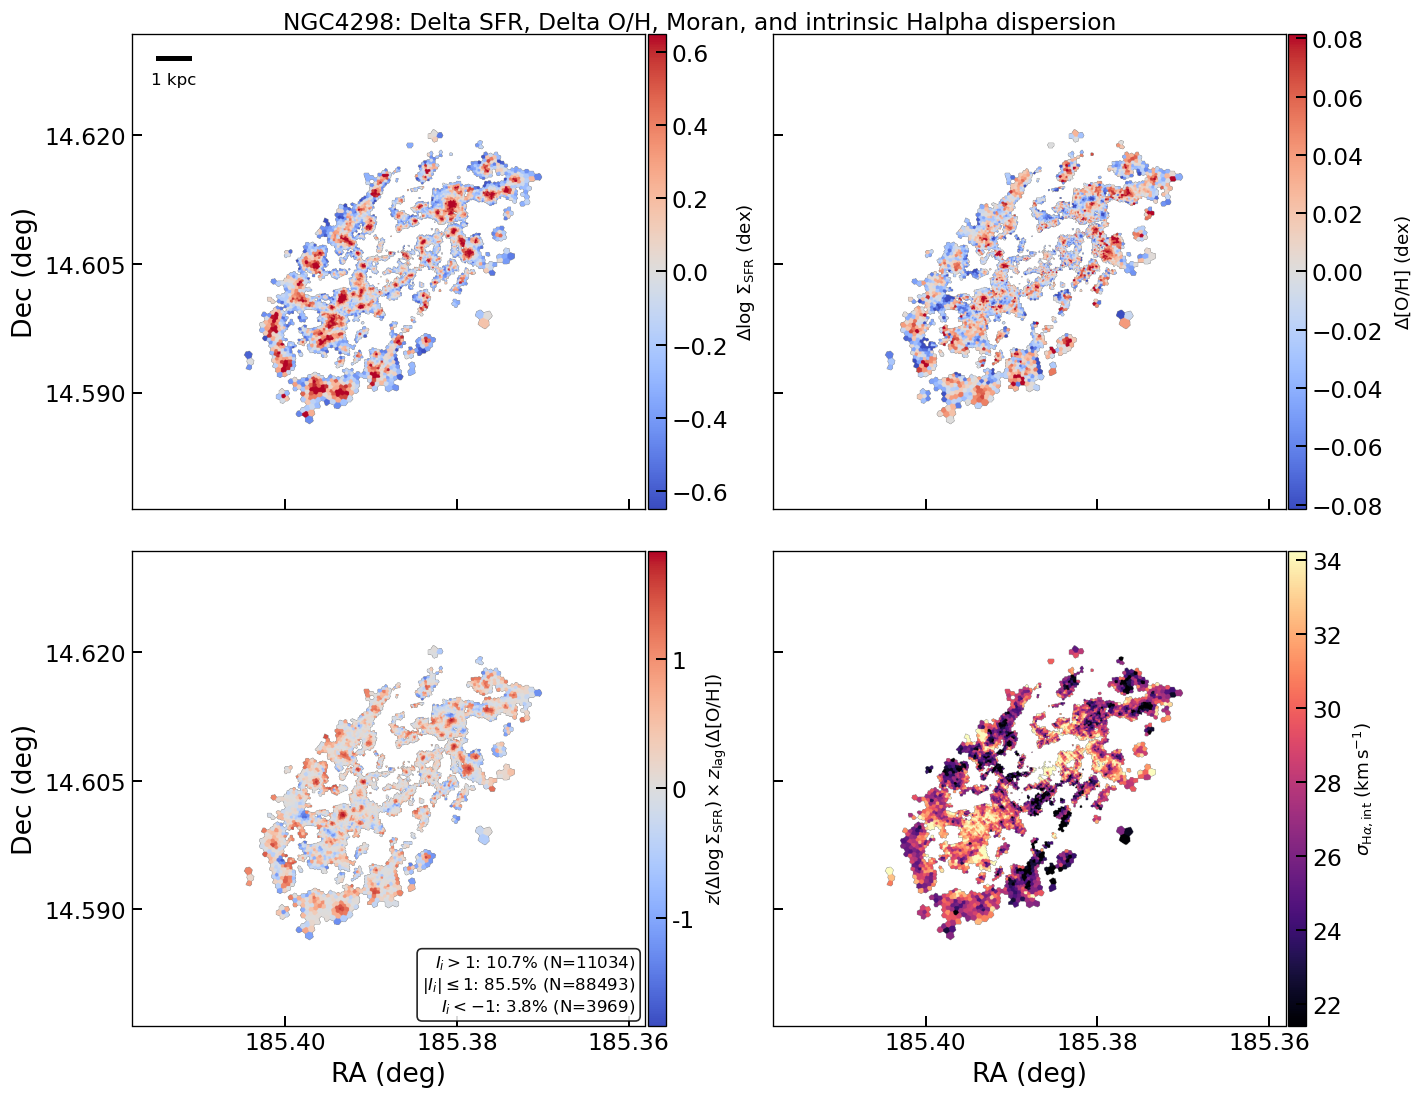

In [12]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Focused 2x2 map figures: offset maps + Moran-like map + intrinsic Halpha dispersion map
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    from astropy.wcs import WCS
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gs_module
    from matplotlib.colors import BoundaryNorm, SymLogNorm
    import matplotlib.ticker as mticker
    from matplotlib.ticker import ScalarFormatter

    # Only focus on the two requested galaxies for this visualisation.
    galaxies = [gal for gal in FOCUS_GALAXIES if gal in physics_ready_galaxies(require_ew=True)]
    missing_focus = [gal for gal in FOCUS_GALAXIES if gal not in galaxies]
    if missing_focus:
        print('Skipped focus galaxies because nested *_further mass/SFR/OH+EW products are not ready:', ', '.join(missing_focus))

    # ------------------------------------------------------------------
    # Define threshold parameter for linear/log colorbar transition and classification
    # ------------------------------------------------------------------
    threshold = 1  # Values between -threshold and +threshold use linear scale

    # ------------------------------------------------------------------
    # 1.  Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
            binid_map = np.asarray(h_spatial['BINID'].data, dtype=float)
            wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
        with fits.open(gas_path) as h_gas:
            sigSFR = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            ha_sigma_corr = np.asarray(h_gas['HA6562_SIGMA_CORR'].data, dtype=float) if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            ha_sigma_corr = align_map_to_shape(ha_sigma_corr, ha_sigma_obs.shape, label=f'{gal} HA6562_SIGMA_CORR')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = np.asarray(h_gas['O_H_O3N2_M14_HII'].data, dtype=float)
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = np.asarray(h_gas['O_H_O3N2_M13_HII'].data, dtype=float)
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
            gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        sigM = align_map_to_shape(sigM, sigSFR.shape, label=f"{gal} LOGMASS_SURFACE_DENSITY")
        binid_map = align_map_to_shape(binid_map, sigSFR.shape, label=f"{gal} BINID")
        oh_map = align_map_to_shape(oh_map, sigSFR.shape, label=f"{gal} {indicator_name}")
        ha_sigma = align_map_to_shape(ha_sigma, sigSFR.shape, label=f"{gal} intrinsic HA6562_SIGMA")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, ha_sigma, indicator_name, wcs, gas_header, binid_map

    for gal in galaxies:
        sigM, sigSFR, oh_o3n2_map, ha_sigma, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        # ------------------------------------------------------------------
        # 2.  Calculate offset maps (relative to Σ* bin means)
        # ------------------------------------------------------------------
        # Define 12 Σ* bins
        n_bins = 12
        sigmaM_min = np.nanmin(sigM[valid_all])
        sigmaM_max = np.nanmax(sigM[valid_all])
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
        # Initialize offset maps
        sfr_offset = np.full_like(sigSFR, np.nan)
        oh_offset = np.full_like(oh_o3n2_map, np.nan)
    
        # Calculate offset for each Σ* bin
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            if np.sum(bin_mask) > 0:
                # Calculate bin mean and offset within this bin
                sfr_bin_mean = np.mean(sigSFR[bin_mask])
                oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
            
                sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
                oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
    
        sfr_offset_max = np.nanpercentile(np.abs(sfr_offset[valid_all]), 95)
        # Reduce Delta O/H range to 95th percentile to highlight differences
        oh_offset_max = np.nanpercentile(np.abs(oh_offset[valid_all]), 95)
    

        # ------------------------------------------------------------------
        # 3.  Calculate local bivariate Moran-like map
        # ------------------------------------------------------------------
        def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
            """Local bivariate Moran-style statistic on adjacent spatial bins.

            Each valid BINID is treated as one graph node, using the mean A and B value
            of that bin. The resulting per-bin Moran value is expanded back to all
            valid pixels in the bin for plotting.
            """
            A = np.asarray(A, dtype=float)
            B = np.asarray(B, dtype=float)
            valid_mask = np.asarray(valid_mask, dtype=bool)
            binid_raw = np.asarray(binid_map, dtype=float)
            if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
                raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

            I_map = np.full(A.shape, np.nan)
            quad_map = np.zeros(A.shape, dtype=np.int16)
            finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
            binid = np.full(A.shape, -1, dtype=np.int64)
            binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
            valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
            valid_bins = np.unique(binid[valid])
            if valid_bins.size < 2:
                return I_map, quad_map

            max_bin = int(valid_bins.max())
            flat_bins = binid[valid].ravel()
            counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
            sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
            sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
            A_bin = np.full(max_bin + 1, np.nan)
            B_bin = np.full(max_bin + 1, np.nan)
            has_data = counts > 0
            A_bin[has_data] = sum_A[has_data] / counts[has_data]
            B_bin[has_data] = sum_B[has_data] / counts[has_data]

            A_vals = A_bin[valid_bins]
            B_vals = B_bin[valid_bins]
            A_std = np.nanstd(A_vals)
            B_std = np.nanstd(B_vals)
            if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
                return I_map, quad_map

            Az = np.full(max_bin + 1, np.nan)
            Bz = np.full(max_bin + 1, np.nan)
            Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
            Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

            offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
            if neighbourhood == 'queen':
                offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
            elif neighbourhood != 'rook':
                raise ValueError("neighbourhood must be 'rook' or 'queen'")

            adjacency = {int(b): set() for b in valid_bins}
            rows, cols = A.shape
            for dy, dx in offsets:
                y0 = max(0, -dy)
                y1 = rows - max(0, dy)
                x0 = max(0, -dx)
                x1 = cols - max(0, dx)
                src = (slice(y0, y1), slice(x0, x1))
                dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
                pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
                for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                    left = int(left)
                    right = int(right)
                    adjacency[left].add(right)
                    adjacency[right].add(left)

            for b in valid_bins:
                b = int(b)
                neigh = sorted(adjacency[b])
                if not neigh:
                    continue
                lag_B = np.nanmean(Bz[neigh])
                I_val = Az[b] * lag_B
                pixels = valid & (binid == b)
                I_map[pixels] = I_val
                if Az[b] >= 0 and lag_B >= 0:
                    quad_map[pixels] = 1
                elif Az[b] < 0 and lag_B < 0:
                    quad_map[pixels] = 2
                elif Az[b] >= 0 and lag_B < 0:
                    quad_map[pixels] = 3
                else:
                    quad_map[pixels] = 4

            return I_map, quad_map
        I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                                neighbourhood='queen')

        # ------------------------------------------------------------------
        # Calculate statistics for three classes based on threshold
        # ------------------------------------------------------------------
        valid_I = np.isfinite(I_map)
        n_total = np.sum(valid_I)
        n_high = np.sum(I_map[valid_I] > threshold)
        n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
        n_low = np.sum(I_map[valid_I] < -threshold)
        pct_high = (n_high / n_total * 100) if n_total > 0 else 0
        pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
        pct_low = (n_low / n_total * 100) if n_total > 0 else 0

        # ------------------------------------------------------------------
        # 4.  Create binned Σ* map
        # ------------------------------------------------------------------
        sigM_binned_map = np.full_like(sigM, np.nan)
    
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            # Assign bin center value
            bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
            sigM_binned_map[bin_mask] = bin_center

        # ------------------------------------------------------------------
        # 5.  Prepare coordinate extent
        # ------------------------------------------------------------------
        wcs_celestial = WCS(gas_header).celestial
        y_size, x_size = sigSFR.shape
        x_coords = np.arange(x_size)
        y_coords = np.arange(y_size)
        xx, yy = np.meshgrid(x_coords, y_coords)
        ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
        extent = [ra.max(), ra.min(), dec.min(), dec.max()]

        # ------------------------------------------------------------------
        # 5b.  Scale bar: 5 kpc for 0.2 arcsec/pixel at 16.5 Mpc
        # ------------------------------------------------------------------
        pix_scale_arcsec = 0.2
        distance_mpc = 16.5
        # calculate degrees for 5 kpc, including cos(dec) for the RA axis
        kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
        scalebar_kpc = 1
        scalebar_length_deg = (scalebar_kpc * kpc_arcsec) / 3600.0
        mean_dec = np.nanmean(dec)
        scalebar_length_deg_ra = scalebar_length_deg / np.cos(np.deg2rad(mean_dec))

        def add_scalebar(ax, length_deg, label='1 kpc'):
            x0, x1 = ax.get_xlim()
            x_range = abs(x1 - x0)
            if x_range == 0:
                return
            frac_len = length_deg / x_range
            x_start = 0.05
            y_start = 0.95
            x_end = x_start + frac_len
            line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                            color='k', lw=3, clip_on=False)
            line.set_in_layout(False)
            txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                          transform=ax.transAxes, ha='center', va='top', color='k')
            txt.set_in_layout(False)

        # ------------------------------------------------------------------
        # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
        # ------------------------------------------------------------------
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        # Auto-derive a reasonable figsize from the map extent
        dx = abs(extent[1] - extent[0])   # RA span
        dy = abs(extent[3] - extent[2])   # Dec span
        data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

        panel_h = 4.2   # inches per panel height (tune once)
        panel_w = panel_h * data_ratio
        cbar_w = 0.35   # inches per colorbar (tune once)

        W = 2 * panel_w + 2 * cbar_w + 1.2
        H = 2 * panel_h + 0.8

        fig, axs = plt.subplots(
            2, 2, figsize=(W, H), sharex=True, sharey=True
        )

        # Make space for the appended colorbars (right margin matters)
        fig.subplots_adjust(
            left=0.07, right=0.96, bottom=0.07, top=0.98,
            wspace=0.20, hspace=0.06
        )

        ax1, ax2 = axs[0, 0], axs[0, 1]
        ax3, ax4 = axs[1, 0], axs[1, 1]

        def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size=size, pad=pad)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
            return cbar

        # --- Ticks / formatting (readable RA, no +1.834e2)
        for ax in (ax1, ax2, ax3, ax4):
            ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

        # Hide inner tick labels
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
        plt.setp(ax2.get_yticklabels(), visible=False)
        plt.setp(ax4.get_yticklabels(), visible=False)

        # Axis labels (outer only)
        ax3.set_xlabel("RA (deg)", fontsize=16)
        ax4.set_xlabel("RA (deg)", fontsize=16)
        ax1.set_ylabel("Dec (deg)", fontsize=16)
        ax3.set_ylabel("Dec (deg)", fontsize=16)

        # ---- Panel 1: SFR offset
        im_sfr = ax1.imshow(
            np.ma.masked_invalid(sfr_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
            aspect="equal"
        )
        add_scalebar(ax1, scalebar_length_deg_ra, label="1 kpc")
        add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

        # ---- Panel 2: OH offset
        im_oh = ax2.imshow(
            np.ma.masked_invalid(oh_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
            aspect="equal"
        )
        add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

        # ---- Panel 3: Moran-like
        vI = np.nanmax(np.abs(I_map))
        norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

        imI = ax3.imshow(
            np.ma.masked_invalid(I_map),
            origin="lower", cmap="coolwarm",
            extent=extent, norm=norm,
            aspect="equal"
        )
        cbarI = add_cbar(
            ax3, imI,
            r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
        )

        # Keep your symmetric-log ticks logic
        max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
        pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
        pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
        neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
        ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
        cbarI.set_ticks(ticks)
        cbarI.set_ticklabels([f"{t:g}" for t in ticks])

        legend_text = (
            rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
            '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
            '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
        )
        ax3.text(
            0.98, 0.02, legend_text, transform=ax3.transAxes,
            fontsize=10, va="bottom", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        # ---- Panel 4: intrinsic Halpha dispersion
        ha_sigma_plot = np.where(valid_all & np.isfinite(ha_sigma), ha_sigma, np.nan)
        sigma_values = ha_sigma_plot[np.isfinite(ha_sigma_plot)]
        if sigma_values.size:
            sigma_vmin, sigma_vmax = np.nanpercentile(sigma_values, [5, 95])
        else:
            sigma_vmin, sigma_vmax = np.nan, np.nan
        im_sigma = ax4.imshow(
            np.ma.masked_invalid(ha_sigma_plot),
            origin="lower", cmap="magma",
            extent=extent, vmin=sigma_vmin, vmax=sigma_vmax,
            aspect="equal"
        )
        add_cbar(ax4, im_sigma, r'$\sigma_{\mathrm{H}\alpha,\mathrm{int}}\;(\mathrm{km\,s}^{-1})$')

        fig.suptitle(f'{gal}: Delta SFR, Delta O/H, Moran, and intrinsic Halpha dispersion', fontsize=14, y=0.995)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.pdf', bbox_inches="tight", pad_inches=0.02)
        plt.show()
else:
    print("Skipped focused 2x2 intrinsic-Halpha-sigma map cell: no nested *_further mass/SFR/OH+EW products are ready yet.")


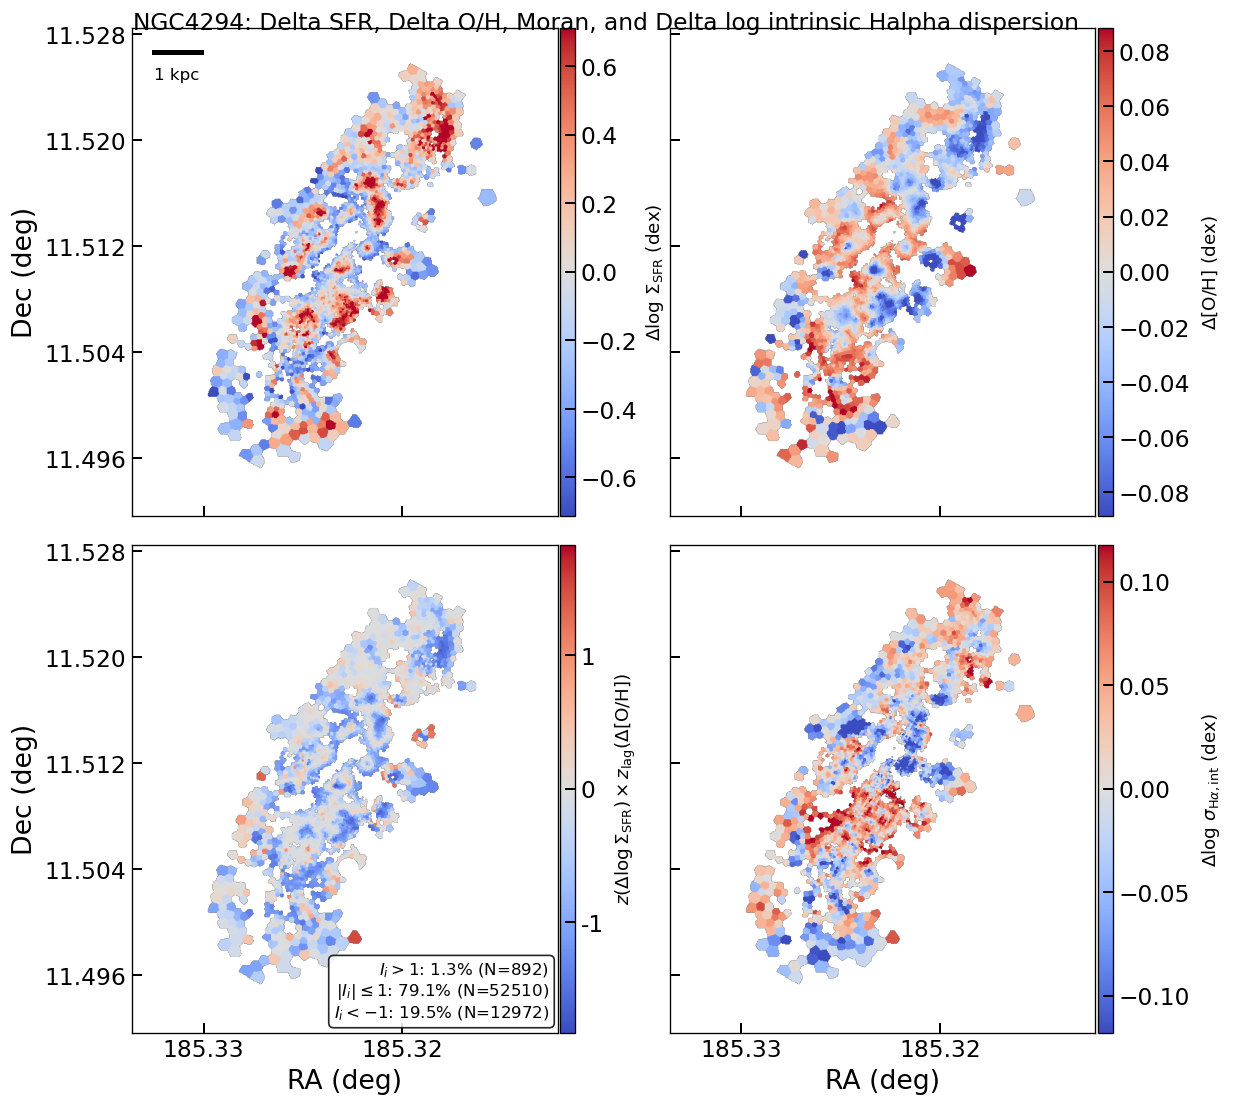

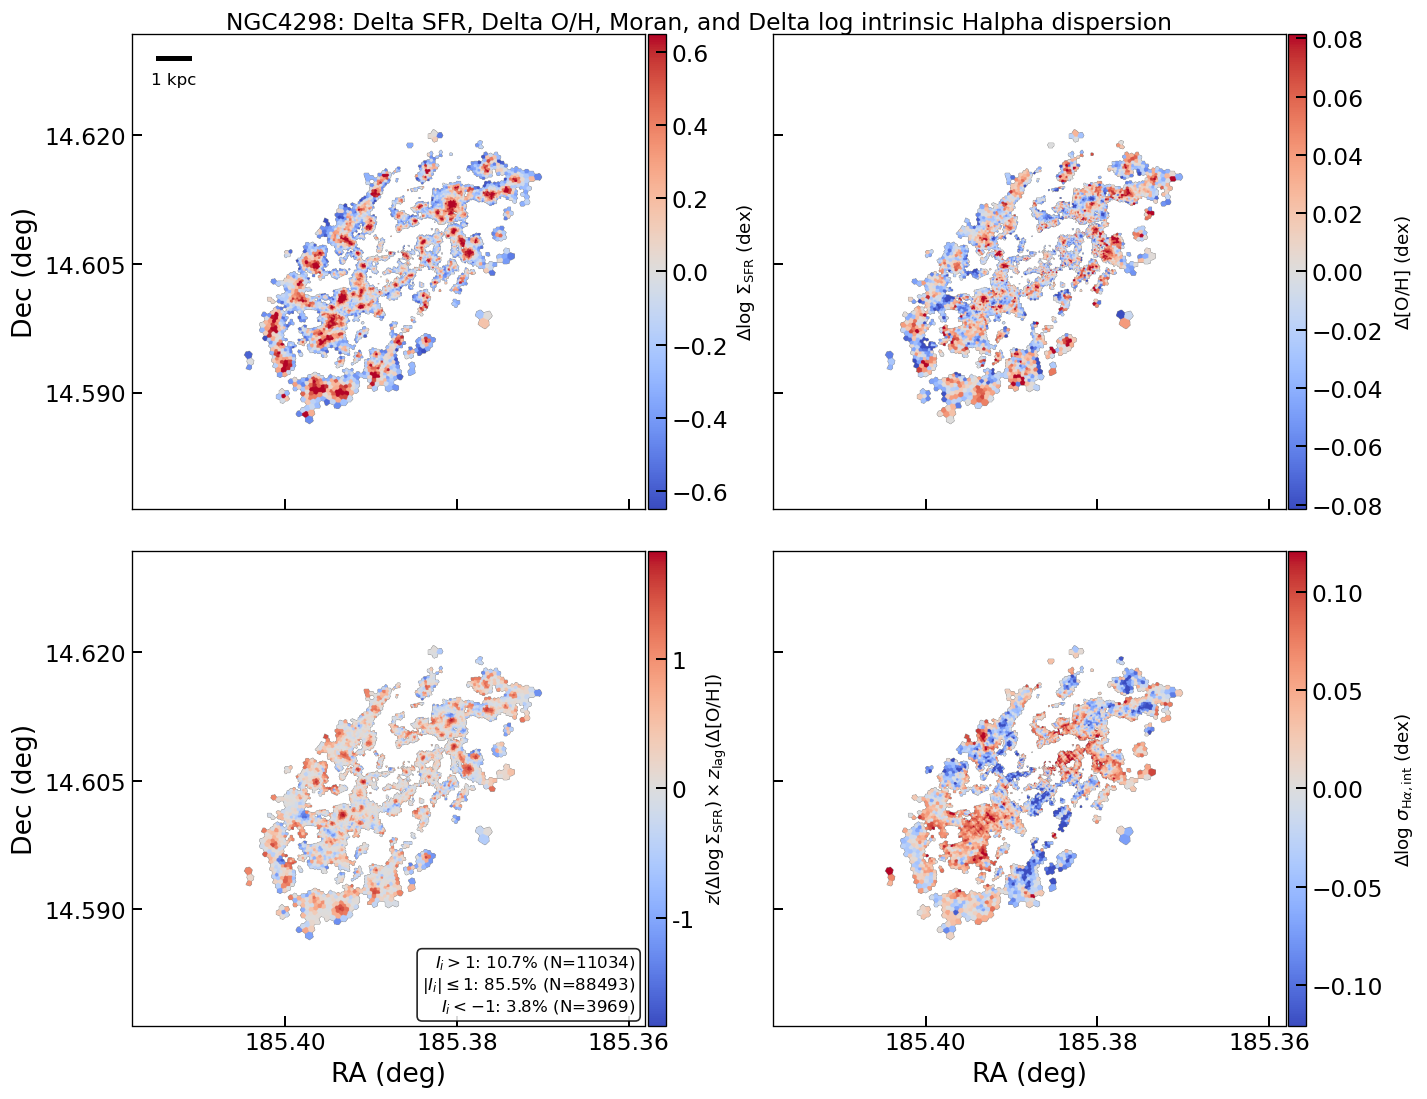

In [13]:
if old_paper_cells_ready(require_ew=True):
    # ------------------------------------------------------------------
    # Focused 2x2 map figures: offset maps + Moran-like map + intrinsic Halpha dispersion map
    # ------------------------------------------------------------------
    from pathlib import Path
    from astropy.io import fits

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0

    from astropy.wcs import WCS
    import numpy as np
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gs_module
    from matplotlib.colors import BoundaryNorm, SymLogNorm
    import matplotlib.ticker as mticker
    from matplotlib.ticker import ScalarFormatter

    # Only focus on the two requested galaxies for this visualisation.
    galaxies = [gal for gal in FOCUS_GALAXIES if gal in physics_ready_galaxies(require_ew=True)]
    missing_focus = [gal for gal in FOCUS_GALAXIES if gal not in galaxies]
    if missing_focus:
        print('Skipped focus galaxies because nested *_further mass/SFR/OH+EW products are not ready:', ', '.join(missing_focus))

    # ------------------------------------------------------------------
    # Define threshold parameter for linear/log colorbar transition and classification
    # ------------------------------------------------------------------
    threshold = 1  # Values between -threshold and +threshold use linear scale

    # ------------------------------------------------------------------
    # 1.  Helper: read the required maps
    # ------------------------------------------------------------------
    def load_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)

        if not (Path(spatial_path).exists() and Path(gas_path).exists() and Path(ew_path).exists()):
            raise FileNotFoundError(f'Required FITS files for {gal} not found.')

        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
            binid_map = np.asarray(h_spatial['BINID'].data, dtype=float)
            wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)
        with fits.open(gas_path) as h_gas:
            sigSFR = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            ha_sigma_corr = np.asarray(h_gas['HA6562_SIGMA_CORR'].data, dtype=float) if 'HA6562_SIGMA_CORR' in h_gas else None
            if ha_sigma_corr is None:
                raise KeyError(f'{gal}: missing HA6562_SIGMA_CORR in {gas_path}')
            ha_sigma_corr = align_map_to_shape(ha_sigma_corr, ha_sigma_obs.shape, label=f'{gal} HA6562_SIGMA_CORR')
            sigma2_intrinsic = ha_sigma_obs**2 - ha_sigma_corr**2
            ha_sigma = np.full_like(ha_sigma_obs, np.nan, dtype=float)
            sigma_ok = np.isfinite(sigma2_intrinsic) & (sigma2_intrinsic > 0)
            ha_sigma[sigma_ok] = np.sqrt(sigma2_intrinsic[sigma_ok])
            if 'O_H_O3N2_M14_HII' in h_gas:
                oh_map = np.asarray(h_gas['O_H_O3N2_M14_HII'].data, dtype=float)
                indicator_name = 'O3N2-M14'
            elif 'O_H_O3N2_M13_HII' in h_gas:
                print(f"Warning: O3N2-M14 not available for {gal}; using O3N2-M13 instead.")
                oh_map = np.asarray(h_gas['O_H_O3N2_M13_HII'].data, dtype=float)
                indicator_name = 'O3N2-M13'
            else:
                available = [hdu.name for hdu in h_gas]
                raise KeyError(f"No O3N2 metallicity extension (M14/M13) found for {gal}. Available: {available}")
            gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header
        with fits.open(ew_path) as h_ew:
            if EW_HDU not in h_ew:
                raise KeyError(f"Missing {EW_HDU} in {ew_path}")
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)
        ew_ha = align_map_to_shape(ew_ha, sigSFR.shape, label=f"{gal} {EW_HDU}")
        sigM = align_map_to_shape(sigM, sigSFR.shape, label=f"{gal} LOGMASS_SURFACE_DENSITY")
        binid_map = align_map_to_shape(binid_map, sigSFR.shape, label=f"{gal} BINID")
        oh_map = align_map_to_shape(oh_map, sigSFR.shape, label=f"{gal} {indicator_name}")
        ha_sigma = align_map_to_shape(ha_sigma, sigSFR.shape, label=f"{gal} intrinsic HA6562_SIGMA")
        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        ew_mask = ew_mask & np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        sigSFR = np.where(ew_mask, sigSFR, np.nan)
        oh_map = np.where(ew_mask, oh_map, np.nan)
        return sigM, sigSFR, oh_map, ha_sigma, indicator_name, wcs, gas_header, binid_map

    for gal in galaxies:
        sigM, sigSFR, oh_o3n2_map, ha_sigma, indicator_name, wcs_full, gas_header, binid_map = load_maps(gal)
        # Valid pixels across maps
        valid_sfr = np.isfinite(sigSFR)
        valid_oh = np.isfinite(oh_o3n2_map)
        valid_sigM = np.isfinite(sigM)
        valid_all = valid_sfr & valid_oh & valid_sigM

        # ------------------------------------------------------------------
        # 2.  Calculate offset maps (relative to Σ* bin means)
        # ------------------------------------------------------------------
        # Define 12 Σ* bins
        n_bins = 12
        sigmaM_min = np.nanmin(sigM[valid_all])
        sigmaM_max = np.nanmax(sigM[valid_all])
        sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)
    
        # Initialize offset maps
        sfr_offset = np.full_like(sigSFR, np.nan)
        oh_offset = np.full_like(oh_o3n2_map, np.nan)
        ha_sigma_log = np.full_like(ha_sigma, np.nan)
        valid_ha_sigma_log = np.isfinite(ha_sigma) & (ha_sigma > 0)
        ha_sigma_log[valid_ha_sigma_log] = np.log10(ha_sigma[valid_ha_sigma_log])
        ha_sigma_log_offset = np.full_like(ha_sigma_log, np.nan)
    
        # Calculate offset for each Σ* bin
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            if np.sum(bin_mask) > 0:
                # Calculate bin mean and offset within this bin
                sfr_bin_mean = np.mean(sigSFR[bin_mask])
                oh_bin_mean = np.mean(oh_o3n2_map[bin_mask])
                sigma_log_bin_mask = bin_mask & np.isfinite(ha_sigma_log)
            
                sfr_offset[bin_mask] = sigSFR[bin_mask] - sfr_bin_mean
                oh_offset[bin_mask] = oh_o3n2_map[bin_mask] - oh_bin_mean
                if np.sum(sigma_log_bin_mask) > 0:
                    ha_sigma_log_bin_mean = np.mean(ha_sigma_log[sigma_log_bin_mask])
                    ha_sigma_log_offset[sigma_log_bin_mask] = ha_sigma_log[sigma_log_bin_mask] - ha_sigma_log_bin_mean
    
        sfr_offset_max = np.nanpercentile(np.abs(sfr_offset[valid_all]), 95)
        # Reduce Delta O/H range to 95th percentile to highlight differences
        oh_offset_max = np.nanpercentile(np.abs(oh_offset[valid_all]), 95)
        ha_sigma_log_valid = valid_all & np.isfinite(ha_sigma_log_offset)
        ha_sigma_log_offset_max = np.nanpercentile(np.abs(ha_sigma_log_offset[ha_sigma_log_valid]), 95)
    

        # ------------------------------------------------------------------
        # 3.  Calculate local bivariate Moran-like map
        # ------------------------------------------------------------------
        def local_bivariate_moran_by_bin(A, B, valid_mask, binid_map, neighbourhood='queen'):
            """Local bivariate Moran-style statistic on adjacent spatial bins.

            Each valid BINID is treated as one graph node, using the mean A and B value
            of that bin. The resulting per-bin Moran value is expanded back to all
            valid pixels in the bin for plotting.
            """
            A = np.asarray(A, dtype=float)
            B = np.asarray(B, dtype=float)
            valid_mask = np.asarray(valid_mask, dtype=bool)
            binid_raw = np.asarray(binid_map, dtype=float)
            if A.shape != B.shape or A.shape != valid_mask.shape or A.shape != binid_raw.shape:
                raise ValueError('A, B, valid_mask, and binid_map must have the same shape')

            I_map = np.full(A.shape, np.nan)
            quad_map = np.zeros(A.shape, dtype=np.int16)
            finite_bin = np.isfinite(binid_raw) & (binid_raw >= 0)
            binid = np.full(A.shape, -1, dtype=np.int64)
            binid[finite_bin] = np.rint(binid_raw[finite_bin]).astype(np.int64)
            valid = valid_mask & np.isfinite(A) & np.isfinite(B) & (binid >= 0)
            valid_bins = np.unique(binid[valid])
            if valid_bins.size < 2:
                return I_map, quad_map

            max_bin = int(valid_bins.max())
            flat_bins = binid[valid].ravel()
            counts = np.bincount(flat_bins, minlength=max_bin + 1).astype(float)
            sum_A = np.bincount(flat_bins, weights=A[valid].ravel(), minlength=max_bin + 1)
            sum_B = np.bincount(flat_bins, weights=B[valid].ravel(), minlength=max_bin + 1)
            A_bin = np.full(max_bin + 1, np.nan)
            B_bin = np.full(max_bin + 1, np.nan)
            has_data = counts > 0
            A_bin[has_data] = sum_A[has_data] / counts[has_data]
            B_bin[has_data] = sum_B[has_data] / counts[has_data]

            A_vals = A_bin[valid_bins]
            B_vals = B_bin[valid_bins]
            A_std = np.nanstd(A_vals)
            B_std = np.nanstd(B_vals)
            if not np.isfinite(A_std) or not np.isfinite(B_std) or A_std == 0 or B_std == 0:
                return I_map, quad_map

            Az = np.full(max_bin + 1, np.nan)
            Bz = np.full(max_bin + 1, np.nan)
            Az[valid_bins] = (A_vals - np.nanmean(A_vals)) / A_std
            Bz[valid_bins] = (B_vals - np.nanmean(B_vals)) / B_std

            offsets = [(-1, 0), (1, 0), (0, -1), (0, 1)]
            if neighbourhood == 'queen':
                offsets += [(-1, -1), (-1, 1), (1, -1), (1, 1)]
            elif neighbourhood != 'rook':
                raise ValueError("neighbourhood must be 'rook' or 'queen'")

            adjacency = {int(b): set() for b in valid_bins}
            rows, cols = A.shape
            for dy, dx in offsets:
                y0 = max(0, -dy)
                y1 = rows - max(0, dy)
                x0 = max(0, -dx)
                x1 = cols - max(0, dx)
                src = (slice(y0, y1), slice(x0, x1))
                dst = (slice(y0 + dy, y1 + dy), slice(x0 + dx, x1 + dx))
                pair_valid = valid[src] & valid[dst] & (binid[src] != binid[dst])
                for left, right in zip(binid[src][pair_valid], binid[dst][pair_valid]):
                    left = int(left)
                    right = int(right)
                    adjacency[left].add(right)
                    adjacency[right].add(left)

            for b in valid_bins:
                b = int(b)
                neigh = sorted(adjacency[b])
                if not neigh:
                    continue
                lag_B = np.nanmean(Bz[neigh])
                I_val = Az[b] * lag_B
                pixels = valid & (binid == b)
                I_map[pixels] = I_val
                if Az[b] >= 0 and lag_B >= 0:
                    quad_map[pixels] = 1
                elif Az[b] < 0 and lag_B < 0:
                    quad_map[pixels] = 2
                elif Az[b] >= 0 and lag_B < 0:
                    quad_map[pixels] = 3
                else:
                    quad_map[pixels] = 4

            return I_map, quad_map
        I_map, quad_map = local_bivariate_moran_by_bin(sfr_offset, oh_offset, valid_all, binid_map,
                                                neighbourhood='queen')

        # ------------------------------------------------------------------
        # Calculate statistics for three classes based on threshold
        # ------------------------------------------------------------------
        valid_I = np.isfinite(I_map)
        n_total = np.sum(valid_I)
        n_high = np.sum(I_map[valid_I] > threshold)
        n_mid = np.sum((I_map[valid_I] >= -threshold) & (I_map[valid_I] <= threshold))
        n_low = np.sum(I_map[valid_I] < -threshold)
        pct_high = (n_high / n_total * 100) if n_total > 0 else 0
        pct_mid = (n_mid / n_total * 100) if n_total > 0 else 0
        pct_low = (n_low / n_total * 100) if n_total > 0 else 0

        # ------------------------------------------------------------------
        # 4.  Create binned Σ* map
        # ------------------------------------------------------------------
        sigM_binned_map = np.full_like(sigM, np.nan)
    
        for i in range(n_bins):
            if i == 0:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
            elif i == n_bins - 1:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM <= sigmaM_bin_edges[i+1]) & valid_all
            else:
                bin_mask = (sigM >= sigmaM_bin_edges[i]) & (sigM < sigmaM_bin_edges[i+1]) & valid_all
        
            # Assign bin center value
            bin_center = (sigmaM_bin_edges[i] + sigmaM_bin_edges[i+1]) / 2
            sigM_binned_map[bin_mask] = bin_center

        # ------------------------------------------------------------------
        # 5.  Prepare coordinate extent
        # ------------------------------------------------------------------
        wcs_celestial = WCS(gas_header).celestial
        y_size, x_size = sigSFR.shape
        x_coords = np.arange(x_size)
        y_coords = np.arange(y_size)
        xx, yy = np.meshgrid(x_coords, y_coords)
        ra, dec = wcs_celestial.pixel_to_world_values(xx, yy)
        extent = [ra.max(), ra.min(), dec.min(), dec.max()]

        # ------------------------------------------------------------------
        # 5b.  Scale bar: 5 kpc for 0.2 arcsec/pixel at 16.5 Mpc
        # ------------------------------------------------------------------
        pix_scale_arcsec = 0.2
        distance_mpc = 16.5
        # calculate degrees for 5 kpc, including cos(dec) for the RA axis
        kpc_arcsec = 206265.0 / (distance_mpc * 1000.0)
        scalebar_kpc = 1
        scalebar_length_deg = (scalebar_kpc * kpc_arcsec) / 3600.0
        mean_dec = np.nanmean(dec)
        scalebar_length_deg_ra = scalebar_length_deg / np.cos(np.deg2rad(mean_dec))

        def add_scalebar(ax, length_deg, label='1 kpc'):
            x0, x1 = ax.get_xlim()
            x_range = abs(x1 - x0)
            if x_range == 0:
                return
            frac_len = length_deg / x_range
            x_start = 0.05
            y_start = 0.95
            x_end = x_start + frac_len
            line, = ax.plot([x_start, x_end], [y_start, y_start], transform=ax.transAxes,
                            color='k', lw=3, clip_on=False)
            line.set_in_layout(False)
            txt = ax.text((x_start + x_end) / 2, y_start - 0.03, label,
                          transform=ax.transAxes, ha='center', va='top', color='k')
            txt.set_in_layout(False)

        # ------------------------------------------------------------------
        # 6.  2x2 figure: shared axes, equal aspect preserved, colorbars glued to axes
        # ------------------------------------------------------------------
        from mpl_toolkits.axes_grid1 import make_axes_locatable

        # Auto-derive a reasonable figsize from the map extent
        dx = abs(extent[1] - extent[0])   # RA span
        dy = abs(extent[3] - extent[2])   # Dec span
        data_ratio = (dx / dy) if dy > 0 else 1.0  # width / height

        panel_h = 4.2   # inches per panel height (tune once)
        panel_w = panel_h * data_ratio
        cbar_w = 0.35   # inches per colorbar (tune once)

        W = 2 * panel_w + 2 * cbar_w + 1.2
        H = 2 * panel_h + 0.8

        fig, axs = plt.subplots(
            2, 2, figsize=(W, H), sharex=True, sharey=True
        )

        # Make space for the appended colorbars (right margin matters)
        fig.subplots_adjust(
            left=0.07, right=0.96, bottom=0.07, top=0.98,
            wspace=0.20, hspace=0.06
        )

        ax1, ax2 = axs[0, 0], axs[0, 1]
        ax3, ax4 = axs[1, 0], axs[1, 1]

        def add_cbar(ax, im, label, size="3.5%", pad=0.02, labelpad=6, labelsize=11):
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size=size, pad=pad)
            cbar = fig.colorbar(im, cax=cax)
            cbar.set_label(label, fontsize=labelsize, labelpad=labelpad)
            return cbar

        # --- Ticks / formatting (readable RA, no +1.834e2)
        for ax in (ax1, ax2, ax3, ax4):
            ax.xaxis.set_major_locator(mticker.MaxNLocator(3))
            ax.yaxis.set_major_locator(mticker.MaxNLocator(5))
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

        # Hide inner tick labels
        plt.setp(ax1.get_xticklabels(), visible=False)
        plt.setp(ax2.get_xticklabels(), visible=False)
        plt.setp(ax2.get_yticklabels(), visible=False)
        plt.setp(ax4.get_yticklabels(), visible=False)

        # Axis labels (outer only)
        ax3.set_xlabel("RA (deg)", fontsize=16)
        ax4.set_xlabel("RA (deg)", fontsize=16)
        ax1.set_ylabel("Dec (deg)", fontsize=16)
        ax3.set_ylabel("Dec (deg)", fontsize=16)

        # ---- Panel 1: SFR offset
        im_sfr = ax1.imshow(
            np.ma.masked_invalid(sfr_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-sfr_offset_max, vmax=sfr_offset_max,
            aspect="equal"
        )
        add_scalebar(ax1, scalebar_length_deg_ra, label="1 kpc")
        add_cbar(ax1, im_sfr, r'$\Delta\log\,\Sigma_{\mathrm{SFR}}$ (dex)', labelpad=4)

        # ---- Panel 2: OH offset
        im_oh = ax2.imshow(
            np.ma.masked_invalid(oh_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-oh_offset_max, vmax=oh_offset_max,
            aspect="equal"
        )
        add_cbar(ax2, im_oh, r'$\Delta$[O/H] (dex)')

        # ---- Panel 3: Moran-like
        vI = np.nanmax(np.abs(I_map))
        norm = SymLogNorm(linthresh=threshold, linscale=1.0, vmin=-vI, vmax=vI, base=10)

        imI = ax3.imshow(
            np.ma.masked_invalid(I_map),
            origin="lower", cmap="coolwarm",
            extent=extent, norm=norm,
            aspect="equal"
        )
        cbarI = add_cbar(
            ax3, imI,
            r'$z(\Delta\log\Sigma_{\rm SFR}) \times z_{\rm lag}(\Delta{\rm [O/H]})$'
        )

        # Keep your symmetric-log ticks logic
        max_pow = int(np.floor(np.log10(vI))) if vI > 0 else 0
        pos_ticks = [10**k for k in range(0, max_pow + 1) if 10**k <= vI]
        pos_ticks_filtered = [p for p in pos_ticks if p != threshold]
        neg_ticks_filtered = [-p for p in reversed(pos_ticks_filtered)]
        ticks = sorted(set(neg_ticks_filtered + [-threshold, 0.0, threshold] + pos_ticks_filtered))
        cbarI.set_ticks(ticks)
        cbarI.set_ticklabels([f"{t:g}" for t in ticks])

        legend_text = (
            rf'$I_i > {threshold}$: {pct_high:.1f}% (N={n_high})'
            '\n' + rf'$|I_i| \leq {threshold}$: {pct_mid:.1f}% (N={n_mid})'
            '\n' + rf'$I_i < -{threshold}$: {pct_low:.1f}% (N={n_low})'
        )
        ax3.text(
            0.98, 0.02, legend_text, transform=ax3.transAxes,
            fontsize=10, va="bottom", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85)
        )

        # ---- Panel 4: intrinsic Halpha dispersion log-offset
        im_sigma = ax4.imshow(
            np.ma.masked_invalid(ha_sigma_log_offset),
            origin="lower", cmap="coolwarm",
            extent=extent, vmin=-ha_sigma_log_offset_max, vmax=ha_sigma_log_offset_max,
            aspect="equal"
        )
        add_cbar(ax4, im_sigma, r'$\Delta\log\,\sigma_{\mathrm{H}\alpha,\mathrm{int}}$ (dex)')

        fig.suptitle(f'{gal}: Delta SFR, Delta O/H, Moran, and Delta log intrinsic Halpha dispersion', fontsize=14, y=0.995)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.png', dpi=600, bbox_inches="tight", pad_inches=0.02)
        # fig.savefig(f'Plot_Paper_1/{gal}_correlation_map_moran_EW.pdf', bbox_inches="tight", pad_inches=0.02)
        plt.show()
else:
    print("Skipped focused 2x2 intrinsic-Halpha-sigma map cell: no nested *_further mass/SFR/OH+EW products are ready yet.")


## Follow-up tests for the NGC4294/NGC4298 sign flip

The Halpha intrinsic-dispersion residual map above does not obviously track the local Moran-like structure.  That makes it worth separating several other possibilities before interpreting the opposite fixed-mass O/H--SFR signs physically:

1. **Calibration or excitation sensitivity:** if the sign changes between the required O3N2-M13, O3N2-C20, D16, PG16 set and the extra N2/N2S2/S2/R3/RS32/direct-method calibrations, the effect may be driven by line-ratio physics rather than abundance alone.
2. **DIG/shock/ionization contamination:** maps such as EW(Halpha), [S II]/Halpha, [N II]/Halpha, [O III]/Hbeta, OIII/NII, NII/SII, BPT class, Balmer decrement, and corrected Halpha/Hbeta flux levels can reveal whether the residual relation follows excitation, diffuse ionized gas, extinction, or low-ionization structures.
3. **Spatial mixing:** a fixed-mass residual can look positive or negative if inner/outer or one-sided structures are mixed together.  Radial bins and left/right/up/down splits test this directly.
4. **Stellar-population context:** SFH age/metallicity/alpha plus stellar/template EBV and stellar kinematics can show whether the residuals sit on older disk, bar/interaction, or dustier stellar-population structures.

The cells below keep the same EW(Halpha) and Halpha-dispersion quality cuts used above so the comparison is on the same effective pixel set.

EW(Halpha) is included deliberately, not as another SFR proxy, but as a check on young-star/HII dominance versus DIG or older-population contamination.  Stellar/template EBV is included as a dust-geometry and stellar-continuum context check; if it correlates with the residual product while Balmer decrement does not, that would point to continuum/dust structure rather than purely nebular attenuation.

In [14]:
# Reusable diagnostic loader for alternative explanations of the NGC4294/NGC4298 residual sign flip.
if old_paper_cells_ready(require_ew=True):
    from pathlib import Path
    from astropy.io import fits
    from astropy.wcs import WCS
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.gridspec as gs_module
    from scipy.stats import spearmanr

    EW_FILE_SUFFIX = '_proxy_EW_maps.fits'
    EW_HDU = 'PROXY_EWHA'
    EW_MIN = 6.0
    N_MASS_BINS_DIAGNOSTIC = 12

    OH_DIAGNOSTIC_HDUS = {
        # Always include these four calibrations in the comparison when present.
        'O3N2-M13': 'O_H_O3N2_M13_HII',
        'O3N2-C20': 'O_H_O3N2_C20_HII',
        'D16': 'O_H_D16_HII',
        'PG16': 'O_H_PG16_HII',
        # Extra calibrations help identify whether the sign flip is O3N2-specific,
        # N2/S2-sensitive, direct-method-sensitive, or robust across methods.
        'O3N2-PP04': 'O_H_O3N2_PP04_HII',
        'N2-M13': 'O_H_N2_M13_HII',
        'N2-PP04': 'O_H_N2_PP04_HII',
        'N2-C20': 'O_H_N2_C20_HII',
        'N2S2-N06': 'O_H_N2S2_N06_HII',
        'S2-C20': 'O_H_S2_C20_HII',
        'O3S2-C20': 'O_H_O3S2_C20_HII',
        'R3-C20': 'O_H_R3_C20_HII',
        'RS32-C20': 'O_H_RS32_C20_HII',
        'Combined-C20': 'O_H_COMBINED_C20_HII',
        'Direct-BR24': 'O_H_BR24_DIRECT_HII',
    }

    def diagnostic_safe_log10(arr):
        arr = np.asarray(arr, dtype=float)
        out = np.full(arr.shape, np.nan, dtype=float)
        ok = np.isfinite(arr) & (arr > 0)
        out[ok] = np.log10(arr[ok])
        return out

    def diagnostic_ratio_log10(num, den):
        return diagnostic_safe_log10(np.asarray(num, dtype=float) / np.asarray(den, dtype=float))

    def diagnostic_align(arr, shape, label):
        return align_map_to_shape(arr, shape, label=label)

    def fixed_mass_residuals(sigM, maps, valid_mask, n_bins=N_MASS_BINS_DIAGNOSTIC, reducer=np.nanmedian):
        sigM = np.asarray(sigM, dtype=float)
        valid_mask = np.asarray(valid_mask, dtype=bool)
        finite_mass = valid_mask & np.isfinite(sigM)
        if np.sum(finite_mass) == 0:
            return {name: np.full_like(sigM, np.nan, dtype=float) for name in maps}
        edges = np.linspace(np.nanmin(sigM[finite_mass]), np.nanmax(sigM[finite_mass]), n_bins + 1)
        residuals = {name: np.full_like(np.asarray(arr, dtype=float), np.nan, dtype=float) for name, arr in maps.items()}
        for i in range(n_bins):
            if i == n_bins - 1:
                bin_mask = finite_mass & (sigM >= edges[i]) & (sigM <= edges[i + 1])
            else:
                bin_mask = finite_mass & (sigM >= edges[i]) & (sigM < edges[i + 1])
            if np.sum(bin_mask) < 10:
                continue
            for name, arr in maps.items():
                arr = np.asarray(arr, dtype=float)
                arr_mask = bin_mask & np.isfinite(arr)
                if np.sum(arr_mask) < 10:
                    continue
                residuals[name][arr_mask] = arr[arr_mask] - reducer(arr[arr_mask])
        return residuals

    def diagnostic_spearman(x, y, min_n=25):
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)
        ok = np.isfinite(x) & np.isfinite(y)
        if np.sum(ok) < min_n:
            return np.nan, np.nan, int(np.sum(ok))
        rho, pval = spearmanr(x[ok], y[ok])
        return float(rho), float(pval), int(np.sum(ok))

    def load_focus_diagnostic_maps(gal):
        spatial_path = further_spatial_path(gal)
        gas_path = further_gas_path(gal)
        ew_path = further_ew_path(gal, EW_FILE_SUFFIX)
        row = PRODUCTS.loc[gal]
        sfh_path = None if row.get('sfh_path') is None else Path(row.get('sfh_path'))
        kin_path = None if row.get('kin_path') is None else Path(row.get('kin_path'))

        with fits.open(spatial_path) as h_spatial:
            sigM = np.asarray(h_spatial['LOGMASS_SURFACE_DENSITY'].data, dtype=float)
            binid_map = np.asarray(h_spatial['BINID'].data, dtype=float)
            xbin = np.asarray(h_spatial['XBIN'].data, dtype=float) if 'XBIN' in h_spatial else np.indices(sigM.shape)[1].astype(float)
            ybin = np.asarray(h_spatial['YBIN'].data, dtype=float) if 'YBIN' in h_spatial else np.indices(sigM.shape)[0].astype(float)
            wcs = WCS(h_spatial['LOGMASS_SURFACE_DENSITY'].header)

        with fits.open(gas_path) as h_gas:
            shape = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float).shape
            sigSFR = np.asarray(h_gas['LOGSFR_SURFACE_DENSITY_HII'].data, dtype=float)
            oh_maps = {}
            for label, hdu_name in OH_DIAGNOSTIC_HDUS.items():
                if hdu_name in h_gas:
                    oh_maps[label] = diagnostic_align(h_gas[hdu_name].data, shape, f'{gal} {hdu_name}')

            ha_sigma_obs = np.asarray(h_gas['HA6562_SIGMA'].data, dtype=float)
            ha_sigma_corr = np.asarray(h_gas['HA6562_SIGMA_CORR'].data, dtype=float) if 'HA6562_SIGMA_CORR' in h_gas else None
            ha_sigma = intrinsic_sigma_from_maps(ha_sigma_obs, ha_sigma_corr, label=f'{gal} HA6562_SIGMA')
            if ha_sigma is None:
                ha_sigma = np.full(shape, np.nan, dtype=float)

            ha_flux = np.asarray(h_gas['HA6562_FLUX_CORR_HII'].data if 'HA6562_FLUX_CORR_HII' in h_gas else h_gas['HA6562_FLUX'].data, dtype=float)
            hb_flux = np.asarray(h_gas['HB4861_FLUX_CORR_HII'].data if 'HB4861_FLUX_CORR_HII' in h_gas else h_gas['HB4861_FLUX'].data, dtype=float)
            nii_flux = np.asarray(h_gas['NII6583_FLUX_CORR_HII'].data if 'NII6583_FLUX_CORR_HII' in h_gas else h_gas['NII6583_FLUX'].data, dtype=float)
            sii_flux = (
                np.asarray(h_gas['SII6716_FLUX_CORR_HII'].data if 'SII6716_FLUX_CORR_HII' in h_gas else h_gas['SII6716_FLUX'].data, dtype=float)
                + np.asarray(h_gas['SII6730_FLUX_CORR_HII'].data if 'SII6730_FLUX_CORR_HII' in h_gas else h_gas['SII6730_FLUX'].data, dtype=float)
            )
            oiii_flux = np.asarray(h_gas['OIII5006_FLUX_CORR_HII'].data if 'OIII5006_FLUX_CORR_HII' in h_gas else h_gas['OIII5006_FLUX'].data, dtype=float)
            ne_sii = np.asarray(h_gas['NE_SII'].data, dtype=float) if 'NE_SII' in h_gas else np.full(shape, np.nan, dtype=float)
            nii_bpt = np.asarray(h_gas['NII_BPT'].data, dtype=float) if 'NII_BPT' in h_gas else np.full(shape, np.nan, dtype=float)
            sii_bpt = np.asarray(h_gas['SII_BPT'].data, dtype=float) if 'SII_BPT' in h_gas else np.full(shape, np.nan, dtype=float)
            ha_vel = np.asarray(h_gas['HA6562_VEL'].data, dtype=float) if 'HA6562_VEL' in h_gas else np.full(shape, np.nan, dtype=float)
            gas_header = h_gas['LOGSFR_SURFACE_DENSITY_HII'].header

        with fits.open(ew_path) as h_ew:
            ew_ha = np.asarray(h_ew[EW_HDU].data, dtype=float)

        sigM = diagnostic_align(sigM, shape, f'{gal} LOGMASS_SURFACE_DENSITY')
        binid_map = diagnostic_align(binid_map, shape, f'{gal} BINID')
        xbin = diagnostic_align(xbin, shape, f'{gal} XBIN')
        ybin = diagnostic_align(ybin, shape, f'{gal} YBIN')
        ew_ha = diagnostic_align(ew_ha, shape, f'{gal} {EW_HDU}')
        ha_sigma = diagnostic_align(ha_sigma, shape, f'{gal} intrinsic HA6562_SIGMA')

        sfh_maps = {}
        if sfh_path is not None and sfh_path.exists():
            with fits.open(sfh_path) as h_sfh:
                for name in ['AGE', 'METAL', 'ALPHA', 'EBV']:
                    if name in h_sfh:
                        label = f'SFH_{name}'
                        if name == 'EBV':
                            label = 'SFH_EBV_stellar_dust'
                        sfh_maps[label] = diagnostic_align(h_sfh[name].data, shape, f'{gal} {label}')

        kin_maps = {}
        if kin_path is not None and kin_path.exists():
            with fits.open(kin_path) as h_kin:
                for name in ['V', 'SIGMA', 'H3', 'H4', 'EBV']:
                    if name in h_kin:
                        label = f'STELLAR_{name}'
                        if name == 'EBV':
                            label = 'KIN_EBV_stellar_template_dust'
                        kin_maps[label] = diagnostic_align(h_kin[name].data, shape, f'{gal} {label}')

        finite_for_center = np.isfinite(sigM) & np.isfinite(xbin) & np.isfinite(ybin)
        x0 = np.nanmedian(xbin[finite_for_center]) if np.any(finite_for_center) else (shape[1] - 1) / 2
        y0 = np.nanmedian(ybin[finite_for_center]) if np.any(finite_for_center) else (shape[0] - 1) / 2
        radius_pix = np.sqrt((xbin - x0)**2 + (ybin - y0)**2)
        if np.any(np.isfinite(radius_pix)) and np.nanmax(radius_pix) > 0:
            radius_norm = radius_pix / np.nanmax(radius_pix)
        else:
            radius_norm = radius_pix

        ew_mask = np.isfinite(ew_ha) & (ew_ha > EW_MIN)
        sigma_mask = np.isfinite(ha_sigma) & (ha_sigma < 45.0)
        base_valid = ew_mask & sigma_mask & np.isfinite(sigM) & np.isfinite(sigSFR)

        o3n2_label = 'O3N2-M13' if 'O3N2-M13' in oh_maps else next(iter(oh_maps))
        base_valid = base_valid & np.isfinite(oh_maps[o3n2_label])

        candidate_maps = {
            'radius_norm': radius_norm,
            'x_offset_pix': xbin - x0,
            'y_offset_pix': ybin - y0,
            'abs_x_offset_pix': np.abs(xbin - x0),
            'abs_y_offset_pix': np.abs(ybin - y0),
            # EW(Halpha) is kept because it is an HII-vs-DIG/young-population stress test:
            # weak EW can make line-ratio metallicities respond to ionization source mix
            # rather than abundance alone, even after the EW>6 cut.
            'log_EW_Ha': diagnostic_safe_log10(ew_ha),
            'log_Ha_flux_corr': diagnostic_safe_log10(ha_flux),
            'log_Hb_flux_corr': diagnostic_safe_log10(hb_flux),
            'log_Ha_sigma_int': diagnostic_safe_log10(ha_sigma),
            'log_NII_Ha': diagnostic_ratio_log10(nii_flux, ha_flux),
            'log_SII_Ha': diagnostic_ratio_log10(sii_flux, ha_flux),
            'log_OIII_Hb': diagnostic_ratio_log10(oiii_flux, hb_flux),
            'log_OIII_NII': diagnostic_ratio_log10(oiii_flux, nii_flux),
            'log_NII_SII': diagnostic_ratio_log10(nii_flux, sii_flux),
            'log_Balmer_dec': diagnostic_ratio_log10(ha_flux, hb_flux),
            'log_NE_SII': diagnostic_safe_log10(ne_sii),
            'NII_BPT': nii_bpt,
            'SII_BPT': sii_bpt,
            'HA_vel': ha_vel,
        }
        candidate_maps.update(sfh_maps)
        candidate_maps.update(kin_maps)

        residual_inputs = {'logSFR_HII': sigSFR, 'OH_O3N2_M13': oh_maps[o3n2_label]}
        residual_inputs.update({f'OH_{label}': arr for label, arr in oh_maps.items()})
        residual_inputs.update(candidate_maps)
        residuals = fixed_mass_residuals(sigM, residual_inputs, base_valid)

        return {
            'galaxy': gal,
            'shape': shape,
            'wcs': wcs,
            'gas_header': gas_header,
            'sigM': sigM,
            'sigSFR': sigSFR,
            'oh_maps': oh_maps,
            'primary_oh_label': o3n2_label,
            'candidate_maps': candidate_maps,
            'residuals': residuals,
            'base_valid': base_valid,
            'radius_norm': radius_norm,
            'x_offset_pix': xbin - x0,
            'y_offset_pix': ybin - y0,
            'binid_map': binid_map,
        }

    FOCUS_DIAGNOSTICS = {
        gal: load_focus_diagnostic_maps(gal)
        for gal in FOCUS_GALAXIES
        if gal in physics_ready_galaxies(require_ew=True)
    }

    print('Loaded focus diagnostic maps:', ', '.join(FOCUS_DIAGNOSTICS))
    for gal, data in FOCUS_DIAGNOSTICS.items():
        print(f"{gal}: valid pixels after EW(Ha)>{EW_MIN:g}, finite intrinsic sigma<45 km/s, mass, SFR, and primary O/H = {np.sum(data['base_valid'])}")
else:
    print('Skipped follow-up diagnostics: no nested *_further mass/SFR/OH+EW products are ready yet.')

Loaded focus diagnostic maps: NGC4294, NGC4298
NGC4294: valid pixels after EW(Ha)>6, finite intrinsic sigma<45 km/s, mass, SFR, and primary O/H = 67102
NGC4298: valid pixels after EW(Ha)>6, finite intrinsic sigma<45 km/s, mass, SFR, and primary O/H = 103876


### Candidate-property screen

This table asks which other maps know about the fixed-mass residual structure.  For each candidate property, I compare the raw map and the fixed-mass residual of that map against three targets:

- `rho_with_dSFR`: does the property follow high/low SFR residuals?
- `rho_with_dOH`: does the property follow high/low O/H residuals?
- `rho_with_product`: does the property separate same-sign and opposite-sign ΔSFR-ΔO/H regions?

Large absolute values are not proof of causality, but they identify the maps that are worth inspecting next.  If line-ratio, BPT-sensitive, EW(Halpha), or flux-level quantities dominate, the sign flip may be partly excitation/DIG/calibration driven.  If radius or one coordinate dominates, the sign flip may be a spatial-mixing effect.

This expanded screen keeps EW(Halpha) and stellar/template EBV because they test different failure modes: EW(Halpha) tracks whether the emission is dominated by compact young HII regions or diluted by older continuum/DIG, while stellar/template EBV checks whether residual structures follow dust and continuum-fitting geometry rather than the nebular abundance calibration itself.

In [15]:
if old_paper_cells_ready(require_ew=True) and 'FOCUS_DIAGNOSTICS' in globals():
    diagnostic_rows = []
    for gal, data in FOCUS_DIAGNOSTICS.items():
        valid = data['base_valid']
        d_sfr = data['residuals']['logSFR_HII']
        d_oh = data['residuals']['OH_O3N2_M13']
        product = d_sfr * d_oh
        for prop, arr in data['candidate_maps'].items():
            for version, prop_arr in [('raw', arr), ('fixed_mass_residual', data['residuals'].get(prop, np.full(data['shape'], np.nan)))]:
                rho_sfr, p_sfr, n_sfr = diagnostic_spearman(prop_arr[valid], d_sfr[valid])
                rho_oh, p_oh, n_oh = diagnostic_spearman(prop_arr[valid], d_oh[valid])
                rho_prod, p_prod, n_prod = diagnostic_spearman(prop_arr[valid], product[valid])
                concordant = valid & np.isfinite(prop_arr) & np.isfinite(product) & (product > 0)
                discordant = valid & np.isfinite(prop_arr) & np.isfinite(product) & (product < 0)
                diagnostic_rows.append({
                    'galaxy': gal,
                    'property': prop,
                    'version': version,
                    'n': min(n_sfr, n_oh, n_prod),
                    'rho_with_dSFR': rho_sfr,
                    'p_with_dSFR': p_sfr,
                    'rho_with_dOH': rho_oh,
                    'p_with_dOH': p_oh,
                    'rho_with_product': rho_prod,
                    'p_with_product': p_prod,
                    'median_concordant': np.nanmedian(prop_arr[concordant]) if np.sum(concordant) else np.nan,
                    'median_discordant': np.nanmedian(prop_arr[discordant]) if np.sum(discordant) else np.nan,
                    'median_concordant_minus_discordant': (
                        np.nanmedian(prop_arr[concordant]) - np.nanmedian(prop_arr[discordant])
                        if np.sum(concordant) and np.sum(discordant) else np.nan
                    ),
                })

    DIAGNOSTIC_PROPERTY_TABLE = pd.DataFrame(diagnostic_rows)
    display(
        DIAGNOSTIC_PROPERTY_TABLE
        .assign(abs_rho_product=lambda df: df['rho_with_product'].abs())
        .sort_values(['galaxy', 'abs_rho_product'], ascending=[True, False])
        .drop(columns='abs_rho_product')
        .groupby('galaxy', group_keys=False)
        .head(12)
        .style.format({
            'rho_with_dSFR': '{:.3f}',
            'p_with_dSFR': '{:.2g}',
            'rho_with_dOH': '{:.3f}',
            'p_with_dOH': '{:.2g}',
            'rho_with_product': '{:.3f}',
            'p_with_product': '{:.2g}',
            'median_concordant': '{:.3g}',
            'median_discordant': '{:.3g}',
            'median_concordant_minus_discordant': '{:.3g}',
        })
    )
else:
    print('Skipped candidate-property screen: FOCUS_DIAGNOSTICS is not available.')

/var/folders/rm/clp89v210v32vh5vjt2kx7b80000gr/T/ipykernel_88327/3470902310.py:80: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, pval = spearmanr(x[ok], y[ok])


,galaxy,property,version,n,rho_with_dSFR,p_with_dSFR,rho_with_dOH,p_with_dOH,rho_with_product,p_with_product,median_concordant,median_discordant,median_concordant_minus_discordant
40,NGC4294,SFH_METAL,raw,67102,-0.217,0,0.250,0,0.190,0,-0.8,-0.843,0.0431
55,NGC4294,KIN_EBV_stellar_template_dust,fixed_mass_residual,67102,-0.157,0,0.114,3.8e-193,0.189,0,0.00298,0,0.00298
22,NGC4294,log_OIII_Hb,raw,67102,0.593,0,-0.879,0,-0.188,0,-0.016,0.00131,-0.0173
41,NGC4294,SFH_METAL,fixed_mass_residual,67102,-0.232,0,0.274,0,0.177,0,0.0288,-0.0122,0.041
12,NGC4294,log_Ha_flux_corr,raw,67102,0.649,0,-0.446,0,-0.174,0,3.24,3.27,-0.0314
14,NGC4294,log_Hb_flux_corr,raw,67102,0.649,0,-0.446,0,-0.174,0,2.79,2.82,-0.0314
10,NGC4294,log_EW_Ha,raw,67102,0.805,0,-0.622,0,-0.160,0,1.05,1.05,0.00172
24,NGC4294,log_OIII_NII,raw,67102,0.640,0,-0.944,0,-0.160,0,0.349,0.347,0.00144
45,NGC4294,SFH_EBV_stellar_dust,fixed_mass_residual,67102,-0.088,2.7e-114,0.065,2.5e-63,0.154,0,4.72e-05,0,4.72e-05
18,NGC4294,log_NII_Ha,raw,67102,-0.492,0,0.693,0,0.148,0,-0.829,-0.827,-0.00103


### Radial and one-sided split tests

This checks whether the sign difference is global within each galaxy or whether it is produced by mixing spatial components.  I split the valid pixels into inner/middle/outer radial tertiles and into simple left/right/up/down halves around the median binned coordinate.  A sign that changes between regions points to geometry, stripping/asymmetry, bar/spiral-arm mixing, or aperture/binning as a more likely explanation than a single local pressure/dispersion driver.

,galaxy,split,n,rho_dSFR_dOH,p_value,median_dSFR,median_dOH
0,NGC4294,inner radial third,22382,-0.712,0,0.007,0.007
1,NGC4294,middle radial third,22415,-0.570,0,-0.072,0.001
2,NGC4294,outer radial third,22305,-0.735,0,0.065,-0.006
3,NGC4294,x < median,38325,-0.618,0,-0.068,0.011
4,NGC4294,x >= median,28777,-0.704,0,0.077,-0.018
5,NGC4294,y < median,32696,-0.683,0,-0.016,0.004
6,NGC4294,y >= median,34406,-0.656,0,0.029,-0.007
7,NGC4298,inner radial third,34638,0.275,0,0.013,-0.001
8,NGC4298,middle radial third,34617,0.313,0,0.000,0.000
9,NGC4298,outer radial third,34621,0.369,0,-0.018,0.000


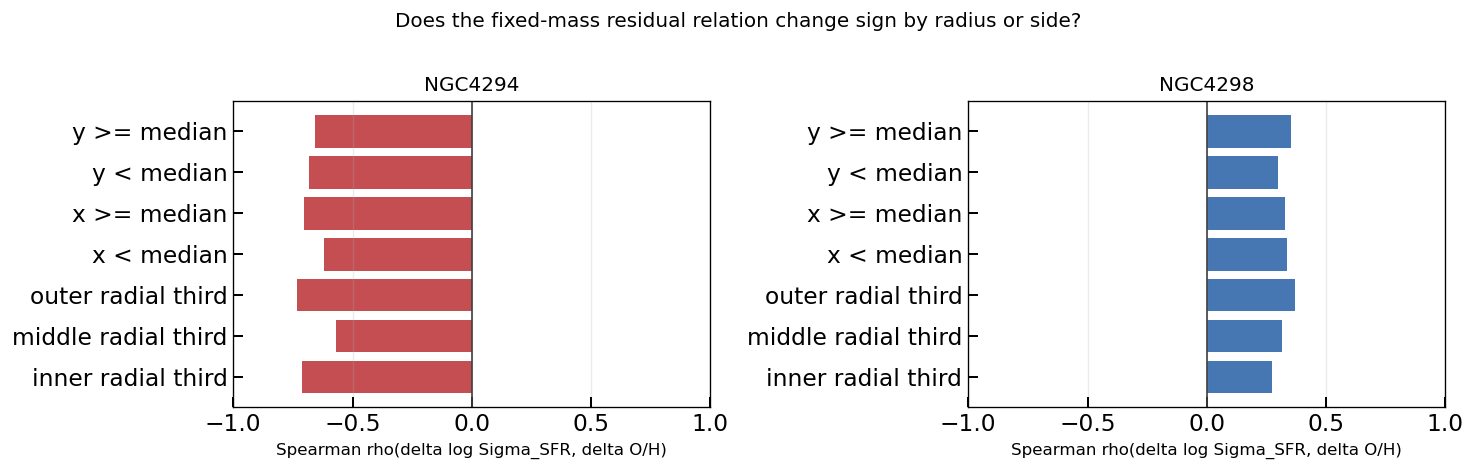

In [16]:
if old_paper_cells_ready(require_ew=True) and 'FOCUS_DIAGNOSTICS' in globals():
    split_rows = []
    for gal, data in FOCUS_DIAGNOSTICS.items():
        valid = data['base_valid']
        d_sfr = data['residuals']['logSFR_HII']
        d_oh = data['residuals']['OH_O3N2_M13']
        radius = data['radius_norm']
        xoff = data['x_offset_pix']
        yoff = data['y_offset_pix']

        radial_ok = valid & np.isfinite(radius)
        if np.sum(radial_ok) >= 60:
            q1, q2 = np.nanquantile(radius[radial_ok], [1/3, 2/3])
            split_masks = {
                'inner radial third': radial_ok & (radius <= q1),
                'middle radial third': radial_ok & (radius > q1) & (radius <= q2),
                'outer radial third': radial_ok & (radius > q2),
                'x < median': valid & np.isfinite(xoff) & (xoff < 0),
                'x >= median': valid & np.isfinite(xoff) & (xoff >= 0),
                'y < median': valid & np.isfinite(yoff) & (yoff < 0),
                'y >= median': valid & np.isfinite(yoff) & (yoff >= 0),
            }
        else:
            split_masks = {}

        for split_name, split_mask in split_masks.items():
            rho, pval, n = diagnostic_spearman(d_sfr[split_mask], d_oh[split_mask], min_n=20)
            split_rows.append({
                'galaxy': gal,
                'split': split_name,
                'n': n,
                'rho_dSFR_dOH': rho,
                'p_value': pval,
                'median_dSFR': np.nanmedian(d_sfr[split_mask]) if n else np.nan,
                'median_dOH': np.nanmedian(d_oh[split_mask]) if n else np.nan,
            })

    SPATIAL_SPLIT_TABLE = pd.DataFrame(split_rows)
    display(SPATIAL_SPLIT_TABLE.style.format({
        'rho_dSFR_dOH': '{:.3f}',
        'p_value': '{:.2g}',
        'median_dSFR': '{:.3f}',
        'median_dOH': '{:.3f}',
    }))

    if len(SPATIAL_SPLIT_TABLE):
        fig, axes = plt.subplots(1, len(FOCUS_DIAGNOSTICS), figsize=(6.2 * len(FOCUS_DIAGNOSTICS), 3.8), squeeze=False)
        for ax, gal in zip(axes[0], FOCUS_DIAGNOSTICS):
            sub = SPATIAL_SPLIT_TABLE[SPATIAL_SPLIT_TABLE['galaxy'] == gal]
            colors = ['#4777b2' if val >= 0 else '#c44e52' for val in sub['rho_dSFR_dOH'].fillna(0)]
            ax.barh(sub['split'], sub['rho_dSFR_dOH'], color=colors)
            ax.axvline(0, color='0.25', lw=1)
            ax.set_xlim(-1, 1)
            ax.set_xlabel('Spearman rho(delta log Sigma_SFR, delta O/H)')
            ax.set_title(gal)
            ax.grid(axis='x', alpha=0.25)
        fig.suptitle('Does the fixed-mass residual relation change sign by radius or side?', y=1.02)
        fig.tight_layout()
        plt.show()
else:
    print('Skipped radial/asymmetry split tests: FOCUS_DIAGNOSTICS is not available.')

### Metallicity-calibration sensitivity

The original contrast is based on O3N2-M13 HII metallicity residuals.  This table repeats the same fixed-mass residual correlation using the required O3N2-M13, O3N2-C20, D16, and PG16 calibrations plus any extra available O/H calibrations.  If NGC4294 stays negative and NGC4298 stays positive across most calibrations, the sign flip is more robust.  If O3N2-C20, D16, PG16, N2-, or S2-based calibrations behave differently from O3N2-M13, inspect the ionization/DIG-sensitive maps above before treating the difference as an abundance-only signal.

,galaxy,calibration,n,rho_dSFR_dOH,p_value,median_dOH,std_dOH
10,NGC4294,O3S2-C20,67102,-0.760,0,0.000,0.058
13,NGC4294,Combined-C20,67102,-0.677,0,0.000,0.050
1,NGC4294,O3N2-C20,67102,-0.670,0,0.000,0.052
0,NGC4294,O3N2-M13,67102,-0.669,0,0.000,0.046
4,NGC4294,O3N2-PP04,67102,-0.669,0,0.000,0.068
11,NGC4294,R3-C20,67102,-0.648,0,0.000,0.058
6,NGC4294,N2-PP04,67102,-0.526,0,0.000,0.040
7,NGC4294,N2-C20,67102,-0.526,0,0.000,0.035
5,NGC4294,N2-M13,67102,-0.526,0,0.000,0.032
12,NGC4294,RS32-C20,67102,-0.511,0,0.000,0.046


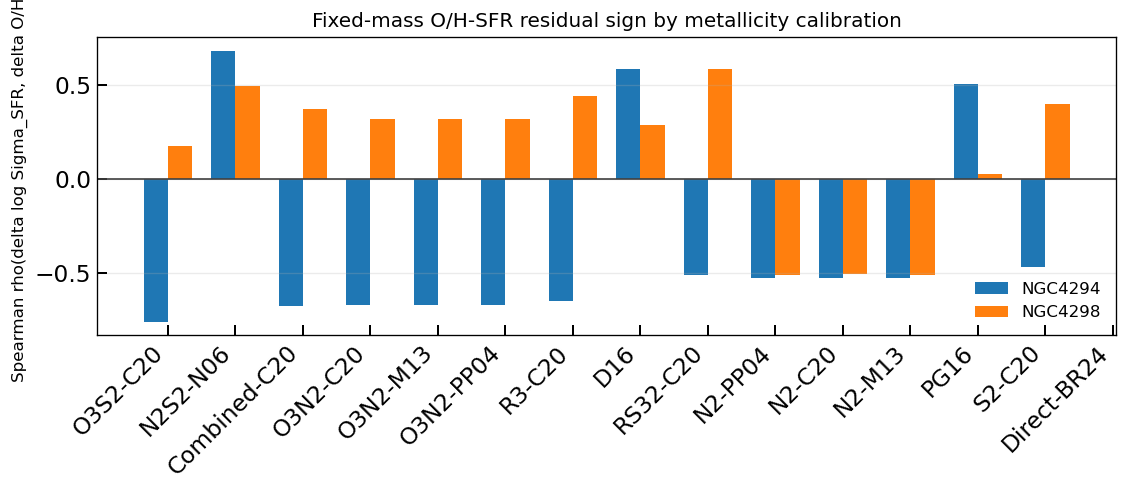

In [17]:
if old_paper_cells_ready(require_ew=True) and 'FOCUS_DIAGNOSTICS' in globals():
    calibration_rows = []
    for gal, data in FOCUS_DIAGNOSTICS.items():
        valid = data['base_valid']
        d_sfr = data['residuals']['logSFR_HII']
        for label in data['oh_maps']:
            d_oh_key = f'OH_{label}'
            if d_oh_key not in data['residuals']:
                continue
            d_oh = data['residuals'][d_oh_key]
            rho, pval, n = diagnostic_spearman(d_sfr[valid], d_oh[valid], min_n=25)
            calibration_rows.append({
                'galaxy': gal,
                'calibration': label,
                'n': n,
                'rho_dSFR_dOH': rho,
                'p_value': pval,
                'median_dOH': np.nanmedian(d_oh[valid & np.isfinite(d_oh)]) if n else np.nan,
                'std_dOH': np.nanstd(d_oh[valid & np.isfinite(d_oh)]) if n else np.nan,
            })

    OH_CALIBRATION_SENSITIVITY = pd.DataFrame(calibration_rows)
    display(OH_CALIBRATION_SENSITIVITY.sort_values(['galaxy', 'rho_dSFR_dOH']).style.format({
        'rho_dSFR_dOH': '{:.3f}',
        'p_value': '{:.2g}',
        'median_dOH': '{:.3f}',
        'std_dOH': '{:.3f}',
    }))

    fig, ax = plt.subplots(figsize=(9.5, 4.2))
    plot_df = OH_CALIBRATION_SENSITIVITY.pivot(index='calibration', columns='galaxy', values='rho_dSFR_dOH')
    plot_df = plot_df.reindex(plot_df.abs().max(axis=1).sort_values(ascending=False).index)
    x = np.arange(len(plot_df.index))
    width = 0.36
    for j, gal in enumerate(FOCUS_DIAGNOSTICS):
        vals = plot_df[gal].to_numpy() if gal in plot_df else np.full(len(x), np.nan)
        ax.bar(x + (j - 0.5) * width, vals, width=width, label=gal)
    ax.axhline(0, color='0.25', lw=1)
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
    ax.set_ylabel('Spearman rho(delta log Sigma_SFR, delta O/H)')
    ax.set_title('Fixed-mass O/H-SFR residual sign by metallicity calibration')
    ax.legend(frameon=False)
    ax.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.show()
else:
    print('Skipped metallicity-calibration sensitivity: FOCUS_DIAGNOSTICS is not available.')

### Map view of the strongest candidate property

The table gives numbers, but the morphology matters.  For each focus galaxy I select the candidate property with the strongest absolute `rho_with_product` and plot it next to ΔSFR, ΔO/H, and the sign product ΔSFR×ΔO/H.  This is a quick visual check for whether the candidate follows the same structures as the opposite-sign Moran-like regions.

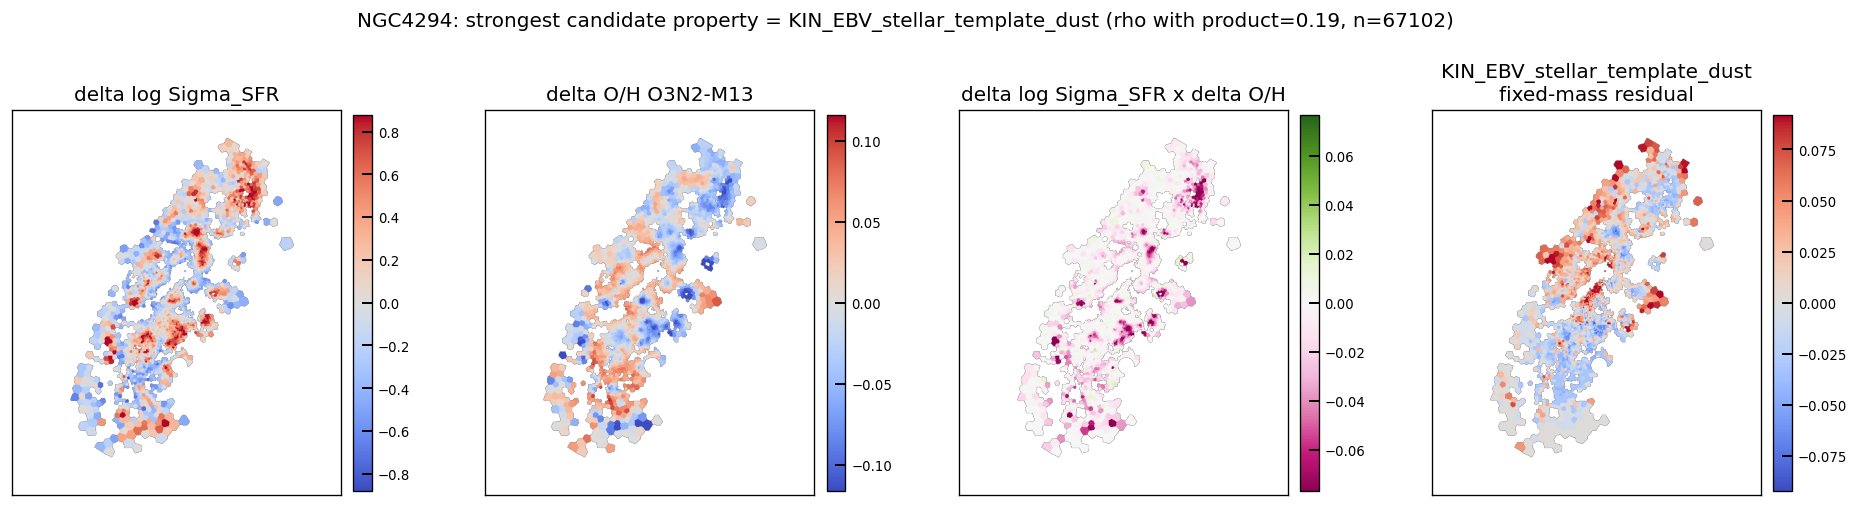

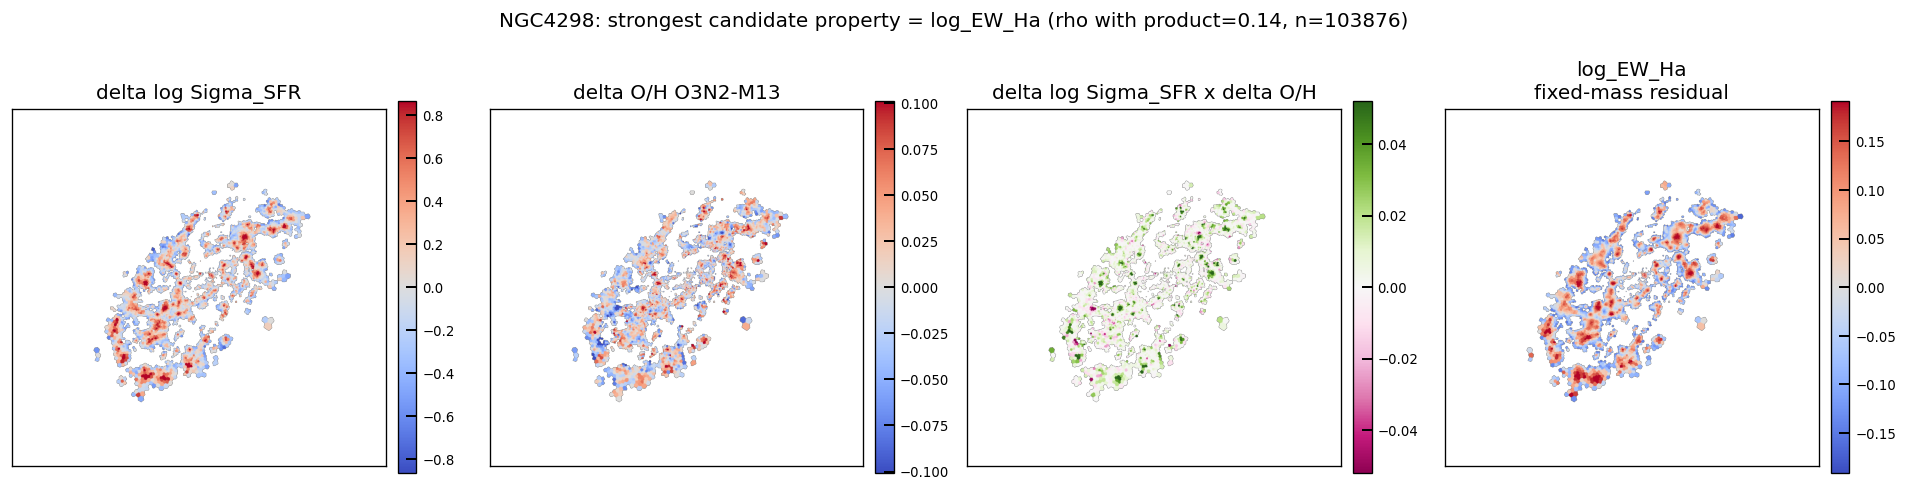

In [18]:
if old_paper_cells_ready(require_ew=True) and 'FOCUS_DIAGNOSTICS' in globals() and 'DIAGNOSTIC_PROPERTY_TABLE' in globals():
    def symmetric_percentile_limit(arr, valid, percentile=98, floor=1e-6):
        vals = np.asarray(arr, dtype=float)[valid & np.isfinite(arr)]
        if vals.size == 0:
            return 1.0
        lim = np.nanpercentile(np.abs(vals), percentile)
        return float(max(lim, floor)) if np.isfinite(lim) else 1.0

    for gal, data in FOCUS_DIAGNOSTICS.items():
        table = DIAGNOSTIC_PROPERTY_TABLE[
            (DIAGNOSTIC_PROPERTY_TABLE['galaxy'] == gal)
            & (DIAGNOSTIC_PROPERTY_TABLE['version'] == 'fixed_mass_residual')
            & np.isfinite(DIAGNOSTIC_PROPERTY_TABLE['rho_with_product'])
        ].copy()
        if table.empty:
            print(f'{gal}: no candidate property had enough finite points for map selection.')
            continue
        best = table.assign(abs_rho=lambda df: df['rho_with_product'].abs()).sort_values('abs_rho', ascending=False).iloc[0]
        best_prop = best['property']
        best_arr = data['residuals'].get(best_prop, data['candidate_maps'][best_prop])
        valid = data['base_valid']
        d_sfr = data['residuals']['logSFR_HII']
        d_oh = data['residuals']['OH_O3N2_M13']
        product = d_sfr * d_oh

        panels = [
            ('delta log Sigma_SFR', d_sfr, 'coolwarm', symmetric_percentile_limit(d_sfr, valid)),
            ('delta O/H O3N2-M13', d_oh, 'coolwarm', symmetric_percentile_limit(d_oh, valid)),
            ('delta log Sigma_SFR x delta O/H', product, 'PiYG', symmetric_percentile_limit(product, valid)),
            (f'{best_prop}\nfixed-mass residual', best_arr, 'viridis' if best_prop in ['radius_norm', 'NII_BPT', 'SII_BPT'] else 'coolwarm', symmetric_percentile_limit(best_arr, valid)),
        ]

        fig, axes = plt.subplots(1, 4, figsize=(16, 4.1), squeeze=False)
        for ax, (title, arr, cmap, lim) in zip(axes[0], panels):
            arr_plot = np.where(valid, arr, np.nan)
            if cmap == 'viridis':
                finite_vals = arr_plot[np.isfinite(arr_plot)]
                vmin = np.nanpercentile(finite_vals, 2) if finite_vals.size else 0
                vmax = np.nanpercentile(finite_vals, 98) if finite_vals.size else 1
                im = ax.imshow(arr_plot, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
            else:
                im = ax.imshow(arr_plot, origin='lower', cmap=cmap, vmin=-lim, vmax=lim)
            ax.set_title(title)
            ax.set_xticks([])
            ax.set_yticks([])
            cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
            cbar.ax.tick_params(labelsize=8)
        fig.suptitle(
            f"{gal}: strongest candidate property = {best_prop} "
            f"(rho with product={best['rho_with_product']:.2f}, n={int(best['n'])})",
            y=1.02,
        )
        fig.tight_layout()
        plt.show()
else:
    print('Skipped strongest-candidate maps: diagnostic tables are not available.')

### How to read these new checks

Use the results in this order:

1. **First check calibration sensitivity.**  A stable NGC4294-negative / NGC4298-positive split across several calibrations is stronger evidence for a real local abundance-SFR difference.  A split that appears only in O3N2 or N2 points to ionization/excitation sensitivity.
2. **Then inspect the top candidate properties.**  Strong EW(Halpha), [S II]/Halpha, [N II]/Halpha, BPT, or Balmer-decrement links would suggest DIG/shock/extinction or line-ratio calibration effects.  Strong SFH/stellar-metallicity/stellar-kinematics links would suggest different underlying stellar-population or dynamical regions.
3. **Finally check the spatial splits.**  If inner and outer bins, or opposite sides of a galaxy, have different signs, treat the global fixed-mass sign as a mixture of substructures rather than one galaxy-wide law.

A useful next manual step, if one of these flags is strong, is to rerun the original cell-15 plot after masking that flagged region or property range.  For example: high [S II]/Halpha only, low EW(Halpha) excluded more aggressively, inner disk only, outer disk only, or the asymmetric side only.